In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, f1_score, precision_score, recall_score, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.metrics import roc_auc_score, balanced_accuracy_score

In [2]:
feature_df = pd.read_csv('feature_data.csv')
operation_df = pd.read_csv('operational_dataset.csv')
feature_df.set_index('Date', inplace=True)
operation_df.set_index('Date', inplace=True)

In [3]:
operation_df['destination'] = operation_df['target']

In [4]:
# Join feature_df and operation_df on Date, source, and destination
merged_df = feature_df.merge(operation_df, on=['Date', 'source', 'destination'], how='inner')

# Display the merged dataframe
merged_df.drop(columns=['target'], axis=1, inplace=True)
feature_df = merged_df

In [5]:
never_disrupted = feature_df[feature_df['Total_disruptions'] == 0]

print("Mean and median of rides planned for never disrupted trajectories:")
print(np.mean(never_disrupted['Total_rides']))
print(np.median(never_disrupted['Total_rides']))
print("Mean and median of rides planned for disrupted trajectories:")
print(np.mean(feature_df[feature_df['Total_disruptions'] > 0]['Total_rides']))
print(np.median(feature_df[feature_df['Total_disruptions'] > 0]['Total_rides']))
print("Percentage of never disrupted trajectories:")
perc = 37637 / 612790 * 100
print(perc)

# Remove never disrupted trajectories
feature_df = feature_df[feature_df['Total_disruptions'] > 0]

Mean and median of rides planned for never disrupted trajectories:
718.5161410314319
54.0
Mean and median of rides planned for disrupted trajectories:
12311.730057915025
4472.0
Percentage of never disrupted trajectories:
6.14190832095824


In [6]:
print(feature_df)

                        source         destination  source_degree  \
Date                                                                
2019-01-01    's-Hertogenbosch          Roosendaal             14   
2019-01-01    's-Hertogenbosch    Utrecht Centraal             14   
2019-01-01   Den Haag Centraal  Eindhoven Centraal             29   
2019-01-01   Den Haag Centraal    Utrecht Centraal             29   
2019-01-01  Eindhoven Centraal   Den Haag Centraal             21   
...                        ...                 ...            ...   
2024-12-31              Zwolle    Lelystad Centrum             23   
2024-12-31              Zwolle            Nijmegen             23   
2024-12-31              Zwolle          Roosendaal             23   
2024-12-31              Zwolle    Utrecht Centraal             23   
2024-12-31              Zwolle             Zutphen             23   

            source_weighted_degree  source_avg_distance  target_degree  \
Date                        

In [244]:
feature_df.to_csv('final_feature_df.csv', index=True)

In [7]:
# Define seasons based on date ranges
def get_season(date):
    if (date.month == 12 and date.day >= 21) or (date.month <= 3 and date.day <= 20):
        return 'Winter'
    elif (date.month == 3 and date.day >= 21) or (date.month <= 6 and date.day <= 20):
        return 'Spring'
    elif (date.month == 6 and date.day >= 21) or (date.month <= 9 and date.day <= 20):
        return 'Summer'
    elif (date.month == 9 and date.day >= 21) or (date.month <= 12 and date.day <= 20):
        return 'Autumn'

feature_df['Date'] = pd.to_datetime(feature_df.index)

feature_df['Season'] = feature_df['Date'].apply(get_season)

C:\Users\brake\AppData\Local\Temp\ipykernel_24828\2645303035.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feature_df['Date'] = pd.to_datetime(feature_df.index)
C:\Users\brake\AppData\Local\Temp\ipykernel_24828\2645303035.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feature_df['Season'] = feature_df['Date'].apply(get_season)


In [8]:
# Split feature_df by season
seasonal_dfs = {season: df for season, df in feature_df.groupby('Season')}

# Example: Access the DataFrame for Winter
winter_df = seasonal_dfs['Winter']
print(winter_df)

                        source         destination  source_degree  \
Date                                                                
2019-01-01    's-Hertogenbosch          Roosendaal             14   
2019-01-01    's-Hertogenbosch    Utrecht Centraal             14   
2019-01-01   Den Haag Centraal  Eindhoven Centraal             29   
2019-01-01   Den Haag Centraal    Utrecht Centraal             29   
2019-01-01  Eindhoven Centraal   Den Haag Centraal             21   
...                        ...                 ...            ...   
2024-12-31              Zwolle    Lelystad Centrum             23   
2024-12-31              Zwolle            Nijmegen             23   
2024-12-31              Zwolle          Roosendaal             23   
2024-12-31              Zwolle    Utrecht Centraal             23   
2024-12-31              Zwolle             Zutphen             23   

            source_weighted_degree  source_avg_distance  target_degree  \
Date                        

In [9]:
seasons = ['Winter', 'Spring', 'Summer', 'Autumn']
seasonal_splits = {}
seasonal_ys = {}
for season in seasons:
    dataset = seasonal_dfs[season]
    seasonal_splits[season] = dataset

print(seasonal_splits['Winter'])

                        source         destination  source_degree  \
Date                                                                
2019-01-01    's-Hertogenbosch          Roosendaal             14   
2019-01-01    's-Hertogenbosch    Utrecht Centraal             14   
2019-01-01   Den Haag Centraal  Eindhoven Centraal             29   
2019-01-01   Den Haag Centraal    Utrecht Centraal             29   
2019-01-01  Eindhoven Centraal   Den Haag Centraal             21   
...                        ...                 ...            ...   
2024-12-31              Zwolle    Lelystad Centrum             23   
2024-12-31              Zwolle            Nijmegen             23   
2024-12-31              Zwolle          Roosendaal             23   
2024-12-31              Zwolle    Utrecht Centraal             23   
2024-12-31              Zwolle             Zutphen             23   

            source_weighted_degree  source_avg_distance  target_degree  \
Date                        

In [10]:
def split_season_by_year(df_season, season_name):
    """
    Split a seasonal DataFrame (e.g., all Winters) into separate DataFrames by year.

    Parameters:
    - df_season: A DataFrame indexed by datetime, containing data for one season over multiple years
    - season_name: The name of the season ('Spring', 'Summer', 'Fall', 'Winter')

    Returns:
    - Dictionary with keys like 'Winter 2019', 'Winter 2020', etc., and values as DataFrames
    """
    df_season = df_season.sort_index()
    df_season.index = pd.to_datetime(df_season.index)

    seasonal_splits = {}

    years = sorted(set(df_season.index.year))

    for year in years:
        if season_name == 'Winter':
            # Winter spans two years: Dec 21 (year) to Mar 20 (year + 1)
            start = pd.Timestamp(f'{year}-12-21')
            end = pd.Timestamp(f'{year + 1}-03-20')
            label = f'Winter {year}'
        elif season_name == 'Spring':
            start = pd.Timestamp(f'{year}-03-21')
            end = pd.Timestamp(f'{year}-06-20')
            label = f'Spring {year}'
        elif season_name == 'Summer':
            start = pd.Timestamp(f'{year}-06-21')
            end = pd.Timestamp(f'{year}-09-20')
            label = f'Summer {year}'
        elif season_name == 'Autumn':
            start = pd.Timestamp(f'{year}-09-21')
            end = pd.Timestamp(f'{year}-12-20')
            label = f'Autumn {year}'
        else:
            raise ValueError(f"Unknown season: {season_name}")

        mask = (df_season.index >= start) & (df_season.index <= end)
        split_df = df_season.loc[mask]

        if not split_df.empty:
            seasonal_splits[label] = split_df

    return seasonal_splits

In [11]:
winter_data = split_season_by_year(seasonal_splits['Winter'], 'Winter')
spring_data = split_season_by_year(seasonal_splits['Spring'], 'Spring')
# Access a specific season:
winter_2023 = winter_data['Winter 2023']
print(winter_2023)

# Loop through all:
for season, data in winter_data.items():
    print(season, data.shape)

for season, data in spring_data.items():
    print(season, data.shape)

                      source         destination  source_degree  \
Date                                                              
2023-12-21  's-Hertogenbosch     Arnhem Centraal             16   
2023-12-21  's-Hertogenbosch   Den Haag Centraal             16   
2023-12-21  's-Hertogenbosch              Deurne             16   
2023-12-21  's-Hertogenbosch           Dordrecht             16   
2023-12-21  's-Hertogenbosch  Eindhoven Centraal             16   
...                      ...                 ...            ...   
2024-03-20            Zwolle    Lelystad Centrum             19   
2024-03-20            Zwolle            Nijmegen             19   
2024-03-20            Zwolle          Roosendaal             19   
2024-03-20            Zwolle  Rotterdam Centraal             19   
2024-03-20            Zwolle    Utrecht Centraal             19   

            source_weighted_degree  source_avg_distance  target_degree  \
Date                                                  

In [12]:
topo_features = [ 
    'source_degree', 'source_weighted_degree', 'source_avg_distance', 
    'target_degree', 'target_weighted_degree', 'target_avg_distance', 
    'common_neighbors', 'jaccard_coefficient', 'preferential_attachment', 
    'adamic_adar_index', 'resource_allocation_index','weight', 'distance']
wthr_features = ['FHVEC', 'TG', 'TN', 'TX', 'T10N', 'SQ', 'RH', 'RHX', 'VVX']
oper_features = ['Days_since_last_disruption','Num_prev_disruptions', 'Ratio', 
                # 'Total_disruptions', 'Total_rides' (leads to unrealistic results)
                #, 'Previous_causes_vec', 'Most_recent_causes_vec' (still need to solve vector inputs)
                ]   
X_topo = np.array(feature_df[topo_features])
X_wthr = np.array(feature_df[wthr_features])
X_oper = np.array(feature_df[oper_features])
X_tnw = np.array(feature_df[topo_features + wthr_features])
X_wno = np.array(feature_df[wthr_features + oper_features])
X_tno = np.array(feature_df[topo_features + oper_features])
X_comp = np.array(feature_df.drop(columns=['source', 'destination', 'Disrupted', 'Previous_causes_vec', 'Most_recent_causes_vec', 'Total_disruptions', 'Total_rides']))
y = np.array(feature_df['Disrupted'])

In [13]:
feature_df[feature_df['Disrupted']]

,source,destination,source_degree,source_weighted_degree,source_avg_distance,target_degree,target_weighted_degree,target_avg_distance,common_neighbors,jaccard_coefficient,...,Disrupted,Days_since_last_disruption,Num_prev_disruptions,Ratio,Total_disruptions,Total_rides,Previous_causes_vec,Most_recent_causes_vec,Date,Season
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-01,'s-Hertogenbosch,Roosendaal,14,83,31.714286,13,52,39.230769,2,0.142857,...,True,0,0,0.000000,1,2,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,2019-01-01,Winter
2019-01-01,'s-Hertogenbosch,Utrecht Centraal,14,83,31.714286,36,243,21.305556,2,0.071429,...,True,0,0,0.000000,2,1,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. ...,2019-01-01,Winter
2019-01-01,Den Haag Centraal,Eindhoven Centraal,29,253,52.793103,21,116,40.142857,3,0.111111,...,True,0,0,0.000000,1,32,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,2019-01-01,Winter
2019-01-01,Den Haag Centraal,Utrecht Centraal,29,253,52.793103,36,243,21.305556,10,0.333333,...,True,0,0,0.000000,1,21,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,2019-01-01,Winter
2019-01-01,Eindhoven Centraal,Den Haag Centraal,21,116,40.142857,29,253,52.793103,3,0.111111,...,True,0,0,0.000000,1,32,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,2019-01-01,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,Lelystad Centrum,Rotterdam Centraal,15,78,59.133333,27,139,35.407407,2,0.083333,...,True,5,25,2.682403,26,932,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,2024-12-31,Winter
2024-12-31,Rotterdam Centraal,Lelystad Centrum,27,139,35.407407,15,78,59.133333,2,0.083333,...,True,5,107,5.171580,108,2069,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,2024-12-31,Winter
2024-12-31,Rotterdam Centraal,Utrecht Centraal,27,139,35.407407,40,226,15.375000,5,0.131579,...,True,1,897,1.519644,898,59027,[1. 0. 0. 1. 1. 1. 1. 0. 1. 1. 1. 0. 0. 1. 0. ...,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,2024-12-31,Winter


In [20]:
from sklearn.model_selection import TimeSeriesSplit

tss = TimeSeriesSplit(n_splits = 12)

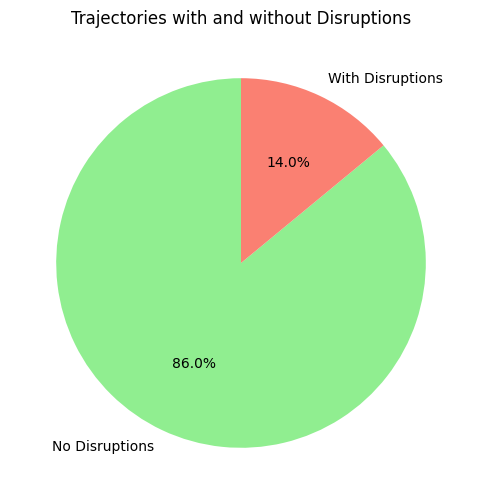

In [14]:
disrupted = (feature_df["Disrupted"] == True).sum()
non_disrupted =  (feature_df["Disrupted"] == False).sum()

# Data for the pie chart
labels = ['No Disruptions', 'With Disruptions']
sizes = [non_disrupted, disrupted]
colors = ['lightgreen', 'salmon']

# Plot the pie chart
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Trajectories with and without Disruptions')
plt.show()

In [15]:
param_grid_lr = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2', 'elasticnet'],
        'solver': ['liblinear', 'saga', 'newton-cg'],
    }

param_grid_rf = {
        'n_estimators': [100, 200, 500, 1000],
        'max_features': ['auto', 'sqrt', 'log2'],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'bootstrap': [True, False]
    }

param_grid_gbdt = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'min_samples_split': [2, 5, 10]
}

param_grid_xgb = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],      
    'n_estimators': [100, 200, 300],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [1, sum(y == 0) / sum(y == 1)]
}

# Define scoring metrics
scoring = {
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

logres = LogisticRegression(random_state=42, class_weight='balanced')
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
xgb = XGBClassifier(random_state=42)
gbdt = GradientBoostingClassifier(random_state=42)

In [16]:
from xgboost import plot_importance
import shap

def plot_feature_importance(model, feature_names, max_num_features=20, model_type=None, season='Winter'):
    """
    Plot feature importance for different model types.
    """
    if model_type == 'xgboost':
        plot_importance(model, max_num_features=max_num_features)
        plt.title("XGBoost Feature Importance")
        return
    elif model_type == 'logistic':
        importance = np.abs(model.coef_[0])
        importance_label = "Absolute Coefficient"
    elif model_type in ['random_forest', 'gradient_boosting']:
        importance = model.feature_importances_
        importance_label = "Feature Importance (Gini/Impurity Reduction)"
    else:
        raise ValueError("Unsupported model type. Use 'xgboost', 'logistic', 'random_forest', or 'gradient_boosting'.")

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    })
    importance_df = importance_df.sort_values(by='Importance', ascending=False).head(max_num_features)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.xlabel(importance_label)
    plt.ylabel("Feature")
    plt.title(f"{model_type.replace('_', ' ').title()} Feature Importance ({season})")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


def optimise(model, scoring, param_grid, seasonal_data, season):
    """
    Optimize a model using RandomizedSearchCV with time-series cross-validation,
    using seasonal splits for training/testing.

    Parameters:
    - model: Model to optimize
    - scoring: Scoring metric(s)
    - param_grid: Hyperparameter grid
    - seasonal_data: Full seasonal DataFrame (e.g., all Winters)
    - season: Season name (e.g., 'Winter')
    """
    # Split the seasonal data by year
    seasonal_splits = split_season_by_year(seasonal_data, season)
    years_sorted = sorted(seasonal_splits.keys())  # e.g., ['Winter 2019', ..., 'Winter 2023']
    
    # Use all but the last year for training, and the last year for testing
    train_years = years_sorted[:-1]
    test_year = years_sorted[-1]
    
    train_df = pd.concat([seasonal_splits[year] for year in train_years])
    test_df = seasonal_splits[test_year]
    
    # Separate features and target
    feature_cols = topo_features + wthr_features + oper_features
    X_train = train_df[feature_cols]
    y_train = train_df['Disrupted'].astype(int)
    X_test = test_df[feature_cols]
    y_test = test_df['Disrupted'].astype(int)

    # Time-series cross-validation
    tscv = TimeSeriesSplit(n_splits=5)
    
    # Randomized search with time-series CV
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=10,
        scoring=scoring,
        refit='f1',
        cv=tscv,
        verbose=1,
        n_jobs=-1,
        random_state=42
    )
    
    # Fit the model
    random_search.fit(X_train, y_train)
    
    # Results
    print("Best Parameters:", random_search.best_params_)
    print("Best F1 Score:", random_search.best_score_)
    
    # Evaluate best model
    best_model = random_search.best_estimator_
    y_pred = best_model.predict(X_test)
    print("Test Set Classification Report:")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")
    print(f"AUC: {roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1]):.4f}")
    
    # Determine model type for SHAP/importance
    if isinstance(best_model, XGBClassifier):
        model_type = 'xgboost'
    elif isinstance(best_model, LogisticRegression):
        model_type = 'logistic'
    elif isinstance(best_model, RandomForestClassifier):
        model_type = 'random_forest'
    elif isinstance(best_model, GradientBoostingClassifier):
        model_type = 'gradient_boosting'
    
    # Feature importance + SHAP
    plot_feature_importance(best_model, feature_cols, max_num_features=20, model_type=model_type, season=season)
    
    return best_model, random_search.best_params_

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
def plot_shap_values(model, X_test, feature_names, model_type=None, threshold=0.5, season='Winter'):
    import shap
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    if model_type not in ['logistic', 'random_forest', 'gradient_boosting', 'xgboost']:
        print(f"SHAP plotting is only supported for tree-based models or logistic regression, not '{model_type}'.")
        return []
    
    if not isinstance(X_test, pd.DataFrame):
        X_test = pd.DataFrame(X_test, columns=feature_names)
    
    X_test_sampled = X_test.sample(n=min(1000, len(X_test)), random_state=42)

    # SHAP Explainer
    if model_type == 'logistic':
        explainer = shap.KernelExplainer(model.predict_proba, X_test_sampled)
        shap_values = explainer.shap_values(X_test_sampled)
    else:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test_sampled)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]  # Use positive class for binary

        # SHAP value preparation
    if isinstance(shap_values, list):
        # Usually list of 2 arrays for binary classification
        shap_values = shap_values[1]  # Use class 1
    else:
        # SHAP values is array; may still have shape (n_samples, n_features, n_classes)
        if shap_values.ndim == 3 and shap_values.shape[2] == 2:
            # Assume class 1 for binary
            shap_values = shap_values[:, :, 1]

    # Compute mean SHAP
    mean_shap_values = np.abs(shap_values).mean(axis=0)

    # If values are duplicated per feature (e.g., shape (n_features, 2)), take one column
    if mean_shap_values.ndim == 2 and mean_shap_values.shape[1] == 2:
        if np.allclose(mean_shap_values[:, 0], mean_shap_values[:, 1]):
            mean_shap_values = mean_shap_values[:, 0]
        else:
            raise ValueError("Ambiguous mean SHAP values — columns differ.")

    # Ensure final shape is correct
    if mean_shap_values.ndim != 1:
        raise ValueError(f"Expected 1D mean SHAP values, got shape {mean_shap_values.shape}")

    # Mean SHAP value computation
    mean_shap_values = np.abs(shap_values).mean(axis=0)

    print(mean_shap_values)
    
    # Fix shape if it's 2D (e.g., shape: (1, n_features))
    if mean_shap_values.ndim > 1:
        mean_shap_values = mean_shap_values.squeeze()

    shap_df = pd.DataFrame({
        'feature': feature_names,
        'mean_shap': mean_shap_values
    })

    high_impact_features = shap_df.nlargest(10, 'mean_shap')['feature'].tolist()

    # SHAP Summary Plot
    plt.figure()
    shap.summary_plot(shap_values, X_test_sampled, feature_names=feature_names, max_display=20, show=False)
    plt.title(f"SHAP Summary Plot for {model_type.replace('_', ' ').title()} ({season})")
    plt.tight_layout()
    plt.show()

    # Bar plot of mean SHAP values
    plt.figure(figsize=(10, 6))
    shap_df_sorted = shap_df.sort_values('mean_shap', ascending=False)
    plt.bar(shap_df_sorted['feature'], shap_df_sorted['mean_shap'])
    plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold = {threshold}')
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Features')
    plt.ylabel('Mean Absolute SHAP Value')
    plt.title(f"Mean Absolute SHAP Values for {model_type.replace('_', ' ').title()} ({season})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return shap_values

In [18]:
# Assume X_val, y_val are validation data and target
# model is a trained machine learning model (e.g., LSTM)
def shap_select_features(model, X_val, y_val, threshold=0.05):
    # Calculate SHAP values
    explainer = shap.KernelExplainer(model.predict, X_val)
    shap_values = explainer.shap_values(X_val)
    
    # Convert SHAP values to DataFrame
    shap_df = pd.DataFrame(shap_values, columns=X_val.columns)
    
    # Perform logistic regression on SHAP values
    lr = LogisticRegression()
    lr.fit(shap_df, y_val)
    
    # Select features with significant coefficients (p-value < threshold)
    p_values = np.abs(lr.coef_[0]) / np.std(shap_df, axis=0)
    selected_features = X_val.columns[p_values < threshold].tolist()
    
    return selected_features

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'subsample': 0.6, 'scale_pos_weight': 6.1335921414928185, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best F1 Score: 0.4038788377712801
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.75      0.85      2651
           1       0.19      0.72      0.30       210

    accuracy                           0.75      2861
   macro avg       0.58      0.74      0.57      2861
weighted avg       0.91      0.75      0.81      2861

Accuracy: 0.7522
F1 Score: 0.2987
Precision: 0.1885
Recall: 0.7190
Balanced Accuracy: 0.7369
AUC: 0.8189
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'subsample': 0.6, 'scale_pos_weight': 6.1335921414928185, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best F1 Score: 0.4520940741527334
Test Set Classification Re

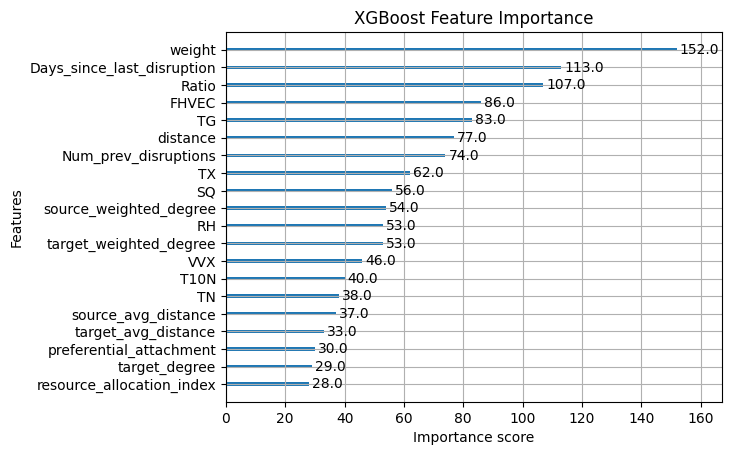

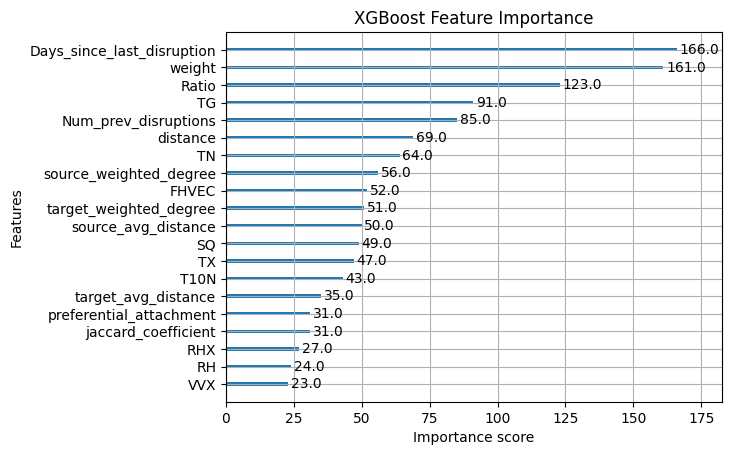

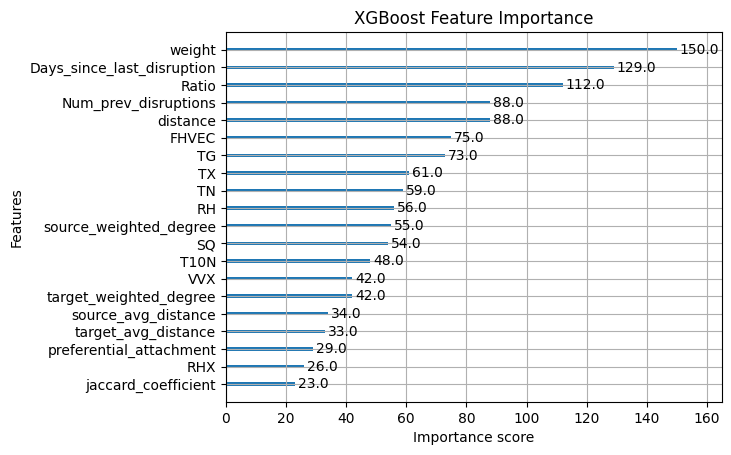

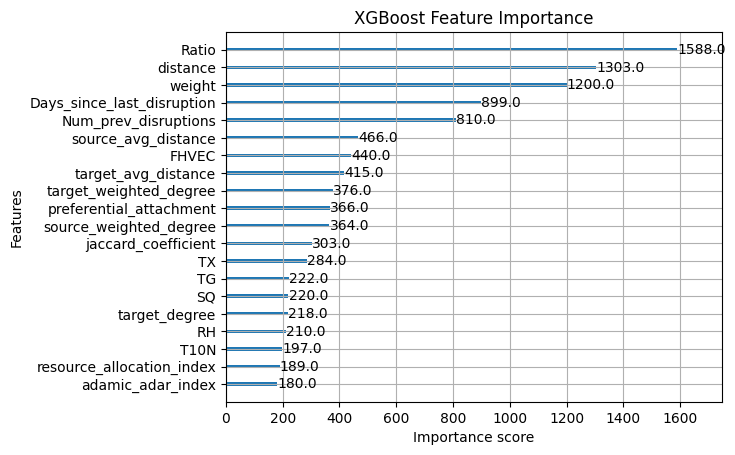

In [21]:
xgb_models = {}
xgb_params = {}
xgb_features = {}

for season in seasons:
    X = seasonal_splits[season]
    xgb_models[season], xgb_params[season] = optimise(xgb, scoring, param_grid_xgb, X, season)

[0.02483656 0.05659703 0.01661122 0.0333678  0.07623143 0.02018718
 0.00431977 0.04153904 0.01525864 0.01759055 0.05444383 0.97908664
 0.11064506 0.13026941 0.07001404 0.01411643 0.07223891 0.0214465
 0.02230305 0.01807835 0.06152298 0.07041527 0.35866493 0.13357826
 0.26985535]


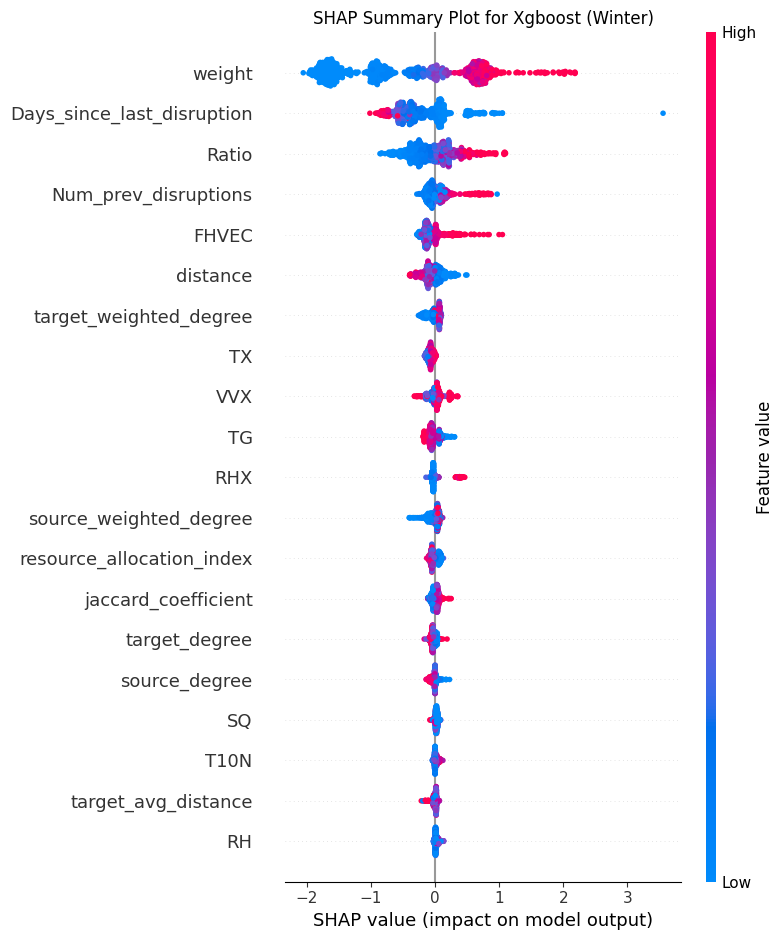

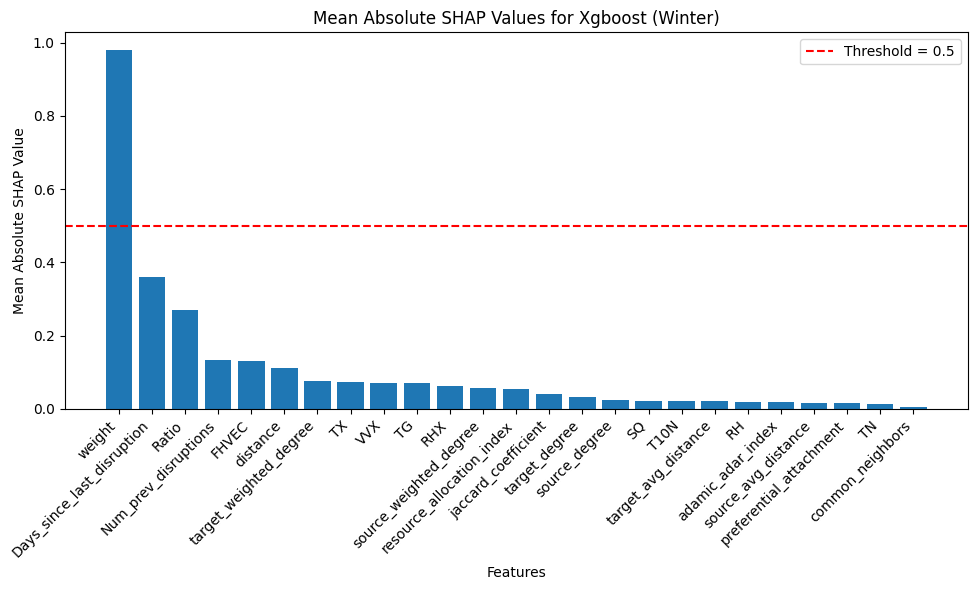

[0.03307438 0.10503477 0.03525381 0.02510714 0.08002519 0.02234934
 0.00465799 0.02019122 0.02847285 0.00793812 0.01403283 0.83264166
 0.07370665 0.05496177 0.06188986 0.05095399 0.08582956 0.03732949
 0.06487403 0.03997912 0.01854364 0.017094   0.7243775  0.08931382
 0.29412255]


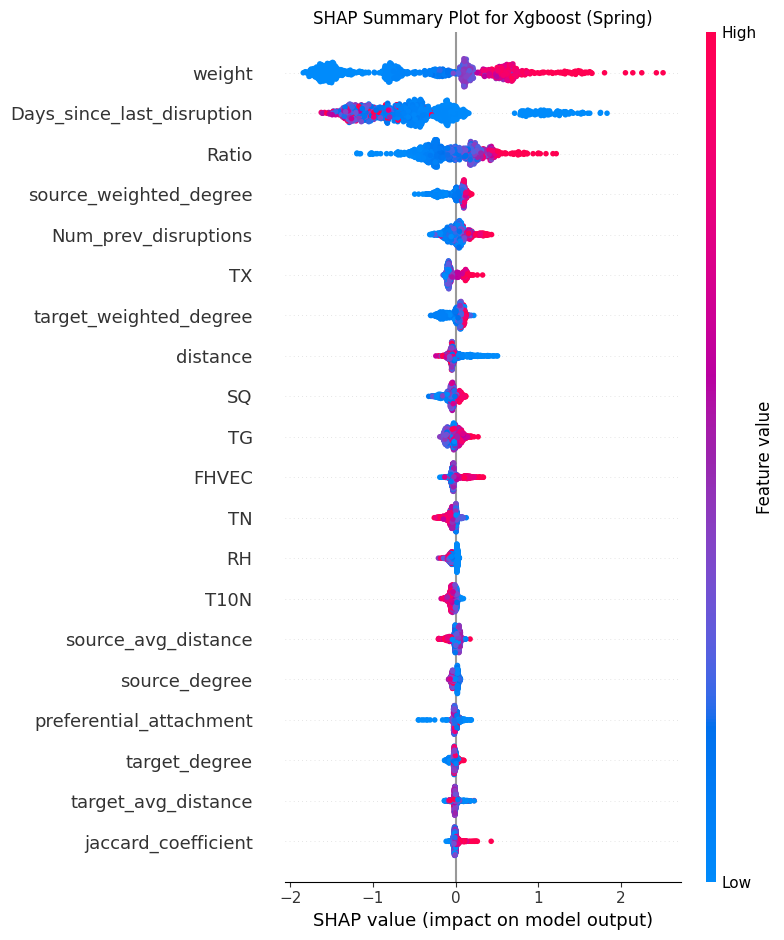

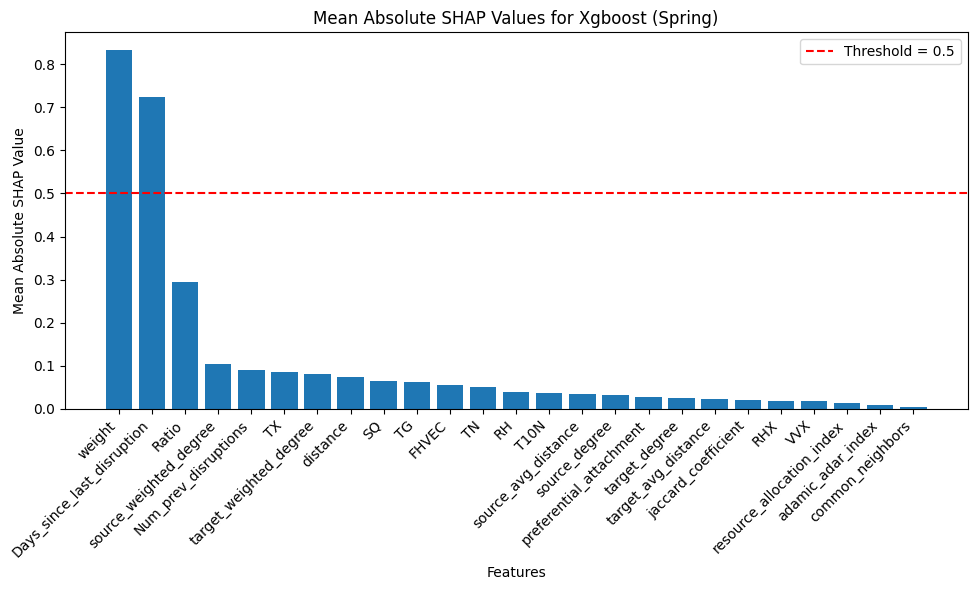

[0.01940768 0.05381813 0.02179875 0.00529141 0.06447663 0.02516597
 0.00181149 0.00987803 0.02881825 0.01256882 0.02314423 0.9702293
 0.11221341 0.0535499  0.06350136 0.03962556 0.07273374 0.02247368
 0.06500872 0.04065739 0.02864398 0.07701223 0.403153   0.20047273
 0.21050787]


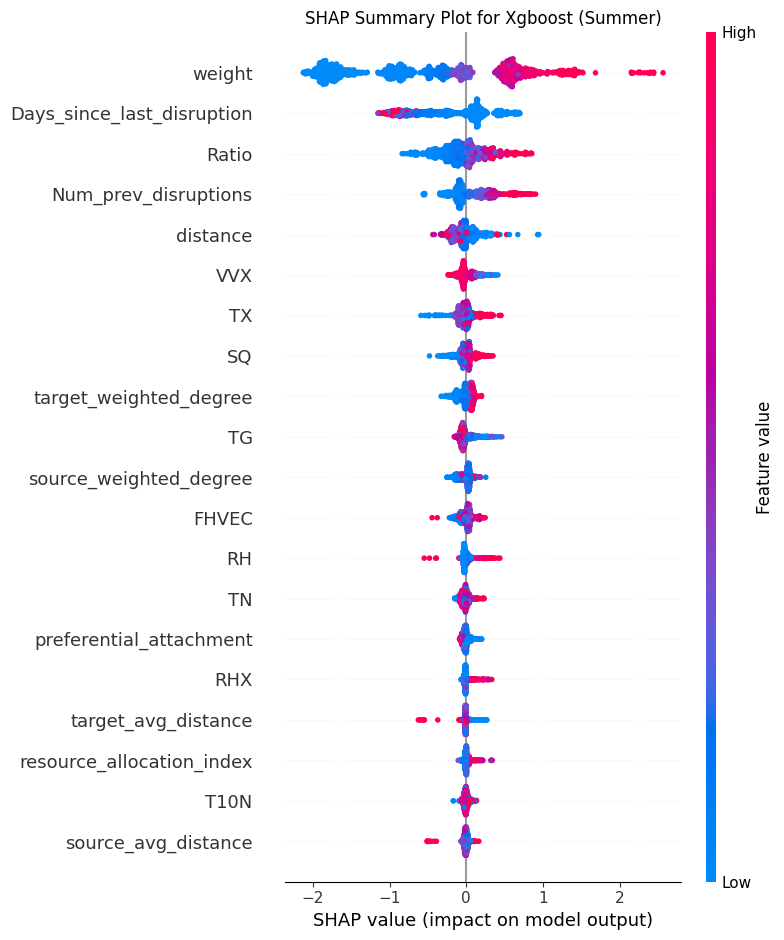

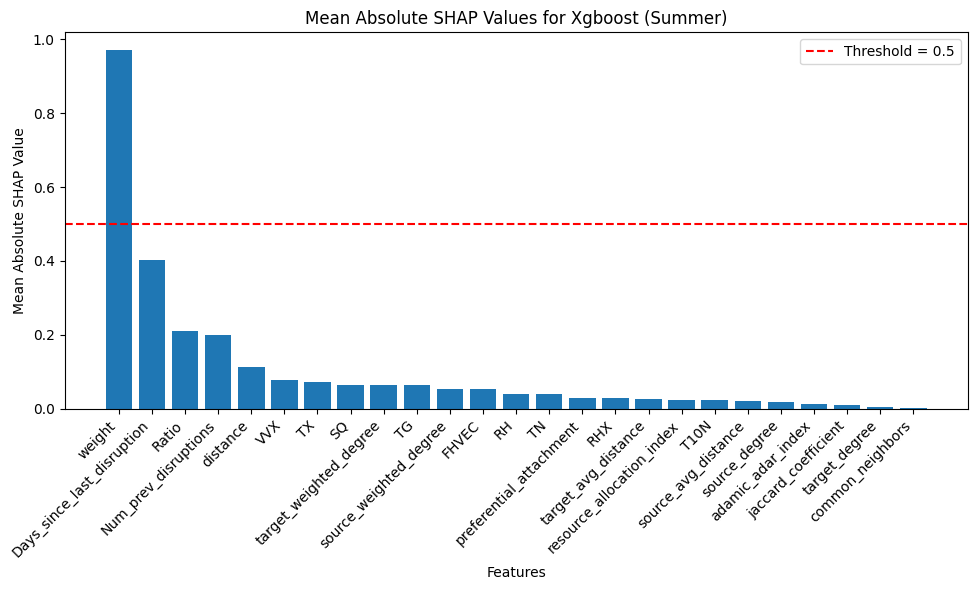

[1.8788744e-03 1.1362274e-02 6.9750468e-03 4.3897089e-03 7.6434645e-03
 5.8396519e-03 5.2693777e-04 4.2452025e-03 1.1183244e-02 2.9758327e-03
 2.0754181e-03 5.8850610e-01 5.5856444e-02 3.6243368e-03 1.8544419e-03
 1.2466547e-03 2.2248314e-03 1.7896043e-03 1.2639902e-03 1.4037734e-03
 1.2143013e-03 4.0570982e-03 1.6013022e-01 5.8798596e-02 1.4307044e-01]


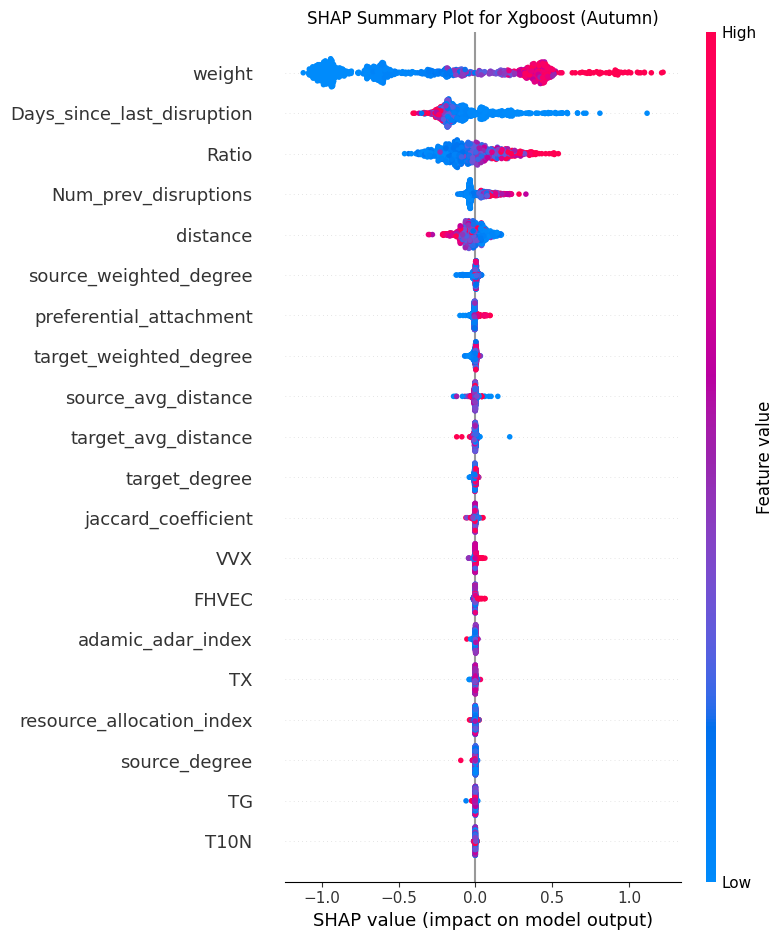

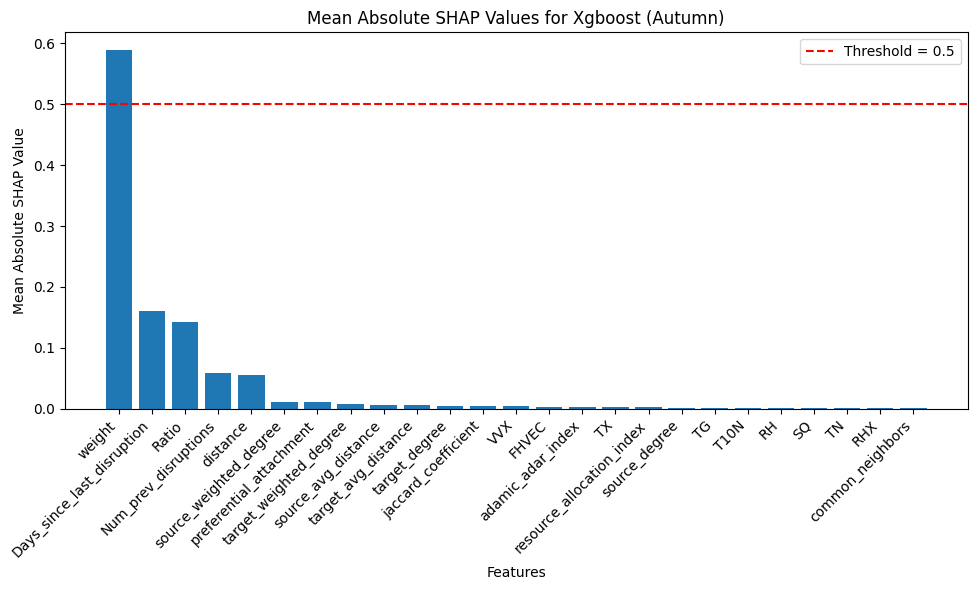

In [22]:
for season in seasons:
    X = seasonal_splits[season]
    test_data = split_season_by_year(X, season)
    test_data = test_data[f'{season} 2024']
    feature_cols = topo_features + wthr_features + oper_features
    shap_values = plot_shap_values(xgb_models[season], test_data[feature_cols], feature_cols, model_type='xgboost', season=season)

In [23]:
from shap_select import shap_select	
feature_selection_xgb = {}
for season in seasons:
    X = seasonal_splits[season]
    test_data = split_season_by_year(X, season)
    test_data = test_data[f'{season} 2024']
    feature_cols = topo_features + wthr_features + oper_features
    selected_features_df = shap_select(xgb_models[season], test_data[feature_cols], test_data['Disrupted'], task="binary", threshold=0.05)
    print(f"Selected features for {season}:")
    print(selected_features_df)
    selected_features_df = selected_features_df[selected_features_df['selected'] == 1]
    sel_feat_list = selected_features_df['feature name'].tolist()
    feature_selection_xgb[season] = sel_feat_list
    print(sel_feat_list)

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 26 out of 26 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 25 out of 25 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarn

Selected features for Winter:
                  feature name    t-value  stat.significance  coefficient  \
0                       weight  13.059813       5.586478e-39     1.138749   
1                        Ratio   8.212414       2.167851e-16     1.894303   
2   Days_since_last_disruption   5.729708       1.006038e-08     1.184976   
3          target_avg_distance   2.176443       2.952216e-02     7.204332   
4                source_degree   1.949638       5.121930e-02     4.203058   
5          source_avg_distance   1.838731       6.595478e-02     6.697564   
6         Num_prev_disruptions   1.789193       7.358377e-02     0.530576   
7                     distance   1.687570       9.149384e-02     1.564018   
8                target_degree   1.237718       2.158208e-01     2.921574   
9                          RHX   0.875047       3.815482e-01     0.588524   
10   resource_allocation_index   0.617145       5.371389e-01     0.906526   
11                          SQ   0.183643     

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 26 out of 26 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 25 out of 25 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarn

Selected features for Spring:
                  feature name    t-value  stat.significance  coefficient  \
0                       weight  33.593118      2.114314e-247     1.013004   
1                        Ratio  25.564874      3.752178e-144     1.917712   
2   Days_since_last_disruption  19.968429       1.036632e-88     0.694712   
3         Num_prev_disruptions  14.503526       1.150824e-47     2.972597   
4                           SQ   6.314760       2.705816e-10     2.305646   
5          source_avg_distance   2.632539       8.474939e-03     1.663466   
6       source_weighted_degree   2.073790       3.809877e-02     0.449315   
7                target_degree   2.045666       4.078928e-02     1.837721   
8                           RH   1.787219       7.390213e-02     1.143251   
9             common_neighbors   1.460232       1.442263e-01     4.798171   
10           adamic_adar_index   1.212651       2.252635e-01     2.884712   
11                          TG   1.147932     

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 26 out of 26 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 25 out of 25 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarn

Selected features for Summer:
                  feature name    t-value  stat.significance  coefficient  \
0         Num_prev_disruptions  38.964570       0.000000e+00     3.366018   
1                       weight  24.524899      8.015288e-133     0.664706   
2                        Ratio  17.588471       3.019168e-69     1.727932   
3   Days_since_last_disruption  14.520899       8.933112e-48     1.019154   
4                           TG   6.466574       1.002496e-10     1.952531   
5                           RH   3.472558       5.155242e-04     1.078794   
6                          VVX   2.814455       4.885998e-03     0.791216   
7                           SQ   2.805661       5.021352e-03     0.837769   
8                source_degree   2.354622       1.854158e-02     2.617711   
9                         T10N   2.324363       2.010605e-02     2.119134   
10           adamic_adar_index   1.805614       7.097865e-02     2.977293   
11      source_weighted_degree   1.507175     

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 26 out of 26 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 25 out of 25 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarn

Selected features for Autumn:
                  feature name    t-value  stat.significance  coefficient  \
0                       weight  36.653826      3.976872e-294     1.682251   
1                        Ratio  26.248116      7.510611e-152     3.622606   
2   Days_since_last_disruption  17.864059       2.246908e-71     2.311859   
3         Num_prev_disruptions   8.698090       3.375165e-18     3.119507   
4      preferential_attachment   6.782729       1.179265e-11     7.925896   
5                     distance   3.711099       2.063617e-04     1.736565   
6            adamic_adar_index   3.629711       2.837389e-04    21.473591   
7                           TG   1.081113       2.796469e-01     9.195925   
8                target_degree   0.903063       3.664926e-01     4.324398   
9                           SQ   0.762263       4.459028e-01     5.343243   
10      source_weighted_degree   0.654603       5.127231e-01     0.852468   
11         source_avg_distance   0.229341     

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 2 out of 2 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)


In [24]:
xgb_models_selected = {}

for season in seasons:
    # Get the seasonal data
    X = seasonal_splits[season]
    test_data = split_season_by_year(X, season)
    train_data = pd.concat([test_data[year] for year in test_data if year != f'{season} 2024'])
    test_data = test_data[f'{season} 2024']
    
    # Extract selected features
    selected_features = feature_selection_xgb[season]
    
    # Prepare training and testing data
    X_train = train_data[selected_features]
    y_train = train_data['Disrupted'].astype(int)
    X_test = test_data[selected_features]
    y_test = test_data['Disrupted'].astype(int)
    
    # Train the XGBoost model
    model = XGBClassifier(random_state=42, **xgb_params[season])
    model.fit(X_train, y_train)
    
    # Store the trained model
    xgb_models_selected[season] = model
    
    # Evaluate the model
    y_pred = model.predict(X_test)
    print(f"Season: {season}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")
    print(f"AUC: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.4f}")

Season: Winter
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.74      0.84      2651
           1       0.19      0.76      0.30       210

    accuracy                           0.74      2861
   macro avg       0.58      0.75      0.57      2861
weighted avg       0.92      0.74      0.80      2861

Accuracy: 0.7427
F1 Score: 0.3030
Precision: 0.1891
Recall: 0.7619
Balanced Accuracy: 0.7516
AUC: 0.8254
Season: Spring
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.73      0.83     17463
           1       0.24      0.75      0.36      1984

    accuracy                           0.73     19447
   macro avg       0.60      0.74      0.60     19447
weighted avg       0.89      0.73      0.78     19447

Accuracy: 0.7318
F1 Score: 0.3622
Precision: 0.2391
Recall: 0.7465
Balanced Accuracy: 0.7383
AUC: 0.8164
Season: Summer
Classification Report:
              precisio

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py:542: FitFailedWarning: 
5 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 1344, in wrapper
    estimator._validate_params()
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraint

Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': False}
Best F1 Score: 0.4032473072180551
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.76      0.85      2651
           1       0.18      0.67      0.28       210

    accuracy                           0.75      2861
   macro avg       0.57      0.71      0.57      2861
weighted avg       0.91      0.75      0.81      2861

Accuracy: 0.7504
F1 Score: 0.2817
Precision: 0.1786
Recall: 0.6667
Balanced Accuracy: 0.7119
AUC: 0.8165


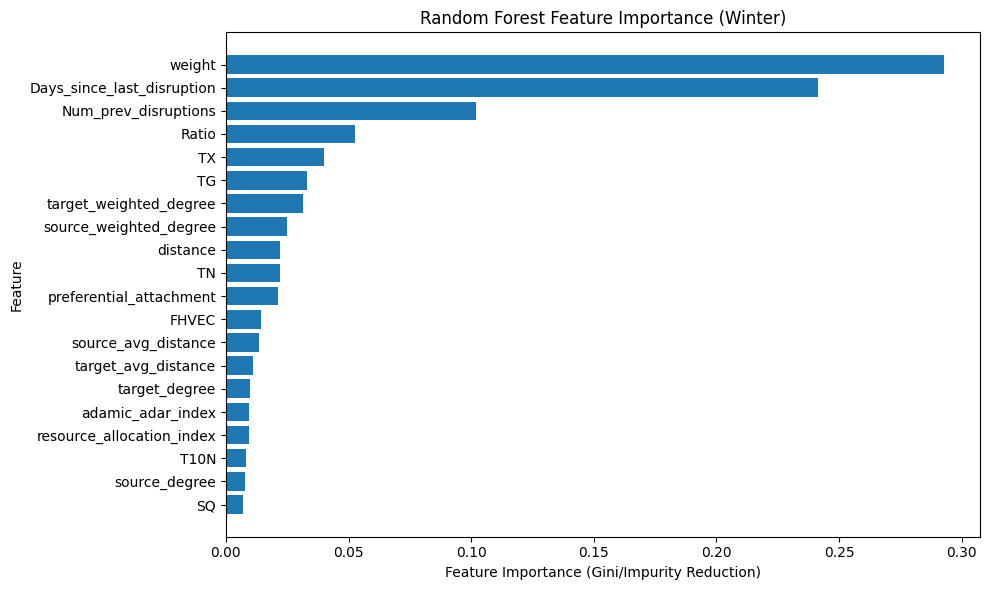

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py:542: FitFailedWarning: 
5 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 1344, in wrapper
    estimator._validate_params()
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraint

Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': False}
Best F1 Score: 0.456456506057101
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.79      0.86     17463
           1       0.26      0.67      0.38      1984

    accuracy                           0.78     19447
   macro avg       0.61      0.73      0.62     19447
weighted avg       0.88      0.78      0.81     19447

Accuracy: 0.7763
F1 Score: 0.3798
Precision: 0.2648
Recall: 0.6714
Balanced Accuracy: 0.7298
AUC: 0.8194


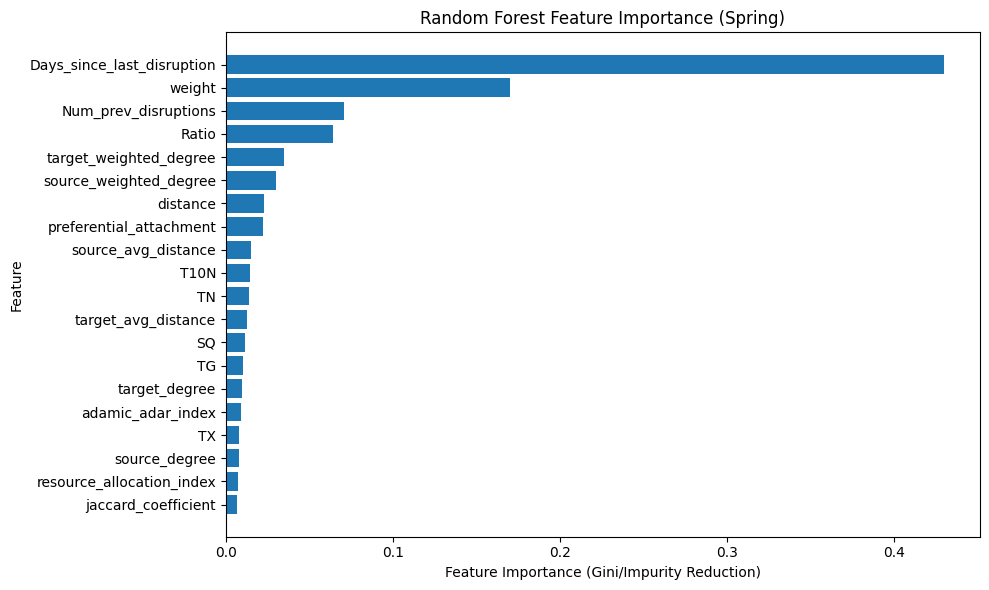

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py:542: FitFailedWarning: 
5 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 1344, in wrapper
    estimator._validate_params()
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraint

Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': False}
Best F1 Score: 0.428537308460314
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.71      0.82     16903
           1       0.25      0.75      0.38      2188

    accuracy                           0.72     19091
   macro avg       0.60      0.73      0.60     19091
weighted avg       0.88      0.72      0.77     19091

Accuracy: 0.7159
F1 Score: 0.3758
Precision: 0.2512
Recall: 0.7463
Balanced Accuracy: 0.7291
AUC: 0.7985


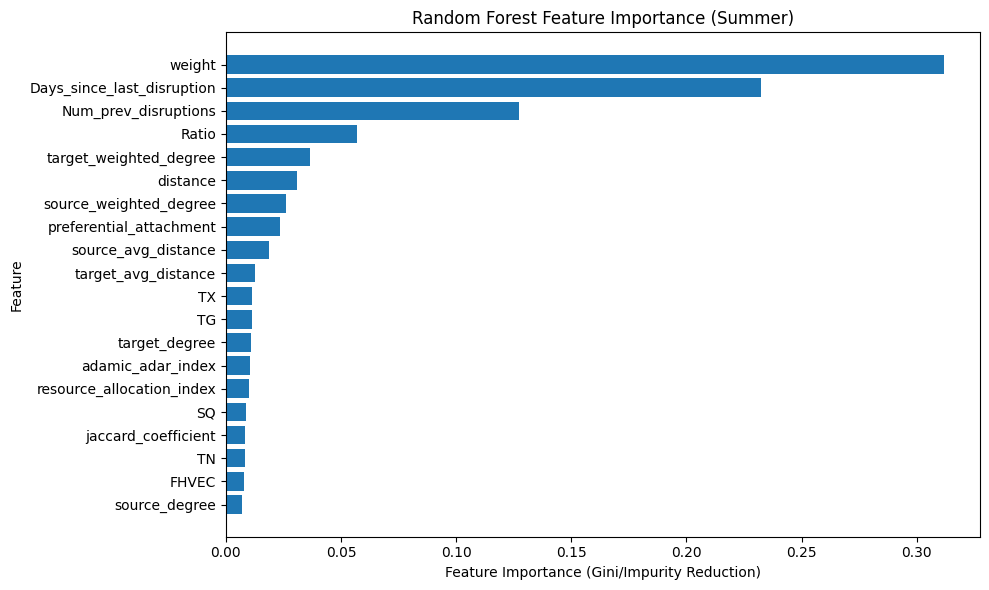

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py:542: FitFailedWarning: 
5 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 1344, in wrapper
    estimator._validate_params()
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraint

Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': False}
Best F1 Score: 0.4339110915462999
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.71      0.81     16959
           1       0.25      0.77      0.38      2165

    accuracy                           0.71     19124
   macro avg       0.61      0.74      0.60     19124
weighted avg       0.88      0.71      0.76     19124

Accuracy: 0.7137
F1 Score: 0.3797
Precision: 0.2515
Recall: 0.7741
Balanced Accuracy: 0.7400
AUC: 0.8104


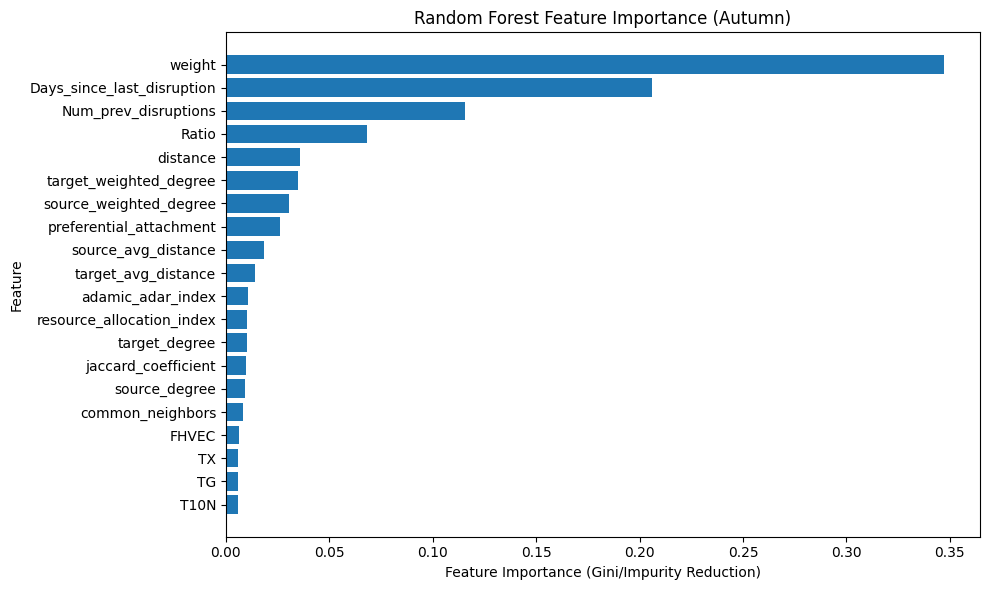

In [25]:
rf_models = {}
rf_params = {}
rf_features = {}

for season in seasons:
    X = seasonal_splits[season]
    rf_models[season], rf_params[season] = optimise(rf, scoring, param_grid_rf, X, season)

[0.00180041 0.01330561 0.00435764 0.00304642 0.02146845 0.00299701
 0.00134852 0.00159016 0.00560476 0.00198346 0.00327876 0.11644011
 0.0113911  0.0085031  0.00822467 0.00463108 0.00937165 0.00181545
 0.00149621 0.00136981 0.00106677 0.00115619 0.08177647 0.0383237
 0.02011799]


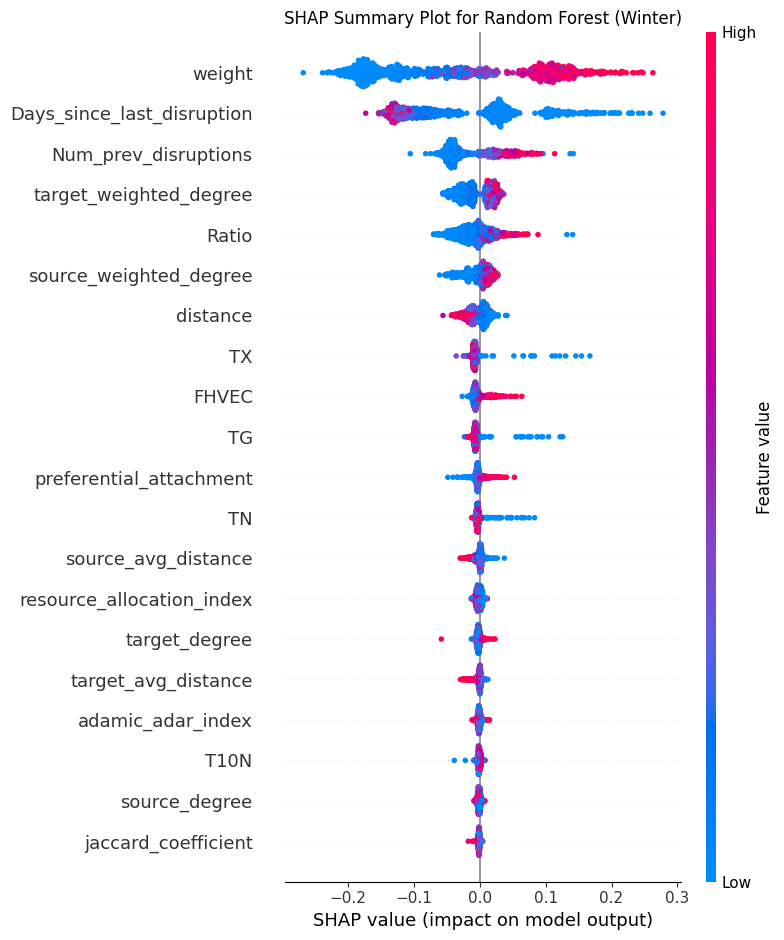

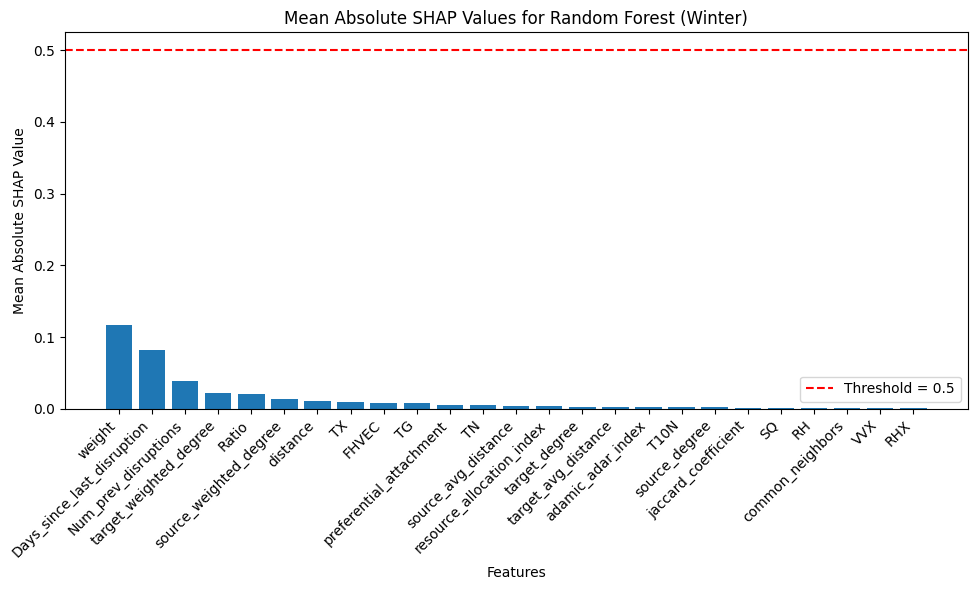

[0.00177081 0.01949924 0.00576583 0.00375396 0.02373312 0.00504767
 0.00121389 0.00179597 0.0071529  0.00196158 0.00166476 0.09567468
 0.01155798 0.00150379 0.00369618 0.00504842 0.00363521 0.00547553
 0.00641119 0.00481726 0.00290154 0.00268922 0.12996244 0.0268196
 0.03062195]


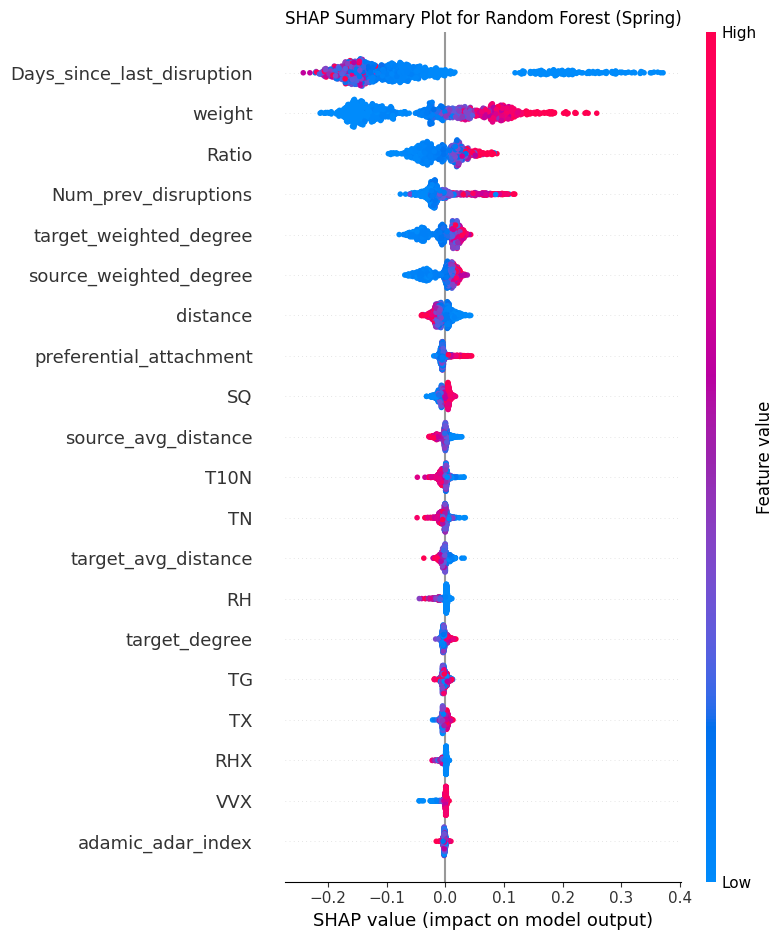

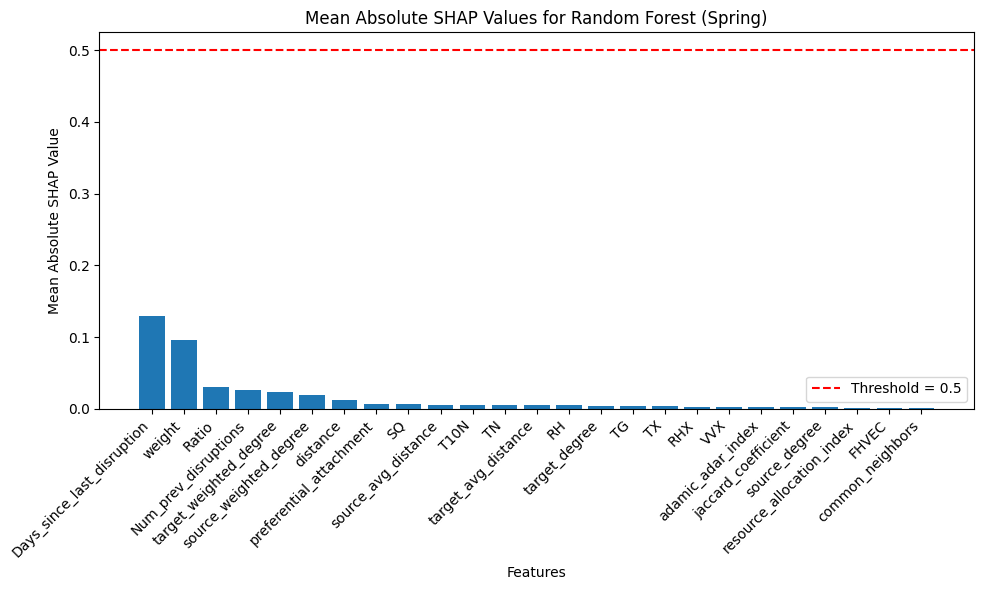

[0.00151839 0.01256755 0.00638571 0.00283554 0.02071438 0.00335471
 0.00165271 0.00253048 0.00551318 0.002707   0.00233279 0.12936568
 0.01723503 0.00205573 0.00367351 0.00177959 0.0040471  0.0013936
 0.0021804  0.00148644 0.0014256  0.00208266 0.08592139 0.04691624
 0.01543811]


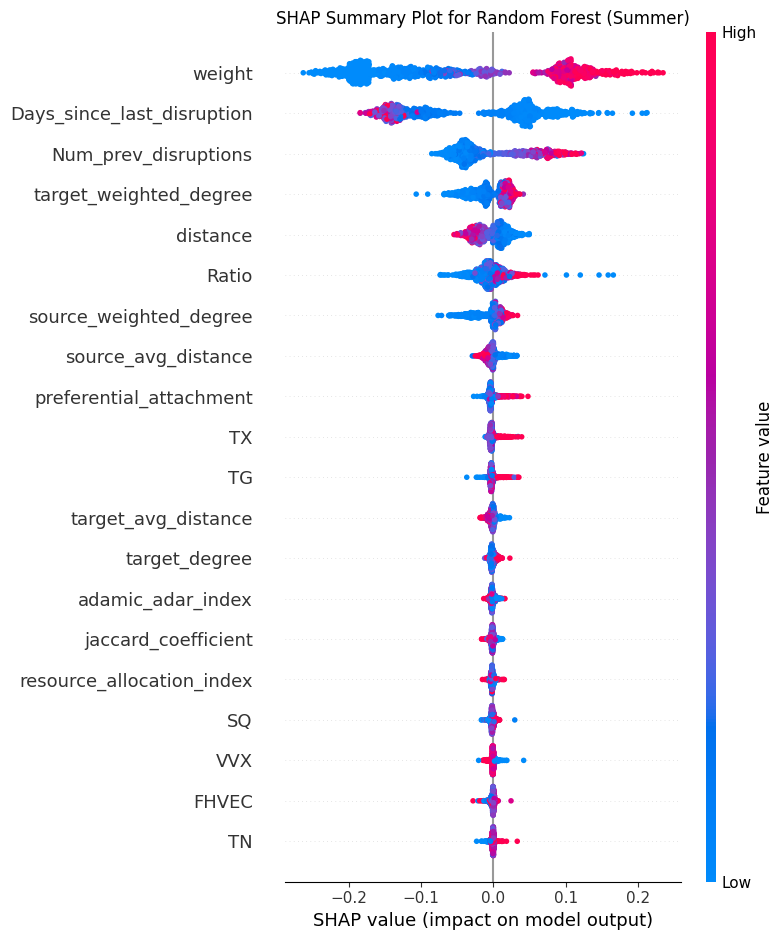

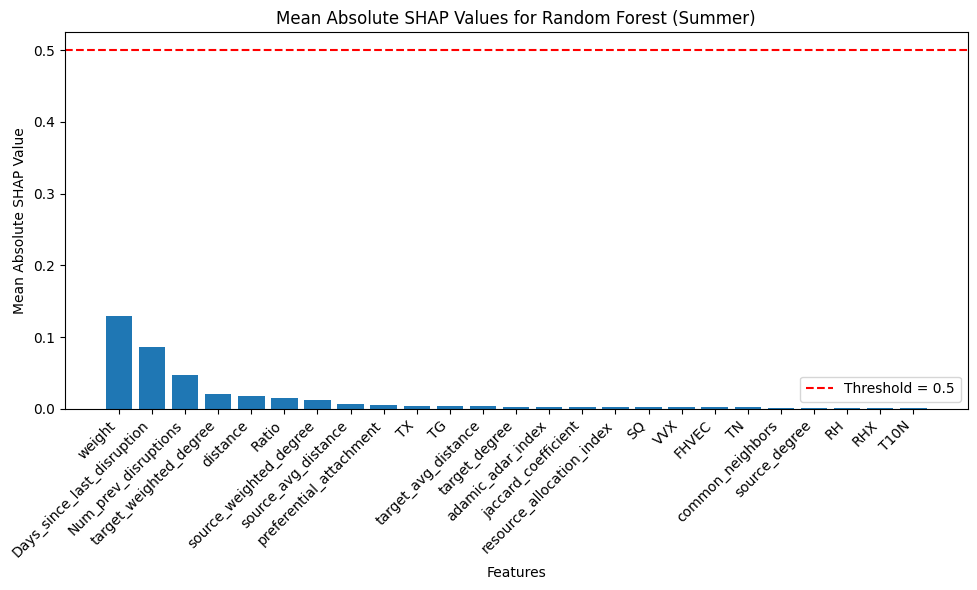

[0.00208545 0.01582667 0.00620897 0.00260144 0.02057901 0.00491236
 0.00202811 0.0032346  0.00630366 0.00253582 0.00236317 0.14337364
 0.02002764 0.00120215 0.00136841 0.00116414 0.00116254 0.00125736
 0.00082944 0.00085171 0.00078906 0.00143732 0.06714331 0.04254518
 0.02051849]


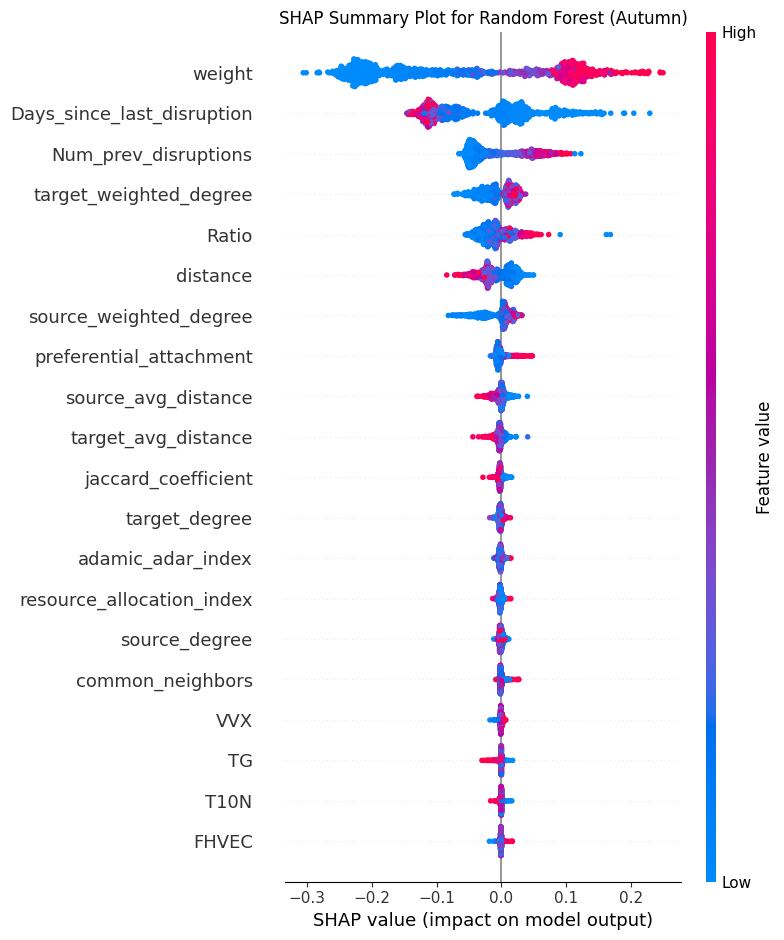

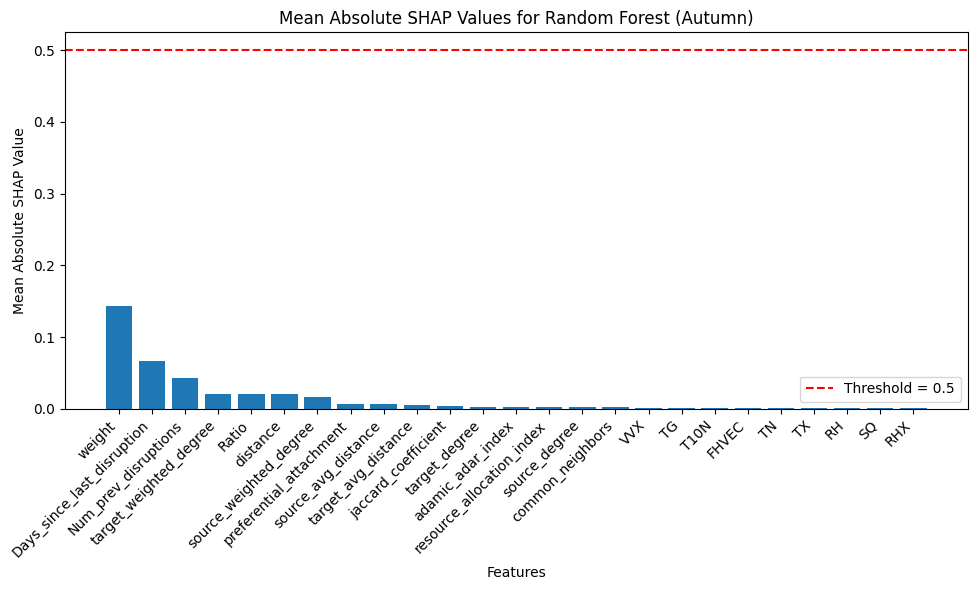

In [26]:
rf_shap_values = {}
for season in seasons:
    X = seasonal_splits[season]
    test_data = split_season_by_year(X, season)
    test_data[f'{season} 2024']
    feature_cols = topo_features + wthr_features + oper_features
    shap_values = plot_shap_values(rf_models[season], X[feature_cols], feature_cols, model_type='random_forest', season=season)
    rf_shap_values[season] = shap_values

In [33]:
rf_top_features = {}

for season in seasons:
    shap_values = rf_shap_values[season]
    mean_shap_values = np.abs(shap_values).mean(axis=0)
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': mean_shap_values
    }).sort_values(by='Importance', ascending=False)
    
    rf_top_features[season] = feature_importance['Feature'].head(10).tolist()

print(rf_top_features)

{'Winter': ['weight', 'Days_since_last_disruption', 'Num_prev_disruptions', 'target_weighted_degree', 'Ratio', 'source_weighted_degree', 'distance', 'TX', 'FHVEC', 'TG'], 'Spring': ['Days_since_last_disruption', 'weight', 'Ratio', 'Num_prev_disruptions', 'target_weighted_degree', 'source_weighted_degree', 'distance', 'preferential_attachment', 'SQ', 'source_avg_distance'], 'Summer': ['weight', 'Days_since_last_disruption', 'Num_prev_disruptions', 'target_weighted_degree', 'distance', 'Ratio', 'source_weighted_degree', 'source_avg_distance', 'preferential_attachment', 'TX'], 'Autumn': ['weight', 'Days_since_last_disruption', 'Num_prev_disruptions', 'target_weighted_degree', 'Ratio', 'distance', 'source_weighted_degree', 'preferential_attachment', 'source_avg_distance', 'target_avg_distance']}


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'subsample': 0.6, 'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 7, 'learning_rate': 0.1}
Best F1 Score: 0.34255072324244457
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2651
           1       0.28      0.30      0.29       210

    accuracy                           0.89      2861
   macro avg       0.61      0.62      0.62      2861
weighted avg       0.90      0.89      0.89      2861

Accuracy: 0.8930
F1 Score: 0.2917
Precision: 0.2838
Recall: 0.3000
Balanced Accuracy: 0.6200
AUC: 0.7894


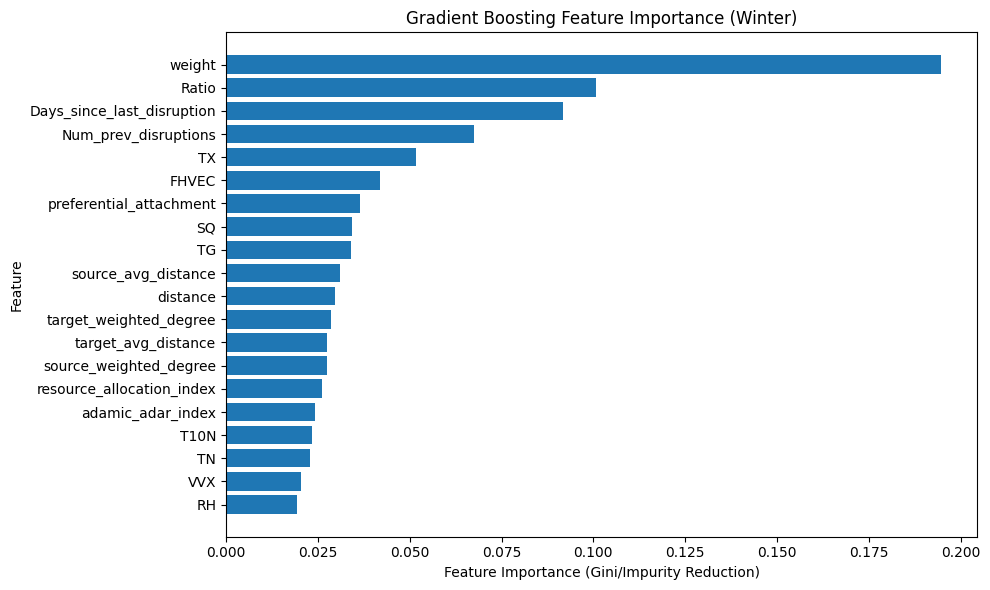

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 5, 'learning_rate': 0.3}
Best F1 Score: 0.3473215353770932
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92     17463
           1       0.32      0.31      0.32      1984

    accuracy                           0.86     19447
   macro avg       0.62      0.62      0.62     19447
weighted avg       0.86      0.86      0.86     19447

Accuracy: 0.8622
F1 Score: 0.3163
Precision: 0.3202
Recall: 0.3125
Balanced Accuracy: 0.6186
AUC: 0.8001


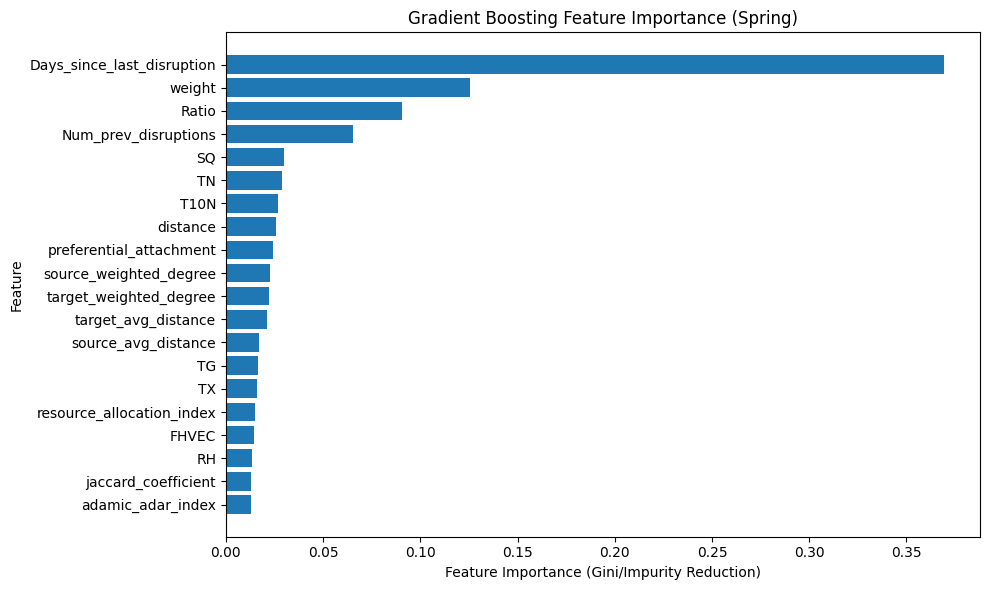

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 5, 'learning_rate': 0.3}
Best F1 Score: 0.31498036607205354
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90     16903
           1       0.28      0.30      0.29      2188

    accuracy                           0.83     19091
   macro avg       0.60      0.60      0.60     19091
weighted avg       0.84      0.83      0.83     19091

Accuracy: 0.8321
F1 Score: 0.2913
Precision: 0.2821
Recall: 0.3012
Balanced Accuracy: 0.6010
AUC: 0.7489


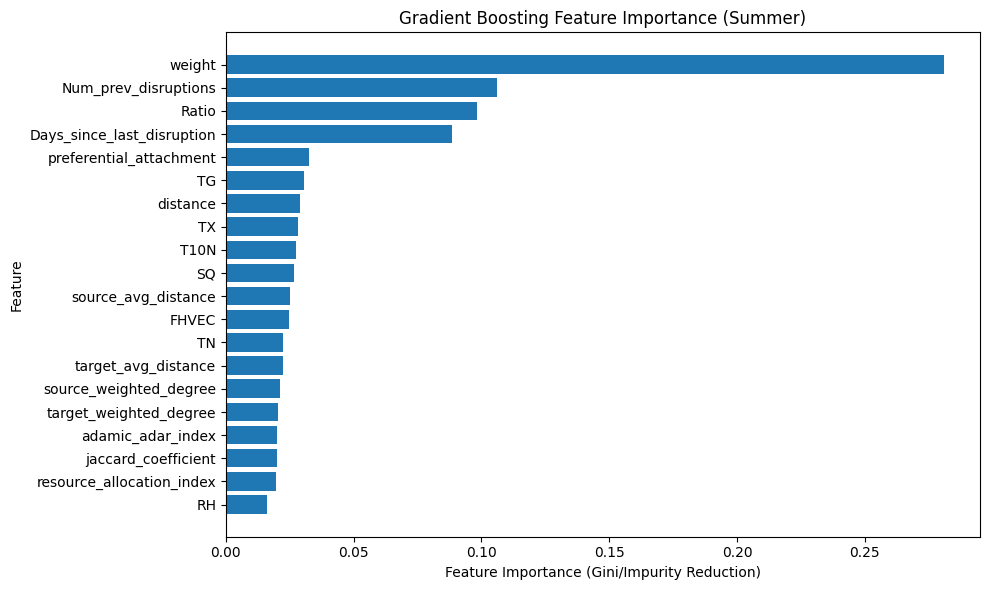

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'subsample': 0.6, 'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 7, 'learning_rate': 0.1}
Best F1 Score: 0.3388728304265463
Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.92      0.92     16959
           1       0.35      0.33      0.34      2165

    accuracy                           0.85     19124
   macro avg       0.63      0.62      0.63     19124
weighted avg       0.85      0.85      0.85     19124

Accuracy: 0.8536
F1 Score: 0.3359
Precision: 0.3454
Recall: 0.3270
Balanced Accuracy: 0.6239
AUC: 0.7807


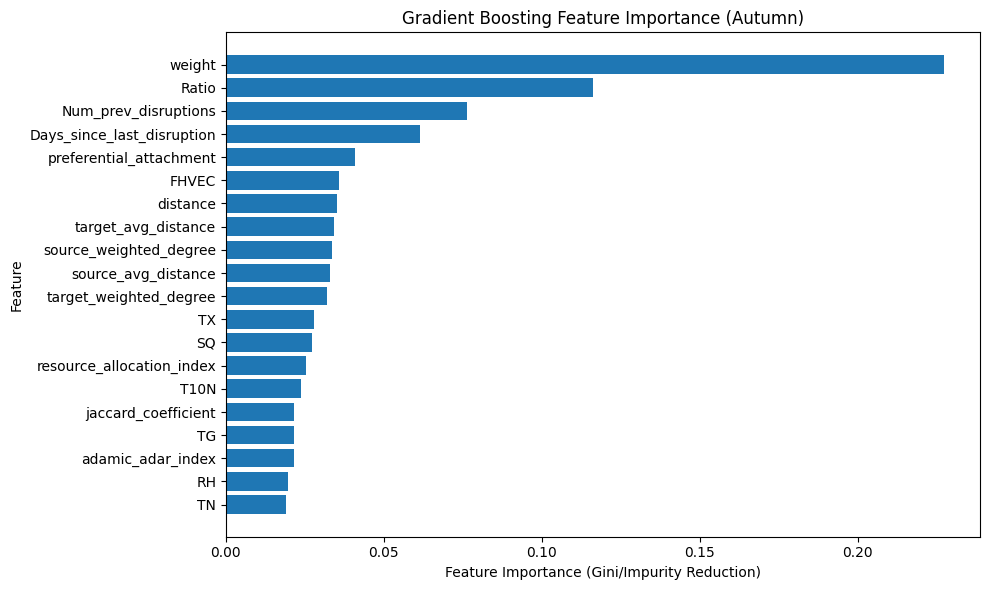

In [189]:
gb_models = {}
gb_params = {}
gb_features = {}

for season in seasons:
    X = seasonal_splits[season]
    gb_models[season], gb_params[season] = optimise(gbdt, scoring, param_grid_gbdt, X, season)

[0.1012263  0.11223172 0.07932701 0.05414108 0.08164069 0.07021788
 0.02977515 0.0451884  0.07983634 0.12152138 0.15764965 1.02829435
 0.14906774 0.13318113 0.12296556 0.06986723 0.09366413 0.07727562
 0.08206332 0.04974845 0.04695103 0.04518448 0.28055143 0.16845655
 0.29822132]


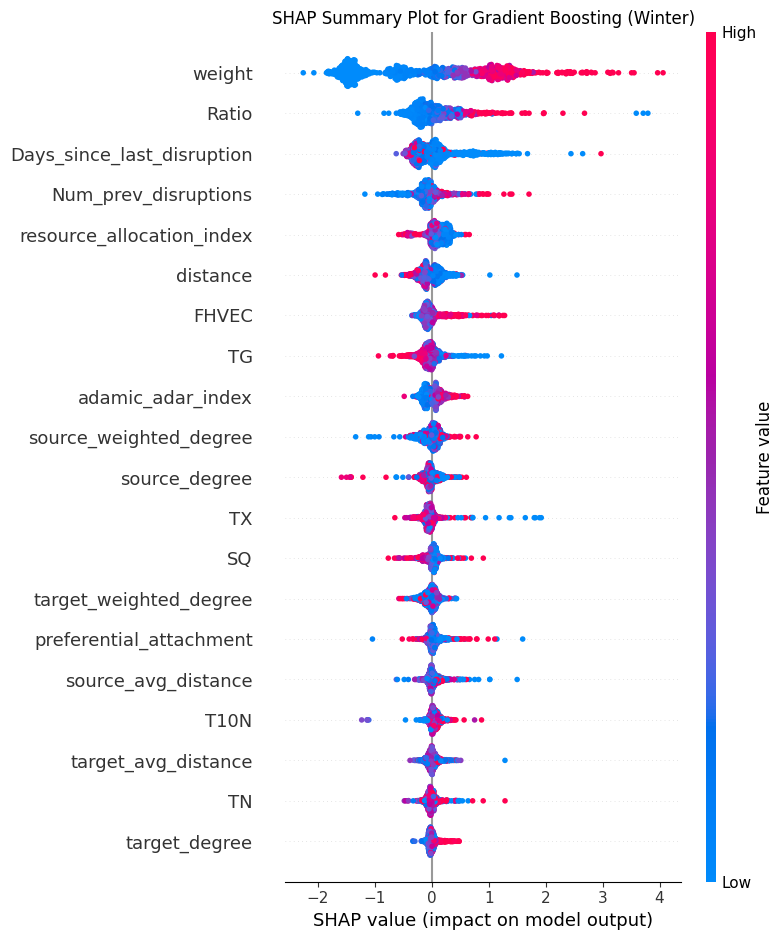

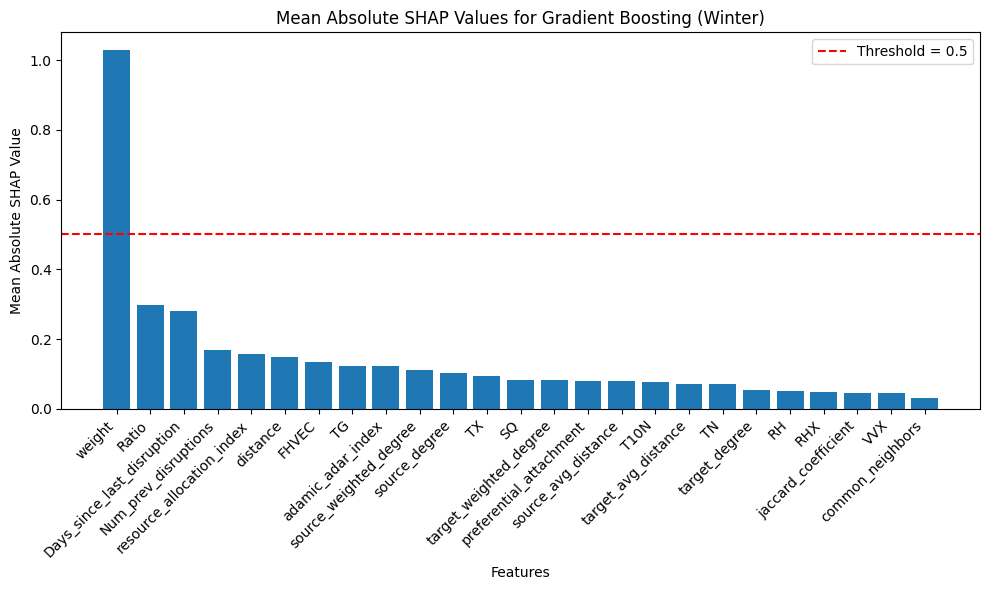

[1.39610584e-01 1.52427434e-01 1.27992083e-01 1.11932098e-01
 1.80158979e-01 9.89847740e-02 3.52536523e-02 9.36502639e-02
 4.39022601e-01 1.10915843e-01 1.73792382e-01 9.94352304e-01
 1.42722531e-01 9.95193239e-02 2.91884454e+04 1.26263100e-01
 2.59063798e+04 1.51444847e+05 9.59957923e+04 1.11073989e-01
 1.13507079e-01 5.11027901e-02 1.13977872e+05 2.27600511e-01
 3.42177604e-01]


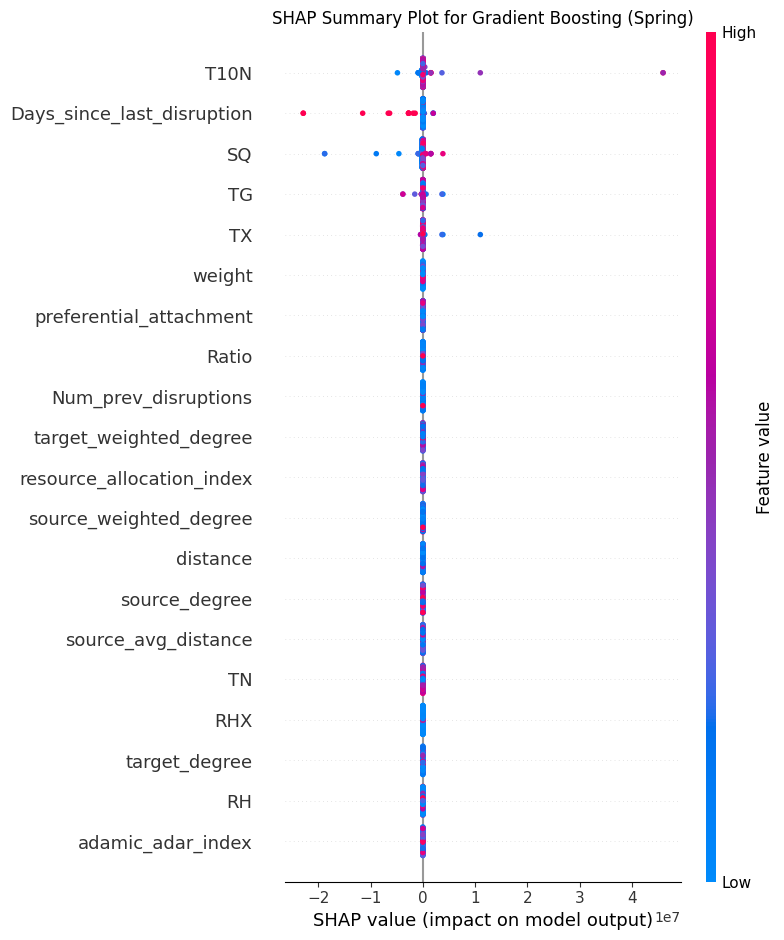

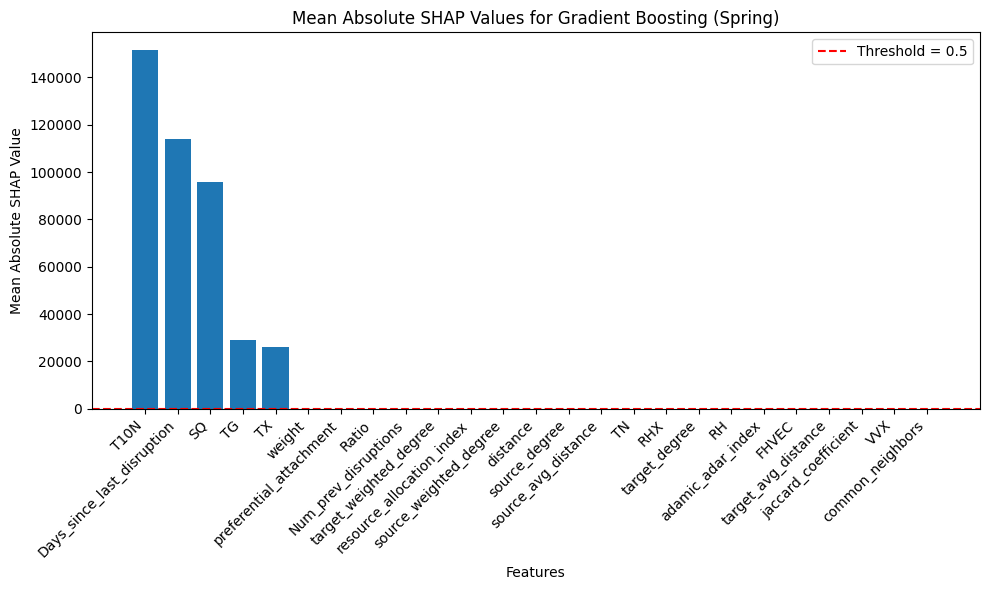

[0.72772342 1.37421147 0.10682392 0.07826964 0.13808291 0.11475586
 0.02703524 0.11125933 0.68830436 0.23766481 0.20804144 0.93259439
 0.1921493  0.09484752 0.17522432 0.16534079 0.11749866 0.1529735
 0.10811318 0.09455531 0.05812795 0.05635446 0.30982494 0.35550374
 0.26600694]


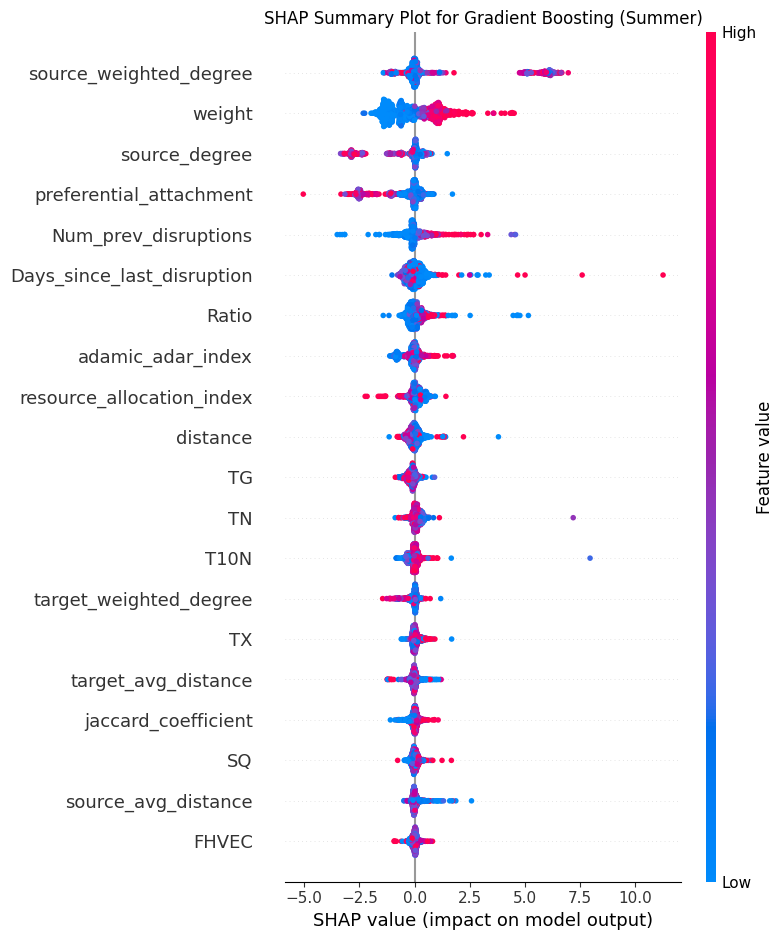

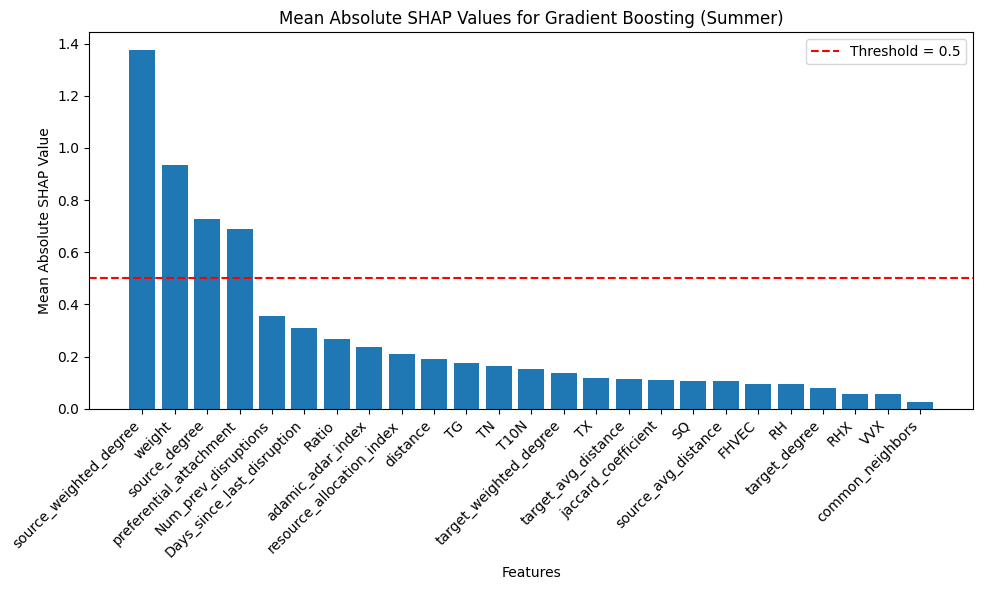

[0.06616634 0.15336252 0.08987054 0.10118745 0.13789967 0.08670035
 0.0289062  0.08571248 0.13496277 0.08316053 0.08133444 1.19974962
 0.20116274 0.0625763  0.07196237 0.06918551 0.08354982 0.07125655
 0.08633757 0.04757561 0.0388178  0.09489885 0.21918853 0.24012884
 0.27021727]


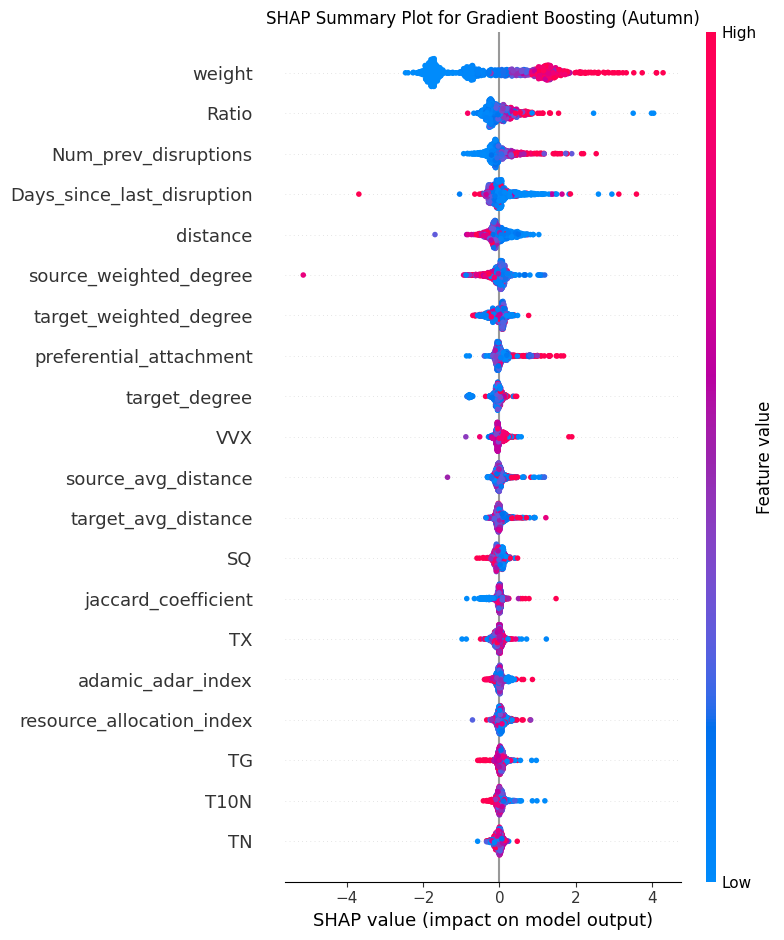

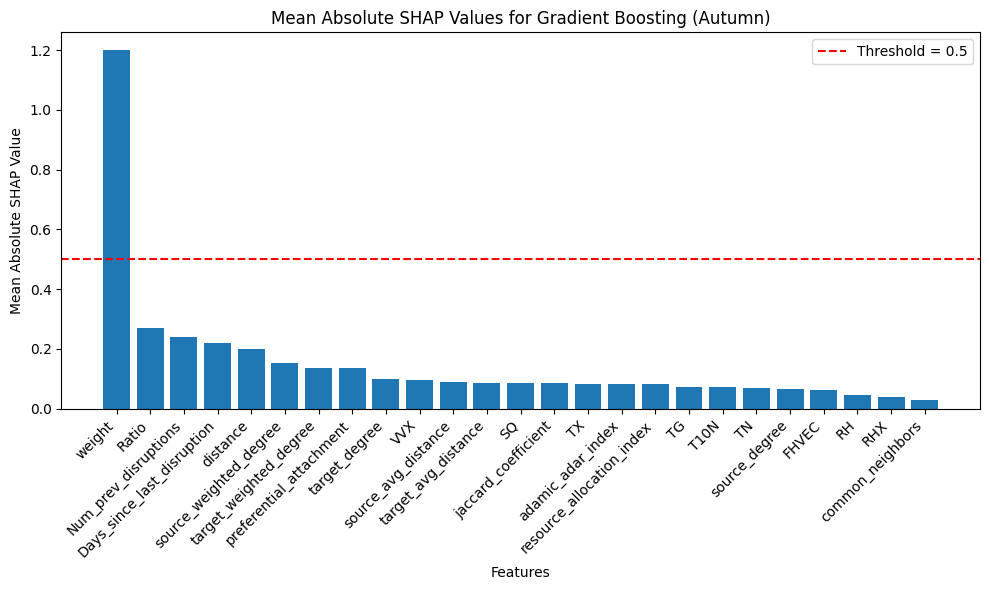

In [108]:
for season in seasons:
    X = seasonal_splits[season]
    test_data = split_season_by_year(X, season)
    test_data[f'{season} 2024']
    feature_cols = topo_features + wthr_features + oper_features
    shap_values = plot_shap_values(gb_models[season], X[feature_cols], feature_cols, model_type='gradient_boosting', season=season)

In [190]:
feature_selection_gb = {}
for season in seasons:
    X = seasonal_splits[season]
    test_data = split_season_by_year(X, season)
    test_data = test_data[f'{season} 2024']
    feature_cols = topo_features + wthr_features + oper_features
    print(gb_models[season].classes_) 
    selected_features_df = shap_select(
        gb_models[season],
        test_data[feature_cols],
        test_data['Disrupted'].astype(int),
        feature_names=feature_cols,
        task="binary",
        threshold=0.05
    )
    print(f"Selected features for {season}:")
    print(selected_features_df)
    selected_features_df = selected_features_df[selected_features_df['selected'] == 1]
    sel_feat_list = selected_features_df['feature name'].tolist()
    feature_selection_gb[season] = sel_feat_list
    print(sel_feat_list)

[0 1]


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 26 out of 26 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 25 out of 25 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarn

Selected features for Winter:
                  feature name    t-value  stat.significance  coefficient  \
0                       weight  13.395565       6.418560e-41     0.938780   
1                        Ratio   6.880931       5.946253e-12     1.154486   
2   Days_since_last_disruption   3.077715       2.085946e-03     0.497634   
3                source_degree   2.803984       5.047536e-03     1.467893   
4       source_weighted_degree   2.731699       6.300864e-03     0.988749   
5                         T10N   2.612795       8.980517e-03     2.587510   
6         Num_prev_disruptions   2.277277       2.276971e-02     0.343561   
7                          RHX   1.426758       1.536496e-01     0.659634   
8                     distance   1.042920       2.969852e-01     0.515759   
9          target_avg_distance   0.502811       6.150969e-01     0.361570   
10                          TG   0.484425       6.280845e-01     0.377250   
11                         VVX   0.099837     

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\discrete\discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 26 out of 26 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-pa

Selected features for Spring:
                  feature name    t-value  stat.significance   coefficient  \
0                       weight  33.518205      2.617244e-246  6.879231e-01   
1         Num_prev_disruptions  21.746555      7.446664e-105  8.681689e-01   
2                        Ratio  12.432527       1.740448e-35  4.229020e-01   
3             common_neighbors   9.143757       6.031977e-20  2.932087e+00   
4                           TX   3.865145       1.110232e-04  7.029416e-07   
5                           SQ   2.977069       2.910182e-03  6.129077e-07   
6    resource_allocation_index   2.778787       5.456225e-03  2.400782e-01   
7   Days_since_last_disruption   2.623943       8.691839e-03  2.646596e-07   
8                         T10N   2.581182       9.846259e-03  6.172816e-06   
9       target_weighted_degree   0.985903       3.241807e-01  8.572135e-02   
10                         RHX   0.714969       4.746283e-01  1.562096e-01   
11         target_avg_distance   0

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 26 out of 26 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 25 out of 25 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarn

Selected features for Summer:
                  feature name    t-value  stat.significance  coefficient  \
0                       weight  30.073525      1.075581e-198     0.599393   
1         Num_prev_disruptions  23.515900      2.804814e-122     0.555117   
2       source_weighted_degree  15.195053       3.813554e-52     0.133549   
3                        Ratio   9.518034       1.764865e-21     0.277149   
4                target_degree   5.186834       2.138994e-07     0.971941   
5            adamic_adar_index   4.108962       3.974422e-05     0.337732   
6                          RHX   4.007789       6.128977e-05     0.684943   
7       target_weighted_degree   3.606030       3.109168e-04     0.332779   
8      preferential_attachment   3.601705       3.161371e-04     0.156335   
9                           TN   2.882925       3.940008e-03     0.385032   
10            common_neighbors   2.767088       5.655942e-03     1.000482   
11                    distance   2.407733     

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 26 out of 26 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 25 out of 25 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarn

Selected features for Autumn:
                  feature name    t-value  stat.significance  coefficient  \
0                       weight  36.922401      2.020150e-298     0.745887   
1         Num_prev_disruptions  23.801098      3.253464e-125     0.867207   
2                        Ratio  17.318617       3.404391e-67     0.756501   
3                     distance   6.407064       1.483484e-10     0.601888   
4             common_neighbors   4.675086       2.938305e-06     1.622660   
5                target_degree   2.629670       8.546780e-03     0.488711   
6          jaccard_coefficient   2.014901       4.391502e-02     0.369332   
7       source_weighted_degree   1.465489       1.427874e-01     0.085295   
8    resource_allocation_index   1.130164       2.584070e-01     0.177877   
9                          RHX   0.680936       4.959118e-01     0.219165   
10         target_avg_distance   0.599612       5.487650e-01     0.101550   
11                        T10N  -0.292402     

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 3 out of 3 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 2 out of 2 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning:

In [228]:
gb_models_selected = {}

for season in seasons:
    # Get the seasonal data
    X = seasonal_splits[season]
    test_data = split_season_by_year(X, season)
    train_data = pd.concat([test_data[year] for year in test_data if year != f'{season} 2024'])
    test_data = test_data[f'{season} 2024']
    
    # Extract selected features
    selected_features = feature_selection_gb[season]
    
    # Prepare training and testing data
    X_train = train_data[selected_features]
    y_train = train_data['Disrupted'].astype(int)
    X_test = test_data[selected_features]
    y_test = test_data['Disrupted'].astype(int)
    
    # Train the XGBoost model
    model = GradientBoostingClassifier(random_state=42, **gb_params[season])
    model.fit(X_train, y_train)
    
    # Store the trained model
    gb_models_selected[season] = model
    
    # Evaluate the model
    y_pred = model.predict(X_test)
    print(f"Season: {season}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")
    print(f"AUC: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.4f}")

Season: Winter
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2651
           1       0.28      0.31      0.29       210

    accuracy                           0.89      2861
   macro avg       0.61      0.62      0.62      2861
weighted avg       0.90      0.89      0.89      2861

Accuracy: 0.8909
F1 Score: 0.2941
Precision: 0.2802
Recall: 0.3095
Balanced Accuracy: 0.6233
AUC: 0.7926
Season: Spring
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.92     17463
           1       0.31      0.34      0.32      1984

    accuracy                           0.85     19447
   macro avg       0.62      0.63      0.62     19447
weighted avg       0.86      0.85      0.86     19447

Accuracy: 0.8546
F1 Score: 0.3234
Precision: 0.3078
Recall: 0.3407
Balanced Accuracy: 0.6268
AUC: 0.7892
Season: Summer
Classification Report:
              precisio

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py:542: FitFailedWarning: 
15 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 1351, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\line

Best Parameters: {'solver': 'newton-cg', 'penalty': 'l2', 'C': 1}
Best F1 Score: 0.3812608306252964
Test Set Classification Report:
              precision    recall  f1-score   support

       False       0.97      0.67      0.80      2651
        True       0.15      0.75      0.26       210

    accuracy                           0.68      2861
   macro avg       0.56      0.71      0.53      2861
weighted avg       0.91      0.68      0.76      2861

Accuracy: 0.6798
F1 Score: 0.2553
Precision: 0.1539
Recall: 0.7476
Balanced Accuracy: 0.7110
AUC: 0.7786


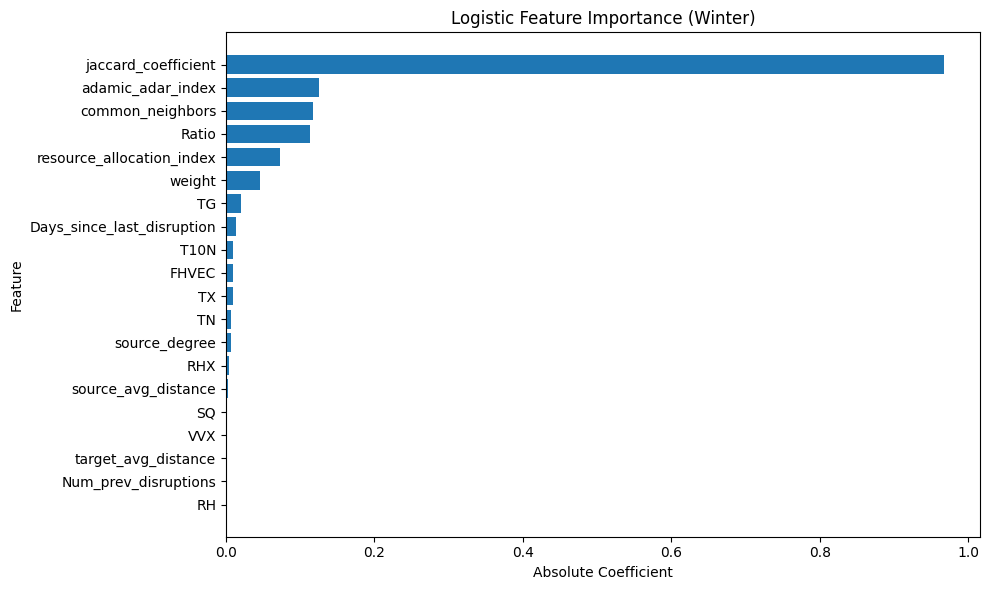

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py:542: FitFailedWarning: 
15 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 1351, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\line

Best Parameters: {'solver': 'newton-cg', 'penalty': 'l2', 'C': 0.001}
Best F1 Score: 0.40997236853133784
Test Set Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.75      0.84     17463
        True       0.24      0.70      0.36      1984

    accuracy                           0.74     19447
   macro avg       0.60      0.72      0.60     19447
weighted avg       0.88      0.74      0.79     19447

Accuracy: 0.7445
F1 Score: 0.3581
Precision: 0.2408
Recall: 0.6986
Balanced Accuracy: 0.7241
AUC: 0.7956


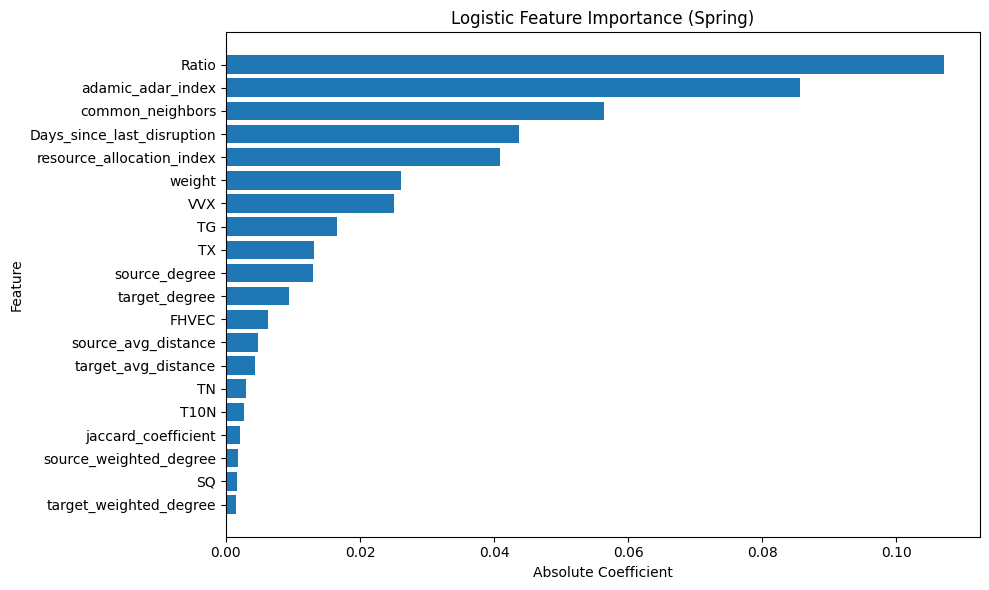

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py:542: FitFailedWarning: 
15 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 1351, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\line

Best Parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 0.01}
Best F1 Score: 0.3875099925830442
Test Set Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.67      0.79     16903
        True       0.23      0.77      0.36      2188

    accuracy                           0.68     19091
   macro avg       0.59      0.72      0.57     19091
weighted avg       0.87      0.68      0.74     19091

Accuracy: 0.6810
F1 Score: 0.3561
Precision: 0.2316
Recall: 0.7697
Balanced Accuracy: 0.7196
AUC: 0.7868


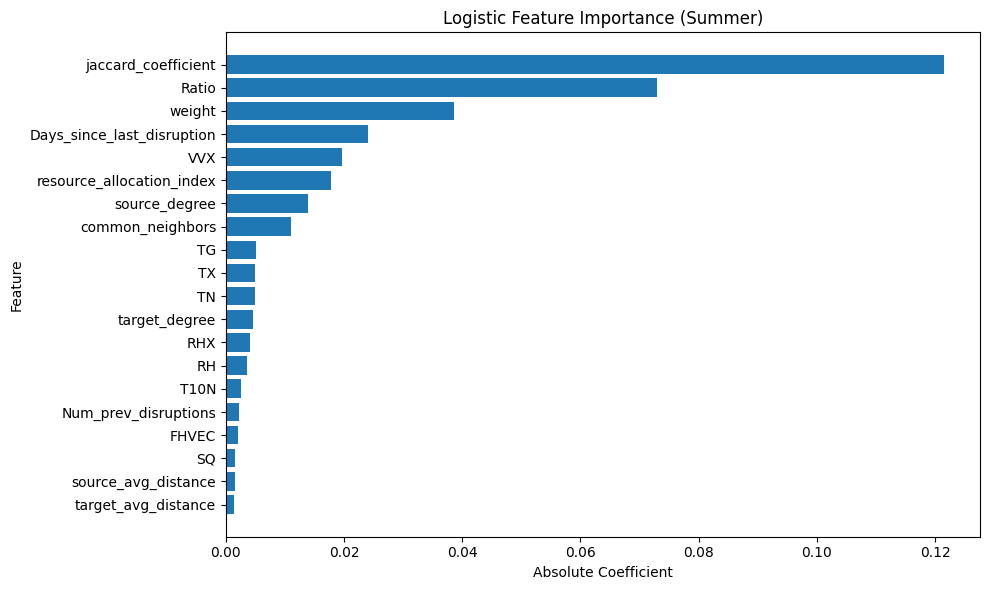

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py:542: FitFailedWarning: 
15 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\model_selection\_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\base.py", line 1351, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\line

Best Parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 100}
Best F1 Score: 0.40546447748209813
Test Set Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.69      0.80     16959
        True       0.24      0.75      0.36      2165

    accuracy                           0.70     19124
   macro avg       0.60      0.72      0.58     19124
weighted avg       0.87      0.70      0.75     19124

Accuracy: 0.6967
F1 Score: 0.3593
Precision: 0.2361
Recall: 0.7510
Balanced Accuracy: 0.7204
AUC: 0.7922


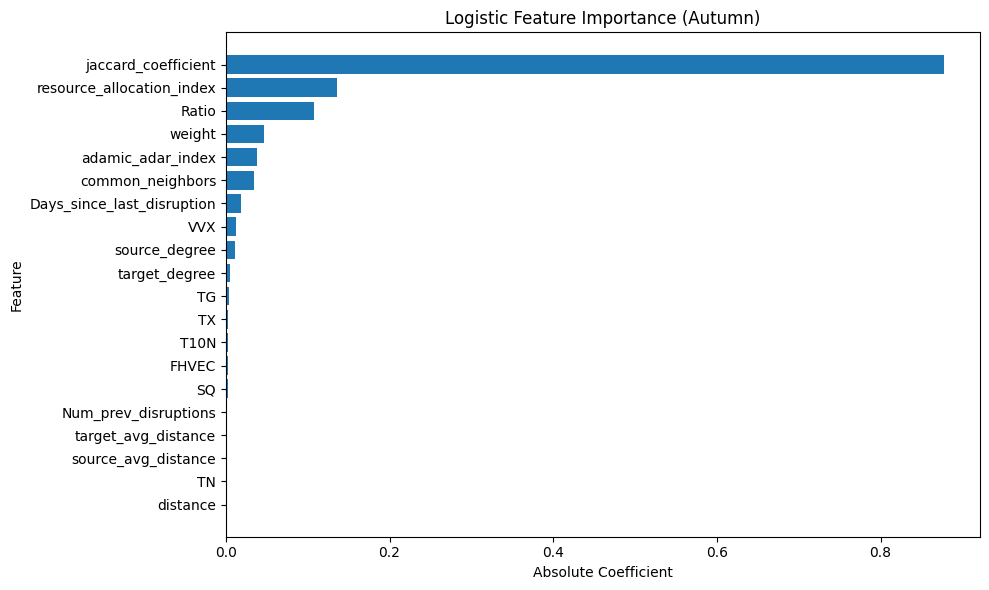

In [109]:
lr_models = {}
lr_params = {}
lr_features = {}

for season in seasons:
    X = seasonal_splits[season]
    lr_models[season], lr_params[season] = optimise(logres, scoring, param_grid_lr, X, season)

Using 1000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 1000/1000 [06:51<00:00,  2.43it/s]
C:\Users\brake\AppData\Local\Temp\ipykernel_2704\1203138912.py:68: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sampled, feature_names=feature_names, max_display=20, show=False)


[6.97365954e-03 4.46402074e-03 3.55310769e-03 0.00000000e+00
 1.36303889e-04 1.21964276e-03 3.33633860e-02 7.35655954e-03
 0.00000000e+00 1.47927704e-02 9.34023594e-05 1.22755603e-01
 5.20234129e-06 3.55815749e-02 1.02289656e-01 3.49209236e-02
 4.15479335e-02 6.52902093e-02 3.26682033e-03 1.87986511e-03
 2.11895968e-03 8.24065300e-05 5.54849773e-02 2.32976732e-02
 2.47999061e-02]


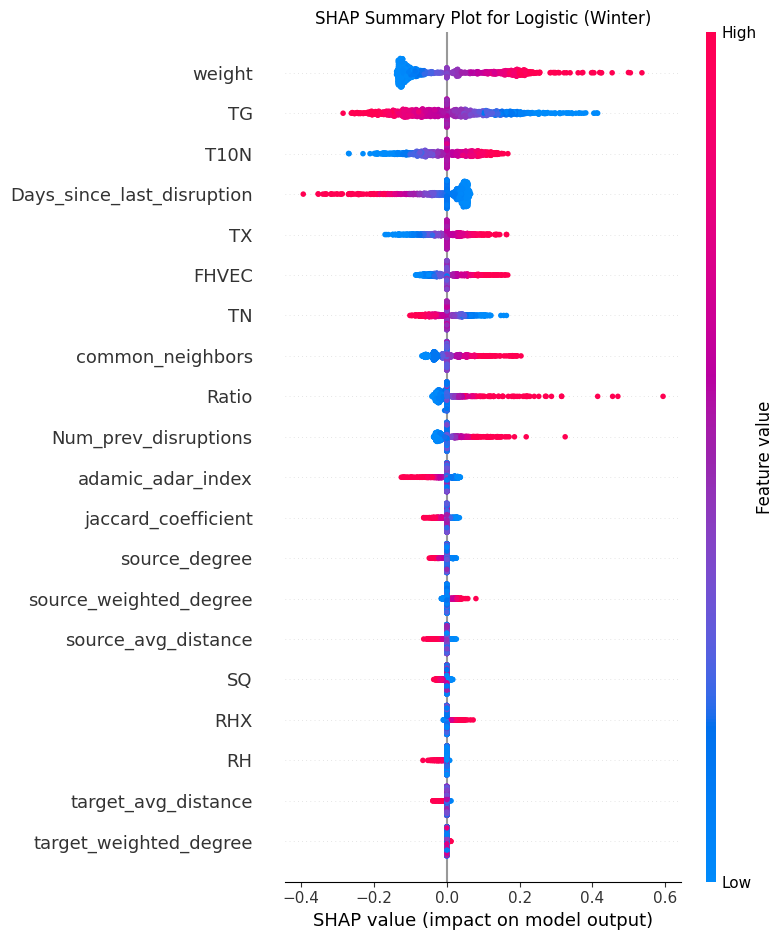

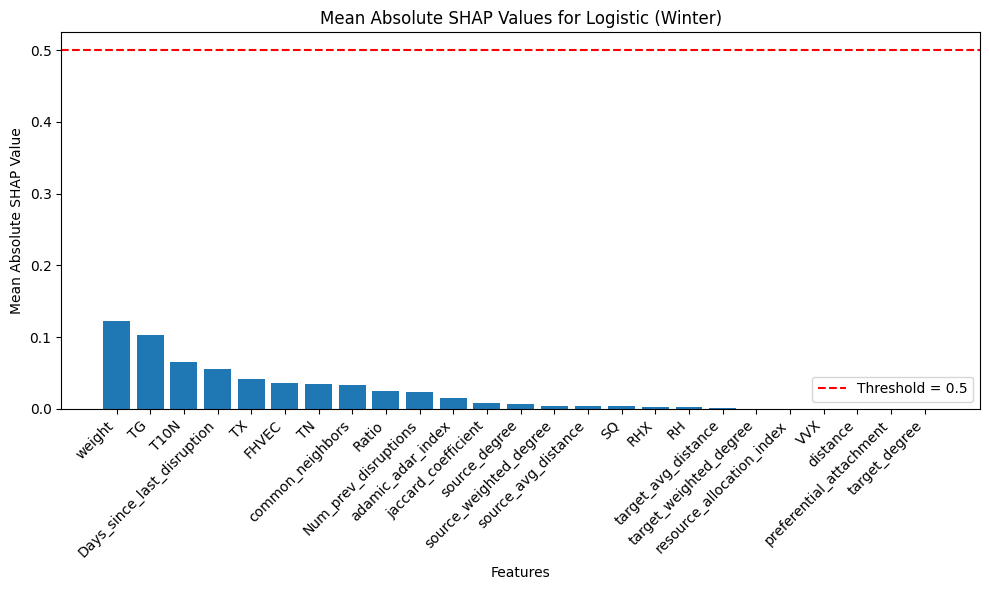

Using 1000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 1000/1000 [06:52<00:00,  2.43it/s]
C:\Users\brake\AppData\Local\Temp\ipykernel_2704\1203138912.py:68: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sampled, feature_names=feature_names, max_display=20, show=False)


[0.01965895 0.03135632 0.0063684  0.01186413 0.02388978 0.00618287
 0.00827675 0.         0.0026263  0.00383378 0.         0.0653548
 0.00237568 0.0088134  0.10426017 0.01232302 0.09486806 0.01319638
 0.00382015 0.00085944 0.00019081 0.00680945 0.1226026  0.01041368
 0.02257522]


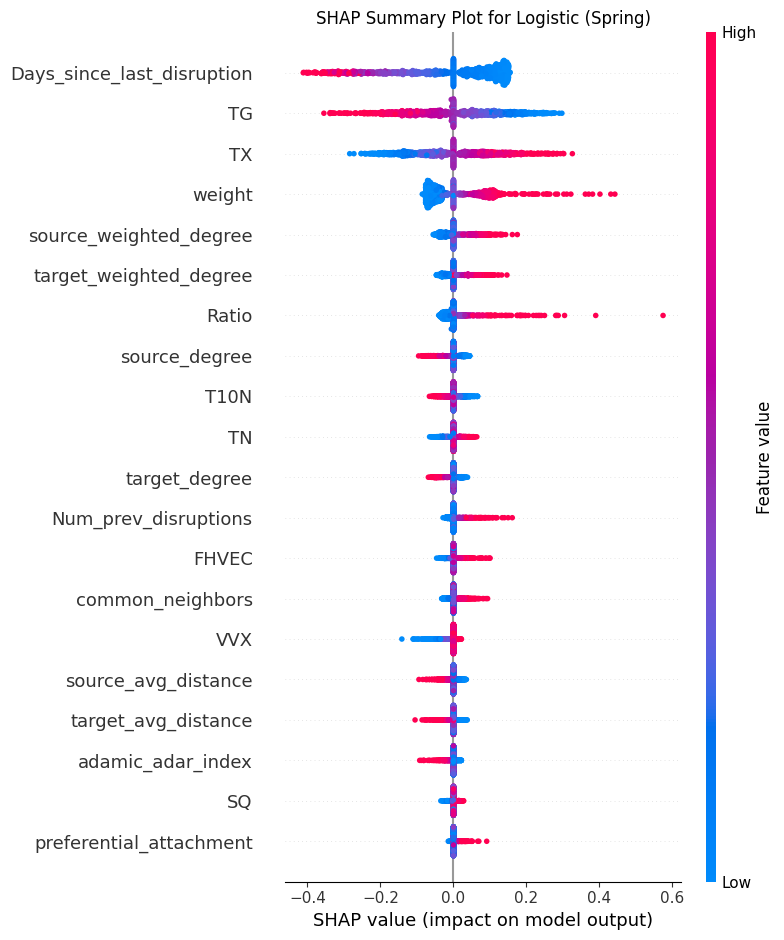

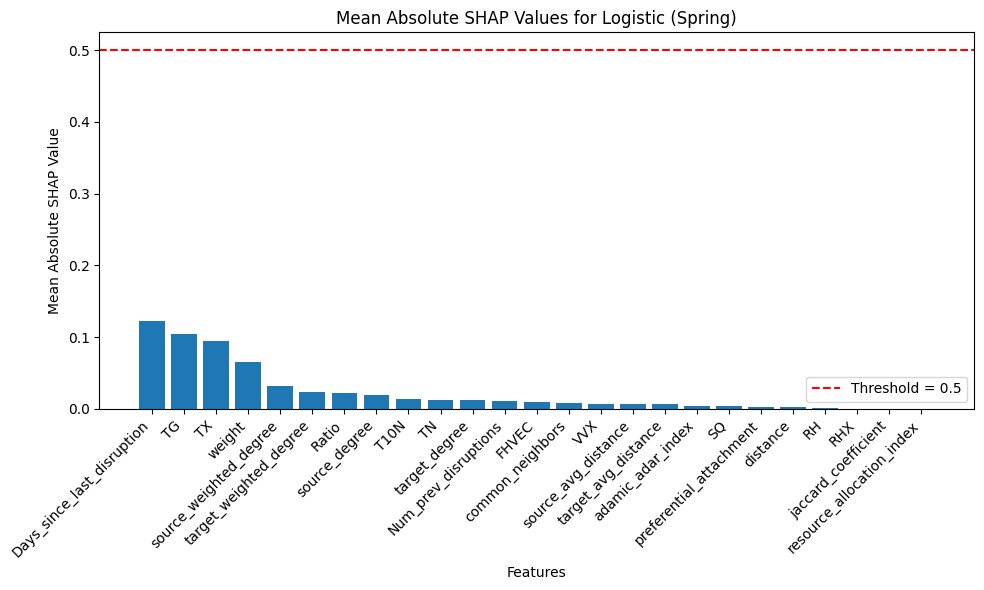

Using 1000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 1000/1000 [06:48<00:00,  2.45it/s]
C:\Users\brake\AppData\Local\Temp\ipykernel_2704\1203138912.py:68: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sampled, feature_names=feature_names, max_display=20, show=False)


[2.45689604e-02 2.05203855e-02 7.36652500e-04 4.72699726e-03
 8.14565715e-03 7.04057567e-04 2.85087771e-04 4.80707278e-06
 7.51020868e-04 0.00000000e+00 0.00000000e+00 1.12150190e-01
 1.87183773e-03 8.23626011e-04 1.86235898e-02 1.77465598e-02
 2.52343318e-02 9.07216989e-03 5.55333648e-03 1.77995274e-02
 5.82134542e-03 4.27376863e-03 8.62917047e-02 4.73089254e-02
 1.50718563e-02]


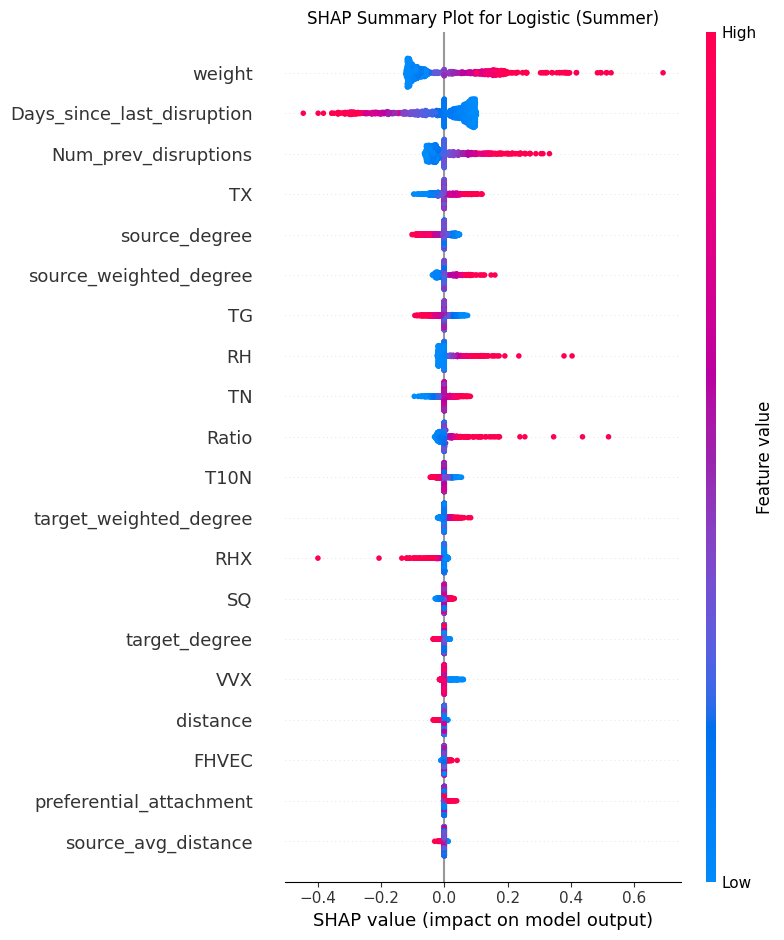

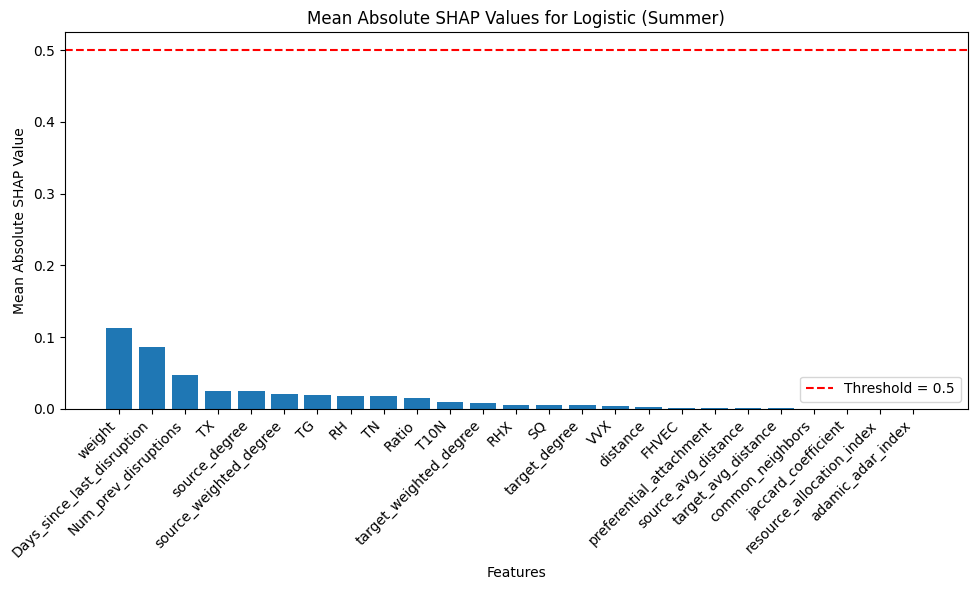

Using 1000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 1000/1000 [06:47<00:00,  2.46it/s]
C:\Users\brake\AppData\Local\Temp\ipykernel_2704\1203138912.py:68: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sampled, feature_names=feature_names, max_display=20, show=False)


[1.98744319e-02 8.79440160e-03 7.72672574e-04 4.78927394e-03
 1.33814827e-03 8.30540534e-04 5.54910025e-03 8.15736775e-03
 6.07801960e-04 1.06540957e-03 1.60633215e-03 1.26078013e-01
 2.83837802e-03 3.14887150e-03 2.32634945e-02 3.75869996e-03
 2.12296061e-02 1.54970300e-02 5.39261257e-03 2.79630004e-05
 1.63877544e-05 9.15103013e-03 7.43685041e-02 3.86900971e-02
 1.85179074e-02]


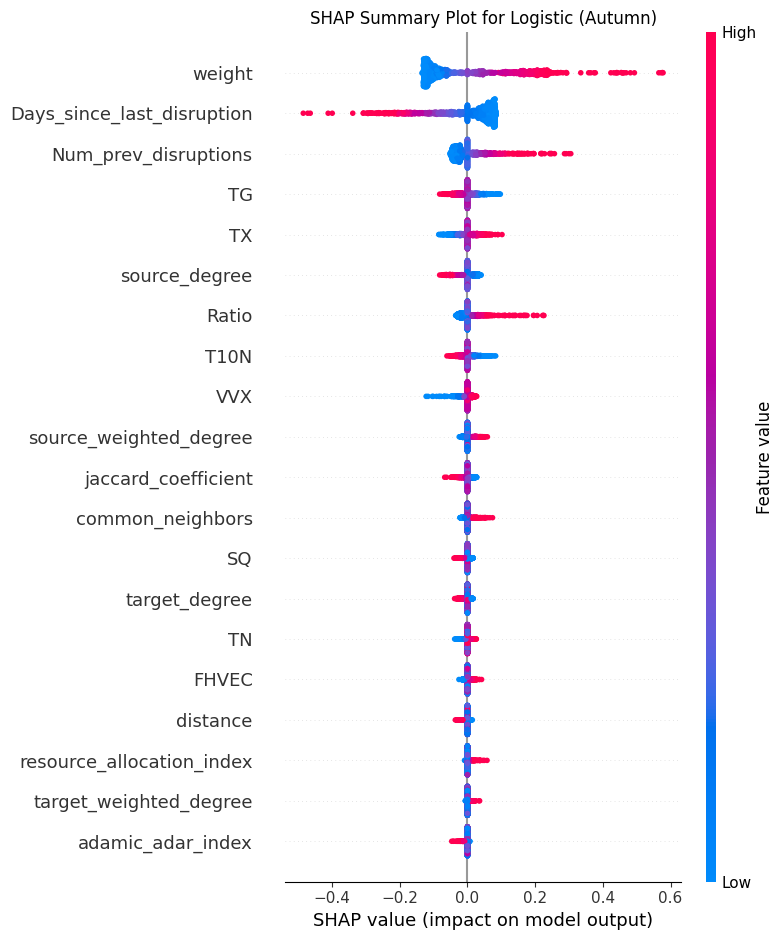

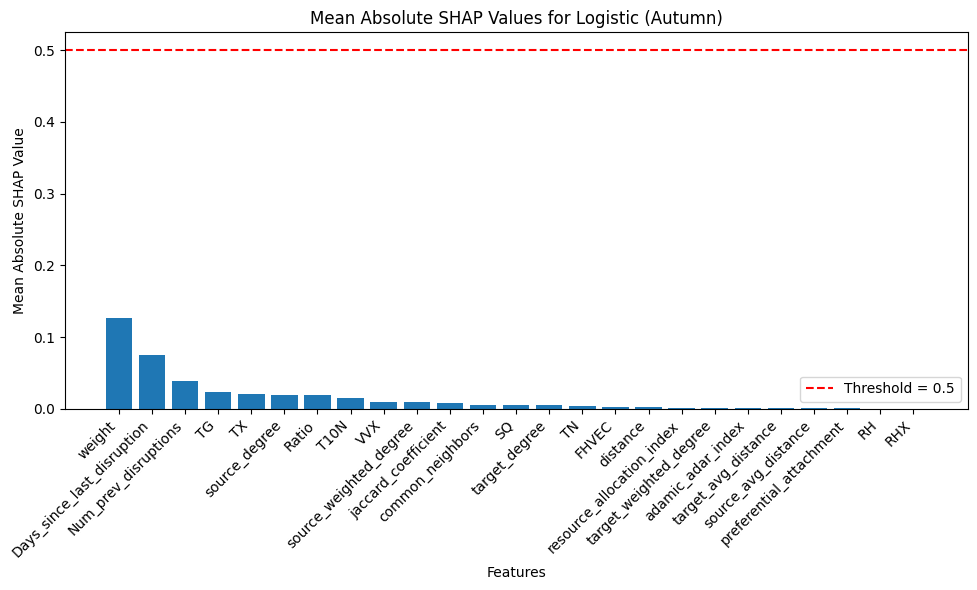

In [192]:
lr_shap_values = {}
for season in seasons:
    X = seasonal_splits[season]
    test_data = split_season_by_year(X, season)
    test_data[f'{season} 2024']
    feature_cols = topo_features + wthr_features + oper_features
    shap_values = plot_shap_values(lr_models[season], X[feature_cols], feature_cols, model_type='logistic', season=season)
    lr_shap_values[season] = shap_values

In [231]:
lr_top_features = {}

for season in seasons:
    shap_values = lr_shap_values[season]
    mean_shap_values = np.abs(shap_values).mean(axis=0)
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': mean_shap_values
    }).sort_values(by='Importance', ascending=False)
    
    lr_top_features[season] = feature_importance['Feature'].head(10).tolist()

print(lr_top_features)

{'Winter': ['weight', 'TG', 'T10N', 'Days_since_last_disruption', 'TX', 'FHVEC', 'TN', 'common_neighbors', 'Ratio', 'Num_prev_disruptions'], 'Spring': ['Days_since_last_disruption', 'TG', 'TX', 'weight', 'source_weighted_degree', 'target_weighted_degree', 'Ratio', 'source_degree', 'T10N', 'TN'], 'Summer': ['weight', 'Days_since_last_disruption', 'Num_prev_disruptions', 'TX', 'source_degree', 'source_weighted_degree', 'TG', 'RH', 'TN', 'Ratio'], 'Autumn': ['weight', 'Days_since_last_disruption', 'Num_prev_disruptions', 'TG', 'TX', 'source_degree', 'Ratio', 'T10N', 'VVX', 'source_weighted_degree']}


In [232]:
def bootstrap_f1_scores(model, X, y, n_bootstraps=100, seed=42):
    rng = np.random.RandomState(seed)
    f1_scores = []
    for _ in range(n_bootstraps):
        indices = rng.choice(len(X), len(X), replace=True)
        X_sample = X.iloc[indices]
        y_sample = y.iloc[indices]
        y_pred = model.predict(X_sample)
        f1 = f1_score(y_sample, y_pred)
        f1_scores.append(f1)
    return f1_scores

def compare_models(models, X_test_dict, y_test, season):
    """
    Compare different models using paired t-tests on bootstrapped F1 scores.
    """
    f1_scores_by_model = {
        name: bootstrap_f1_scores(model, X_test_dict[name], y_test)
        for name, model in models.items()
    }

    model_names = list(f1_scores_by_model.keys())
    
    print(f"\n--- Paired t-tests for {season} ---")
    for i in range(len(model_names)):
        for j in range(i + 1, len(model_names)):
            m1, m2 = model_names[i], model_names[j]
            t_stat, p_val = ttest_rel(f1_scores_by_model[m1], f1_scores_by_model[m2])
            print(f"{m1} vs {m2}: t = {t_stat:.3f}, p = {p_val:.4f}")
    
    return f1_scores_by_model

# Dictionary to store F1 scores for each season
season_f1_scores = {}

for season in seasons:
    # Get the seasonal data
    X = seasonal_splits[season]
    year_split = split_season_by_year(X, season)
    train_data = pd.concat([year_split[year] for year in year_split if year != f'{season} 2024'])
    test_data = year_split[f'{season} 2024']
    
    # Extract selected features
    selected_features = {
        'xgb': feature_selection_xgb[season],
        'rf': rf_top_features[season],
        'gbdt': feature_selection_gb[season],
        'logres': lr_top_features[season]
    }
    
    y_train = train_data['Disrupted'].astype(int)
    y_test = test_data['Disrupted'].astype(int)
    
    # Train and store models
    models = {}
    X_test_dict = {}
    for model_name in ['xgb', 'rf', 'gbdt', 'logres']:
        X_train = train_data[selected_features[model_name]]
        X_test = test_data[selected_features[model_name]]
        
        if model_name == 'xgb':
            model = XGBClassifier(random_state=42, **xgb_params[season])
        elif model_name == 'rf':
            model = RandomForestClassifier(random_state=42, **rf_params[season])
        elif model_name == 'gbdt':
            model = GradientBoostingClassifier(random_state=42, **gb_params[season])
        elif model_name == 'logres':
            model = LogisticRegression(random_state=42, **lr_params[season])
        
        model.fit(X_train, y_train)
        models[model_name] = model
        X_test_dict[model_name] = X_test

    # Run paired t-tests using bootstrap scores
    f1_scores = compare_models(models, X_test_dict, y_test, season)
    season_f1_scores[season] = {k: np.mean(v) for k, v in f1_scores.items()}


--- Paired t-tests for Winter ---
xgb vs rf: t = -4.612, p = 0.0000
xgb vs gbdt: t = 2.874, p = 0.0050
xgb vs logres: t = -9.054, p = 0.0000
rf vs gbdt: t = 8.203, p = 0.0000
rf vs logres: t = -5.763, p = 0.0000
gbdt vs logres: t = -15.764, p = 0.0000

--- Paired t-tests for Spring ---
xgb vs rf: t = 65.005, p = 0.0000
xgb vs gbdt: t = 45.393, p = 0.0000
xgb vs logres: t = 331.642, p = 0.0000
rf vs gbdt: t = -35.560, p = 0.0000
rf vs logres: t = 191.189, p = 0.0000
gbdt vs logres: t = 251.454, p = 0.0000

--- Paired t-tests for Summer ---
xgb vs rf: t = 108.926, p = 0.0000
xgb vs gbdt: t = 67.589, p = 0.0000
xgb vs logres: t = 74.002, p = 0.0000
rf vs gbdt: t = -63.897, p = 0.0000
rf vs logres: t = -48.983, p = 0.0000
gbdt vs logres: t = 23.732, p = 0.0000

--- Paired t-tests for Autumn ---
xgb vs rf: t = 90.380, p = 0.0000
xgb vs gbdt: t = 59.026, p = 0.0000
xgb vs logres: t = 54.073, p = 0.0000
rf vs gbdt: t = -56.100, p = 0.0000
rf vs logres: t = -54.737, p = 0.0000
gbdt vs logres:

In [21]:
best_parameters_lr = {'solver': 'liblinear', 'penalty': 'l2', 'C': 100}
best_parameters_xgb = {'subsample': 0.6, 'scale_pos_weight': 6.1335921414928185, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.3, 'colsample_bytree': 1.0}
best_parameters_rf = {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30, 'bootstrap': False}
best_parameters_gb = {'subsample': 0.6, 'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 7, 'learning_rate': 0.1}

In [159]:
from sklearn.utils import resample

def bootstrap_f1_scores(model, X, y, n_iterations=100):
    scores = []
    for _ in range(n_iterations):
        X_resampled, y_resampled = resample(X, y)
        y_pred_proba = model.predict(X_resampled, verbose=0)
        y_pred = np.argmax(y_pred_proba, axis=1)
        scores.append(f1_score(y_resampled, y_pred, average='weighted'))  # or 'macro'
    return np.array(scores)

In [118]:
from scipy.stats import ttest_rel

def compare_models(X_test, y_test, feature_names, season):
    """
    Compare different models by plotting their feature importance.
    """
    lr = lr_models[season]
    xgb = xgb_models[season]
    rf = rf_models[season]
    gbdt = gb_models[season]

    f1_scores_by_model = {
        "logres": bootstrap_f1_scores(lr, X_test, y_test),
        "xgb": bootstrap_f1_scores(xgb, X_test, y_test),
        "rf": bootstrap_f1_scores(rf, X_test, y_test),
        "gbdt": bootstrap_f1_scores(gbdt, X_test, y_test),
        }
    
    model_names = list(f1_scores_by_model.keys())
    # Pairwise comparisons
    for i in range(len(model_names)):
        for j in range(i + 1, len(model_names)):
            m1, m2 = model_names[i], model_names[j]
            t_stat, p_val = ttest_rel(f1_scores_by_model[m1], f1_scores_by_model[m2])
            print(f"Paired t-test {m1} vs {m2}: t={t_stat:.3f}, p={p_val:.4f}")
    return f1_scores_by_model

Paired t-test logres vs xgb: t=-44.803, p=0.0000
Paired t-test logres vs rf: t=-24.868, p=0.0000
Paired t-test logres vs gbdt: t=-12.183, p=0.0000
Paired t-test xgb vs rf: t=17.497, p=0.0000
Paired t-test xgb vs gbdt: t=3.593, p=0.0005
Paired t-test rf vs gbdt: t=-3.015, p=0.0033


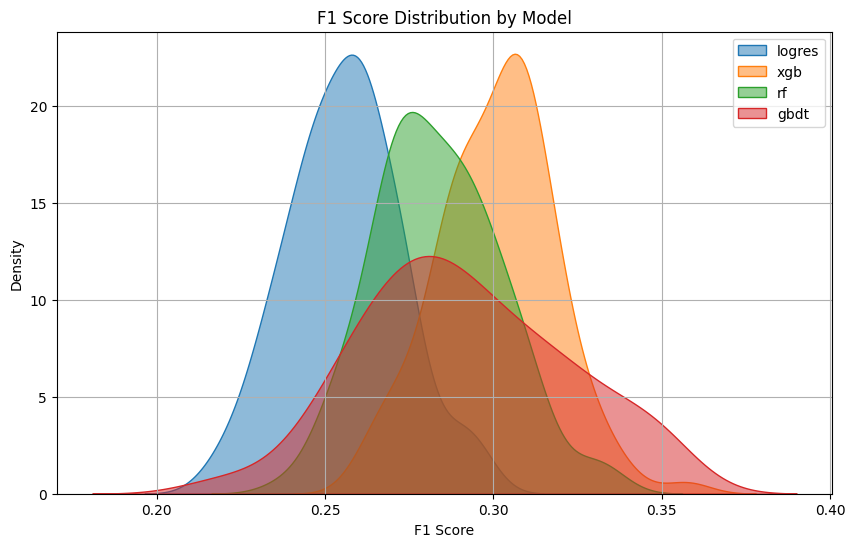

In [ ]:
X = seasonal_splits['Winter']
X_test = split_season_by_year(X, 'Winter')['Winter 2024']
y_test = X_test['Disrupted']
feature_cols = topo_features + wthr_features + oper_features
winter = compare_models(X_test[feature_cols], y_test, feature_cols, 'Winter')

# Plotting the F1 scores for each model
def plot_f1_scores(f1_scores_by_model):
    """
    Plot F1 scores for different models.
    """
    plt.figure(figsize=(10, 6))
    for model, scores in f1_scores_by_model.items():
        sns.kdeplot(scores, label=model, fill=True, alpha=0.5)
    
    plt.title("F1 Score Distribution by Model")
    plt.xlabel("F1 Score")
    plt.ylabel("Density")
    plt.legend()
    plt.grid()
    plt.show()

plot_f1_scores(winter)

In [40]:
compare_models(X_comp, y, False)


Fold 1/6

Fold 2/6


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Fold 3/6


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Fold 4/6


...

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Fold 6/6


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Aggregated metrics for LogisticRegression:
Balanced Accuracy: 0.9649 ± 0.0140
F1 Score: 0.8686 ± 0.0572
AUC: 0.9874 ± 0.0079

Aggregated metrics for RandomForestClassifier:
Balanced Accuracy: 0.5482 ± 0.0170
F1 Score: 0.1776 ± 0.0567
AUC: 0.7973 ± 0.0271

Aggregated metrics for XGBClassifier:
Balanced Accuracy: 0.8056 ± 0.0156
F1 Score: 0.5378 ± 0.0586
AUC: 0.8984 ± 0.0141

Aggregated metrics for GradientBoostingClassifier:
Balanced Accuracy: 0.8365 ± 0.0452
F1 Score: 0.7247 ± 0.0736
AUC: 0.9576 ± 0.0118


[{'model': 'LogisticRegression',
  'balanced_acc_mean': 0.9648946947251797,
  'balanced_acc_std': 0.013963848988983231,
  'f1_mean': 0.8686047554740034,
  'f1_std': 0.057189621433476105,
  'auc_mean': 0.9874241111577601,
  'auc_std': 0.007949357851707552},
 {'model': 'RandomForestClassifier',
  'balanced_acc_mean': 0.5482229492995899,
  'balanced_acc_std': 0.017016414958122183,
  'f1_mean': 0.1776051531488364,
  'f1_std': 0.05667289661080579,
  'auc_mean': 0.7972743328332329,
  'auc_std': 0.027130449308109792},
 {'model': 'XGBClassifier',
  'balanced_acc_mean': 0.8056215539475954,
  'balanced_acc_std': 0.015586690228557654,
  'f1_mean': 0.5378498156328613,
  'f1_std': 0.05857437634319962,
  'auc_mean': 0.8983729466251967,
  'auc_std': 0.01407931985222448},
 {'model': 'GradientBoostingClassifier',
  'balanced_acc_mean': 0.8364996720604884,
  'balanced_acc_std': 0.04522254675178669,
  'f1_mean': 0.7247226550606868,
  'f1_std': 0.07356149198307796,
  'auc_mean': 0.9576039434887166,
  'auc

In [26]:
rows_1 = compare_models(X_topo, y, False)
rows_2 = compare_models(X_topo, y, True)
rows_3 = compare_models(X_wthr, y, False)
rows_4 = compare_models(X_oper, y, False)
rows_5 = compare_models(X_tnw, y, False)
rows_6 = compare_models(X_wno, y, False)
rows_7 = compare_models(X_tno, y, False)
rows_8 = compare_models(X_comp, y, False)

results_df = pd.DataFrame(rows_1)
results_df['model'] = results_df['model'].apply(lambda x: x + ' Topology features')
for row in rows_2:
    row['model'] = row['model'] + ' Topology features (SMOTE)'
results_df = pd.concat([results_df, pd.DataFrame(rows_2)], ignore_index=True)
for row in rows_3:
    row['model'] = row['model'] + ' Weather features'
results_df = pd.concat([results_df, pd.DataFrame(rows_3)], ignore_index=True)
for row in rows_4:
    row['model'] = row['model'] + ' Operational features'
results_df = pd.concat([results_df, pd.DataFrame(rows_4)], ignore_index=True)
for row in rows_5:
    row['model'] = row['model'] + ' Topology and Weather features'
results_df = pd.concat([results_df, pd.DataFrame(rows_5)], ignore_index=True)
for row in rows_6:
    row['model'] = row['model'] + ' Weather and Operational features'
results_df = pd.concat([results_df, pd.DataFrame(rows_6)], ignore_index=True)
for row in rows_7:
    row['model'] = row['model'] + ' Topology and Operational features'
results_df = pd.concat([results_df, pd.DataFrame(rows_7)], ignore_index=True)
for row in rows_8:
    row['model'] = row['model'] + ' All features'
results_df = pd.concat([results_df, pd.DataFrame(rows_8)], ignore_index=True)

# Generate LaTeX table manually (replace with actual values)
latex_table = """
\\begin{table}[ht]
\\centering
\\caption{Cross-Validation Performance Metrics (Mean $\\pm$ Standard Deviation)}
\\begin{tabular}{lccc}
\\hline
\\textbf{Model} & \\textbf{Balanced Accuracy} & \\textbf{F1 Score} & \\textbf{AUC} \\\\
\\hline
"""
for _, row in results_df.iterrows():
    latex_table += f"{row['model']} & {row['balanced_acc_mean']:.3f} $\\pm$ {row['balanced_acc_std']:.3f} & {row['f1_mean']:.3f} $\\pm$ {row['f1_std']:.3f} & {row['auc_mean']:.3f} $\\pm$ {row['auc_std']:.3f} \\\\\n"
latex_table += """
\\hline
\\end{tabular}
\\end{table}
"""
print(latex_table)


Fold 1/6

Fold 2/6

Fold 3/6

Fold 4/6

Fold 5/6

Fold 6/6

Aggregated metrics for LogisticRegression:
Balanced Accuracy: 0.6763 ± 0.0275
F1 Score: 0.3823 ± 0.0368
AUC: 0.7392 ± 0.0384

Aggregated metrics for RandomForestClassifier:
Balanced Accuracy: 0.5851 ± 0.0211
F1 Score: 0.2857 ± 0.0371
AUC: 0.7524 ± 0.0347

Aggregated metrics for XGBClassifier:
Balanced Accuracy: 0.7025 ± 0.0347
F1 Score: 0.4028 ± 0.0290
AUC: 0.7724 ± 0.0429

Aggregated metrics for GradientBoostingClassifier:
Balanced Accuracy: 0.5765 ± 0.0171
F1 Score: 0.2662 ± 0.0425
AUC: 0.7809 ± 0.0406

Fold 1/6

Fold 2/6

Fold 3/6

Fold 4/6

Fold 5/6

Fold 6/6

Aggregated metrics for LogisticRegression:
Balanced Accuracy: 0.6759 ± 0.0281
F1 Score: 0.3815 ± 0.0367
AUC: 0.7394 ± 0.0388

Aggregated metrics for RandomForestClassifier:
Balanced Accuracy: 0.6314 ± 0.0262
F1 Score: 0.3640 ± 0.0335
AUC: 0.7598 ± 0.0291

Aggregated metrics for XGBClassifier:
Balanced Accuracy: 0.6470 ± 0.0288
F1 Score: 0.3827 ± 0.0346
AUC: 0.7616 ±

In [27]:
results_df

,model,balanced_acc_mean,balanced_acc_std,f1_mean,f1_std,auc_mean,auc_std
0,LogisticRegression Topology features,0.676297,0.027527,0.382273,0.036831,0.739245,0.038359
1,RandomForestClassifier Topology features,0.585073,0.021087,0.285672,0.037121,0.752357,0.034657
2,XGBClassifier Topology features,0.702516,0.034667,0.402827,0.029012,0.772379,0.042875
3,GradientBoostingClassifier Topology features,0.576537,0.017104,0.266228,0.042451,0.780854,0.040597
4,LogisticRegression Topology features (SMOTE),0.675864,0.028067,0.381516,0.036677,0.739407,0.038807
5,RandomForestClassifier Topology features (SMOTE),0.631450,0.026177,0.363955,0.033508,0.759829,0.029103
6,XGBClassifier Topology features (SMOTE),0.647024,0.028805,0.382723,0.034632,0.761601,0.042224
7,GradientBoostingClassifier Topology features (...,0.635234,0.025198,0.373679,0.037198,0.770516,0.041037
8,LogisticRegression Weather features,0.510858,0.006982,0.222357,0.032734,0.512400,0.013800
9,RandomForestClassifier Weather features,0.501237,0.003698,0.059059,0.016940,0.499100,0.006595


In [134]:
from sklearn.inspection import permutation_importance
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from bayes_opt import BayesianOptimization

def build_lstm_model(input_shape, lstm1, lstm2, dense, learning_rate):
    model = Sequential([
        LSTM(int(lstm1), activation='relu', return_sequences=True, input_shape=input_shape),
        LSTM(int(lstm2), activation='relu'),
        Dropout(0.3),
        Dense(int(dense), activation='relu'),
        Dense(2, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def optimise_lstm_bayesian(seasonal_data, season, init_points=5, n_iter=10, epochs=50, batch_size=32):
    seasonal_years = split_season_by_year(seasonal_data, season)
    years = sorted(seasonal_years.keys())
    
    # Split train/test
    train_df = pd.concat([seasonal_years[year] for year in years[:-1]])
    test_df = seasonal_years[years[-1]]
    
    X_train = train_df[feature_cols]
    y_train = train_df["Disrupted"].values
    X_test = test_df[feature_cols]
    y_test = test_df["Disrupted"].values
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train).reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_test_scaled = scaler.transform(X_test).reshape((X_test.shape[0], 1, X_test.shape[1]))
    
    y_train_cat = to_categorical(y_train)
    y_test_cat = to_categorical(y_test)
    
    # Determine input shape
    num_features = X_train.shape[1]
    input_shape = (1, num_features)  # 1 timestep, N features

    # Objective function for Bayesian Optimization
    def train_eval(lstm1, lstm2, dense, learning_rate):
        model = build_lstm_model(input_shape, lstm1, lstm2, dense, learning_rate)
        es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        model.fit(X_train_scaled, y_train_cat, epochs=epochs, batch_size=batch_size,
                  validation_split=0.2, callbacks=[es], verbose=0)
        y_pred = model.predict(X_test_scaled)
        return f1_score(y_test, np.argmax(y_pred, axis=1))
    
    pbounds = {
        'lstm1': (32, 256),
        'lstm2': (16, 128),
        'dense': (16, 128),
        'learning_rate': (1e-4, 1e-2)
    }
    
    optimizer = BayesianOptimization(f=train_eval, pbounds=pbounds, random_state=42)
    optimizer.maximize(init_points=init_points, n_iter=n_iter)
    
    # Train best model
    best_params = optimizer.max['params']
    final_model = build_lstm_model(input_shape, **best_params)
    final_model.fit(X_train_scaled, y_train_cat, epochs=epochs, batch_size=batch_size,
                    validation_split=0.2, verbose=0)
    
    y_pred_final = final_model.predict(X_test_scaled)
    y_pred_classes = np.argmax(y_pred_final, axis=1)

    # Report
    print("\nBest Hyperparameters:", best_params)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_classes))

    cm = confusion_matrix(y_test, y_pred_classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    plt.title(f'Confusion Matrix - {season} 2024')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    metrics = {
        'f1': f1_score(y_test, y_pred_classes),
        'balanced_acc': balanced_accuracy_score(y_test, y_pred_classes),
        'auc': roc_auc_score(y_test, y_pred_final[:, 1])
    }
    
    return final_model, best_params, metrics

|   iter    |  target   |   dense   | learni... |   lstm1   |   lstm2   |
-------------------------------------------------------------------------


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
| 1         | 0.3438    | 57.95     | 0.009512  | 196.0     | 83.05     |


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
| 2         | 0.3087    | 33.47     | 0.001644  | 45.01     | 113.0     |


...

90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
| 39        | 0.3373    | 96.22     | 0.0006195 | 138.3     | 35.69     |


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
| 40        | 0.3353    | 116.8     | 0.00218   | 135.3     | 32.1      |


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Best Hyperparameters: {'dense': 102.82065324578976, 'learning_rate': 0.008833076278148428, 'lstm1': 82.88560732666426, 'lstm2': 57.711566867382786}

Classification Report:
              precision    recall  f1-score   support

       False       0.94      0.94      0.94      2651
        True       0.22      0.20      0.21       210

    accuracy                           0.89      2861
   macro avg       0.58      0.57      0.57      2861
weighted avg       0.88      0.89      0.89      2861



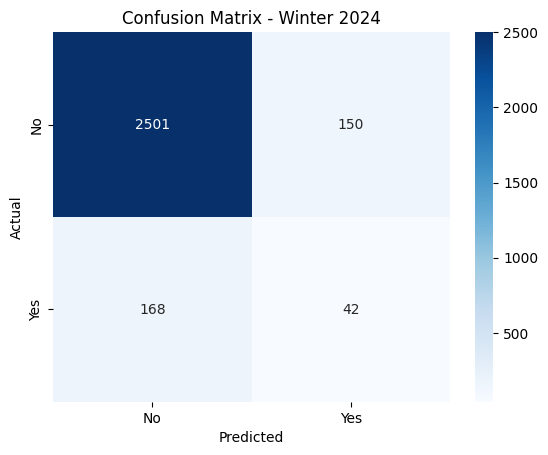

In [216]:
X_winter = seasonal_splits['Winter']
lstm_model_winter, lstm_params_winter, lstm_metrics_winter = optimise_lstm_bayesian(X_winter, 'Winter', init_points=10, n_iter=30, epochs=50, batch_size=32)

|   iter    |  target   |   dense   | learni... |   lstm1   |   lstm2   |
-------------------------------------------------------------------------


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
| 1         | 0.3171    | 57.95     | 0.009512  | 196.0     | 83.05     |


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
| 2         | 0.2805    | 33.47     | 0.001644  | 45.01     | 113.0     |


...

608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
| 14        | 0.2684    | 17.85     | 0.001929  | 162.9     | 99.18     |


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
| 15        | 0.2552    | 55.94     | 0.006711  | 199.7     | 82.92     |


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Best Hyperparameters: {'dense': 21.08959279064638, 'learning_rate': 0.00016636688124794415, 'lstm1': 163.49601771036598, 'lstm2': 96.33588321692561}

Classification Report:
              precision    recall  f1-score   support

       False       0.92      0.92      0.92     17463
        True       0.26      0.25      0.26      1984

    accuracy                           0.85     19447
   macro avg       0.59      0.59      0.59     19447
weighted avg       0.85      0.85      0.85     19447



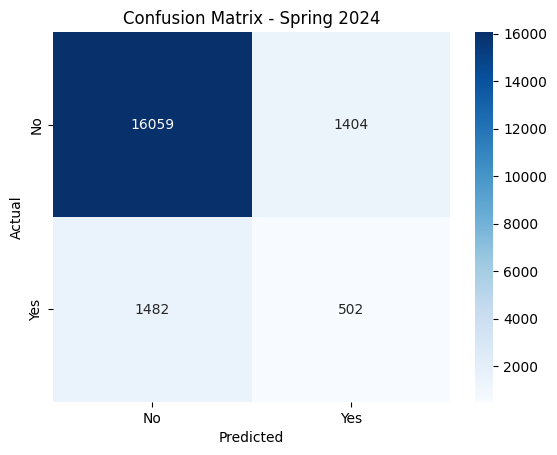

In [140]:
X_spring = seasonal_splits['Spring']
lstm_model_spring, lstm_params_spring, lstm_metrics_spring = optimise_lstm_bayesian(X_spring, 'Spring', init_points=5, n_iter=10, epochs=50, batch_size=32)

|   iter    |  target   |   dense   | learni... |   lstm1   |   lstm2   |
-------------------------------------------------------------------------


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
| 1         | 0.3045    | 57.95     | 0.009512  | 196.0     | 83.05     |


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
| 2         | 0.2088    | 33.47     | 0.001644  | 45.01     | 113.0     |


...

597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
| 14        | 0.3089    | 16.71     | 0.004647  | 250.8     | 75.0      |


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
| 15        | 0.2959    | 99.17     | 0.005298  | 99.28     | 18.2      |


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Best Hyperparameters: {'dense': 109.23357576964723, 'learning_rate': 0.002202157195714934, 'lstm1': 72.72879265439053, 'lstm2': 36.54130510358459}

Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.93      0.92     16903
        True       0.33      0.26      0.29      2188

    accuracy                           0.86     19091
   macro avg       0.62      0.60      0.61     19091
weighted avg       0.84      0.86      0.85     19091



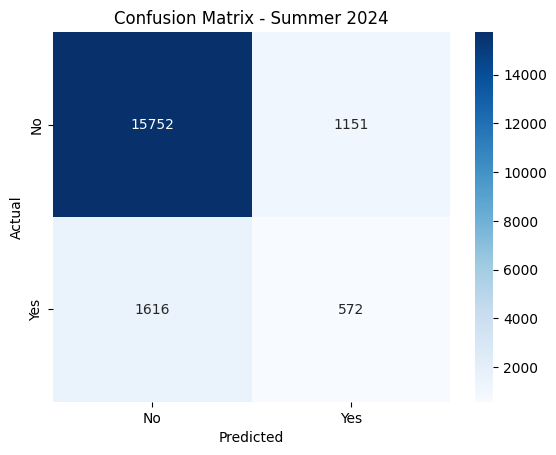

|   iter    |  target   |   dense   | learni... |   lstm1   |   lstm2   |
-------------------------------------------------------------------------


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
| 1         | 0.2626    | 57.95     | 0.009512  | 196.0     | 83.05     |


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
| 2         | 0.2537    | 33.47     | 0.001644  | 45.01     | 113.0     |


...

598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
| 14        | 0.2903    | 86.26     | 0.008668  | 32.3      | 122.7     |


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
| 15        | 0.2867    | 111.4     | 0.003844  | 51.65     | 127.6     |


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Best Hyperparameters: {'dense': 91.9384422284659, 'learning_rate': 0.005178486317277371, 'lstm1': 34.940454736572086, 'lstm2': 125.50363146708685}

Classification Report:
              precision    recall  f1-score   support

       False       0.90      0.97      0.93     16959
        True       0.39      0.14      0.20      2165

    accuracy                           0.88     19124
   macro avg       0.64      0.55      0.57     19124
weighted avg       0.84      0.88      0.85     19124



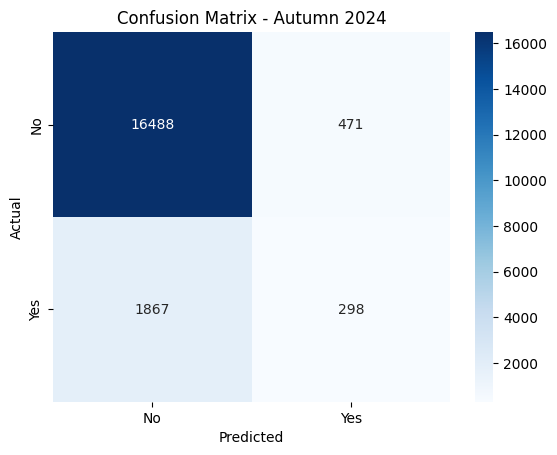

In [142]:
X_summer = seasonal_splits['Summer']
lstm_model_summer, lstm_params_summer, lstm_metrics_summer = optimise_lstm_bayesian(X_summer, 'Summer', init_points=5, n_iter=10, epochs=50, batch_size=32)
X_autumn = seasonal_splits['Autumn']
lstm_model_autumn, lstm_params_autumn, lstm_metrics_autumn = optimise_lstm_bayesian(X_autumn, 'Autumn', init_points=5, n_iter=10, epochs=50, batch_size=32)

In [ ]:
lstm_models = {
    'Winter': lstm_model_winter,
    'Spring': lstm_model_spring,
    'Summer': lstm_model_summer,
    'Autumn': lstm_model_autumn
}

feature_selection_lstm = {}
for season in seasons:
    X = seasonal_splits[season]
    test_data = split_season_by_year(X, season)
    test_data = test_data[f'{season} 2024']
    feature_cols = topo_features + wthr_features + oper_features 
    selected_features_df = shap_select(
    lstm_models[season],
    test_data[feature_cols],
    test_data['Disrupted'].astype(int),
    feature_names=feature_cols,
    task="binary",
    threshold=0.05
)
    print(f"Selected features for {season}:")
    print(selected_features_df)
    selected_features_df = selected_features_df[selected_features_df['selected'] == 1]
    sel_feat_list = selected_features_df['feature name'].tolist()
    feature_selection_lstm[season] = sel_feat_list
    print(sel_feat_list)

ValueError: masker cannot be None.

In [141]:
print(lstm_metrics)
print(lstm_metrics_spring)

{'f1': 0.29333333333333333, 'balanced_acc': 0.610205492985576, 'auc': 0.7672594348942896}
{'f1': 0.2580976863753213, 'balanced_acc': 0.5863128182997046, 'auc': 0.7676669612988197}


Initial 2024 Evaluation
              precision    recall  f1-score   support

       False       0.94      0.95      0.94      2651
        True       0.24      0.19      0.21       210

    accuracy                           0.90      2861
   macro avg       0.59      0.57      0.58      2861
weighted avg       0.89      0.90      0.89      2861



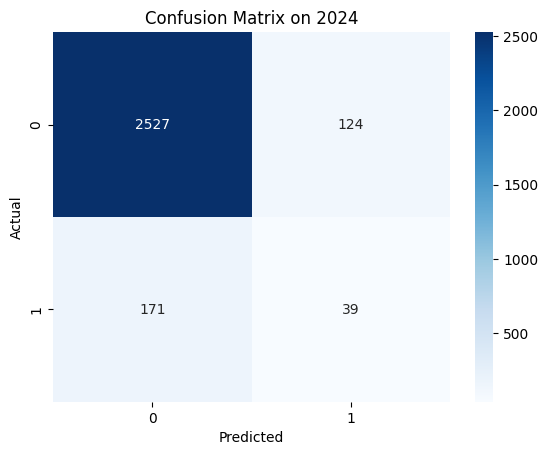

Bootstrapping F1 Scores for 2024 Data (100 iterations)...
Mean F1: 0.8903 ± 0.0061


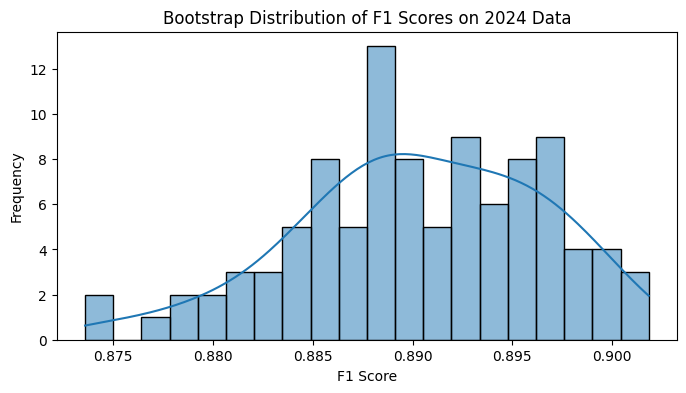

Computing permutation importance on 2024 test set...


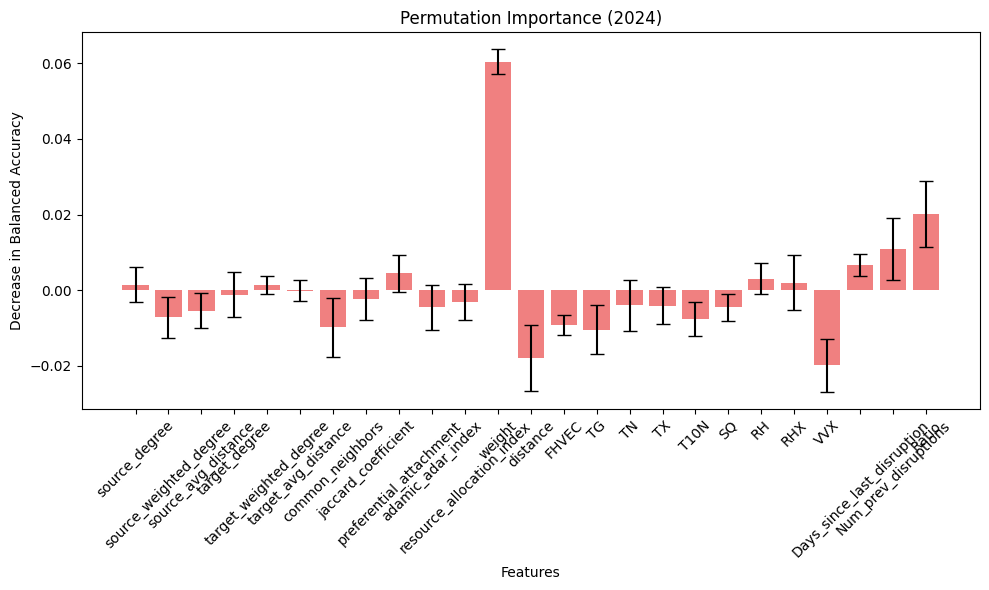

In [218]:
import copy

def permutation_importance(model, X_test, y_test, metric, feature_names, n_repeats=5):
    """
    Compute permutation importance for an LSTM model.
    
    Parameters:
    - model: Trained Keras LSTM model
    - X_test: Test data, shape [samples, timesteps, n_features]
    - y_test: Test labels (categorical, shape [samples, n_classes])
    - metric: Metric function (e.g., balanced_accuracy_score)
    - feature_names: List of feature names
    - n_repeats: Number of times to shuffle each feature
    
    Returns:
    - mean_importance: Mean importance scores for each feature
    - std_importance: Standard deviation of importance scores
    """
    # Baseline performance
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = y_test
    baseline_score = metric(y_true, y_pred)
    
    # Initialize importance scores
    n_features = X_test.shape[-1]
    importances = np.zeros((n_features, n_repeats))
    
    # Permute each feature
    for feature_idx in range(n_features):
        for repeat in range(n_repeats):
            X_permuted = copy.deepcopy(X_test)
            # Shuffle the feature across samples
            permuted_indices = np.random.permutation(X_test.shape[0])
            X_permuted[:, :, feature_idx] = X_permuted[permuted_indices, :, feature_idx]
            # Evaluate model
            y_pred_proba_permuted = model.predict(X_permuted, verbose=0)
            y_pred_permuted = np.argmax(y_pred_proba_permuted, axis=1)
            permuted_score = metric(y_true, y_pred_permuted)
            # Importance = decrease in metric (since higher is better)
            importances[feature_idx, repeat] = baseline_score - permuted_score
    
    # Average importance and standard deviation
    mean_importance = np.mean(importances, axis=1)
    std_importance = np.std(importances, axis=1)
    return mean_importance, std_importance

def lstm_bootstrap_predict(X_test, y_test, model, feature_names=None, n_iterations=100):
    # Standardize
    scaler = StandardScaler()
    X_test_scaled = scaler.fit_transform(X_test).reshape((X_test.shape[0], 1, X_test.shape[1]))

    # y_test should already be integer labels like 0 or 1
    y_true = y_test

    # Evaluate once on actual 2024 data
    y_pred_proba = model.predict(X_test_scaled, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)  # Convert probabilities to categorical labels

    print("Initial 2024 Evaluation")
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix on 2024")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Bootstrapping
    print(f"Bootstrapping F1 Scores for 2024 Data ({n_iterations} iterations)...")
    scores = bootstrap_f1_scores(model, X_test_scaled, y_true, n_iterations=n_iterations)

    print(f"Mean F1: {scores.mean():.4f} ± {scores.std():.4f}")

    # Plot distribution
    plt.figure(figsize=(8, 4))
    sns.histplot(scores, bins=20, kde=True)
    plt.title("Bootstrap Distribution of F1 Scores on 2024 Data")
    plt.xlabel("F1 Score")
    plt.ylabel("Frequency")
    plt.show()

    # Permutation importance
    print("Computing permutation importance on 2024 test set...")
    mean_importance, std_importance = permutation_importance(
        model, X_test_scaled, y_true, balanced_accuracy_score, feature_names
    )

    # Plot importance
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(feature_names)), mean_importance, yerr=std_importance, capsize=5, color='lightcoral')
    plt.xticks(range(len(feature_names)), feature_names, rotation=45)
    plt.title('Permutation Importance (2024)')
    plt.xlabel('Features')
    plt.ylabel('Decrease in Balanced Accuracy')
    plt.tight_layout()
    plt.show()
    n_features = len(feature_names)
    mean_importance = {feature_names[i]: mean_importance[i] for i in range(n_features)}
    std_importance = {feature_names[i]: mean_importance for i in range(n_features)}
    return {
        'f1_scores': scores,
        'mean_importance': mean_importance,
        'std_importance': std_importance
    }

X = seasonal_splits['Winter']
X_test_winter = split_season_by_year(X, 'Winter')['Winter 2024']
y_test_winter = X_test_winter['Disrupted']

lstm_winter_scores = lstm_bootstrap_predict(X_test_winter[feature_cols], y_test_winter, lstm_model_winter, feature_names=feature_cols, n_iterations=100)

Initial 2024 Evaluation
              precision    recall  f1-score   support

       False       0.92      0.93      0.92     17463
        True       0.30      0.24      0.27      1984

    accuracy                           0.86     19447
   macro avg       0.61      0.59      0.60     19447
weighted avg       0.85      0.86      0.86     19447



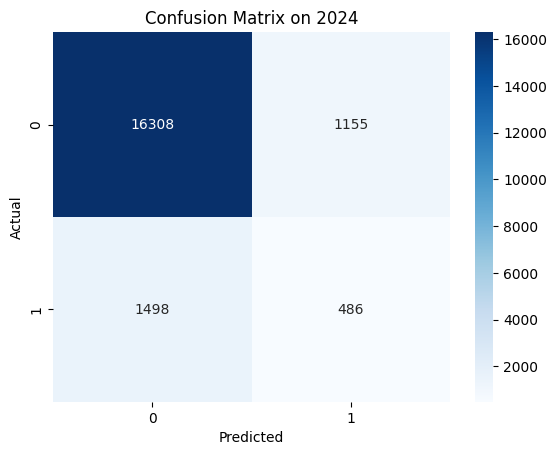

Bootstrapping F1 Scores for 2024 Data (100 iterations)...
Mean F1: 0.8578 ± 0.0024


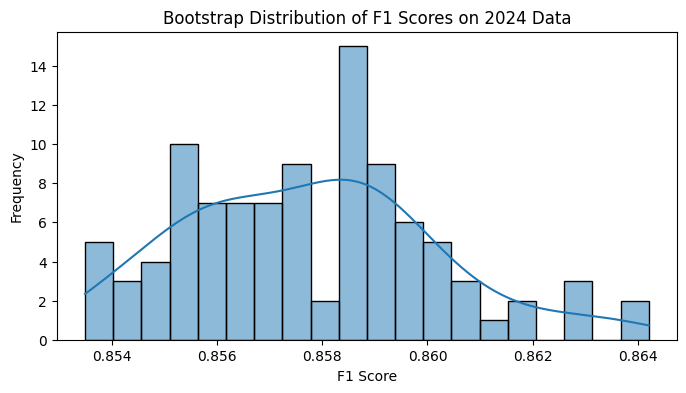

Computing permutation importance on 2024 test set...


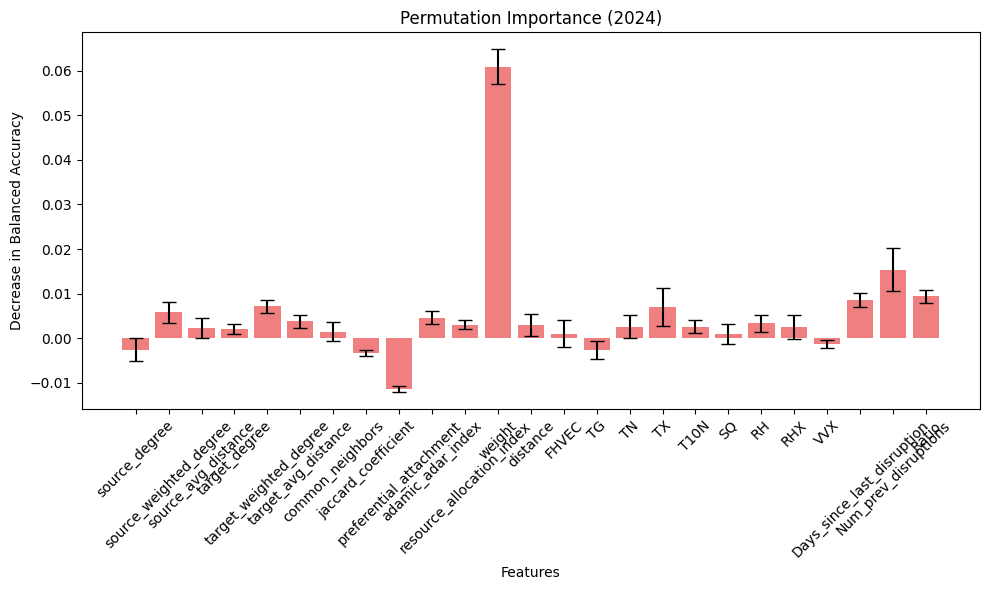

In [198]:
X_spring = seasonal_splits['Spring']
X_test_spring = split_season_by_year(X_spring, 'Spring')['Spring 2024']
y_test_spring = X_test_spring['Disrupted']
lstm_spring_scores = lstm_bootstrap_predict(X_test_spring[feature_cols], y_test_spring, lstm_model_spring, feature_names=feature_cols, n_iterations=100)

Initial 2024 Evaluation
              precision    recall  f1-score   support

       False       0.90      0.96      0.93     16903
        True       0.36      0.17      0.23      2188

    accuracy                           0.87     19091
   macro avg       0.63      0.57      0.58     19091
weighted avg       0.84      0.87      0.85     19091



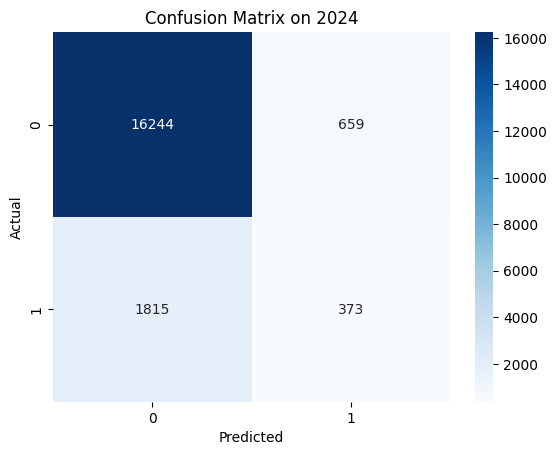

Bootstrapping F1 Scores for 2024 Data (100 iterations)...
Mean F1: 0.8490 ± 0.0030


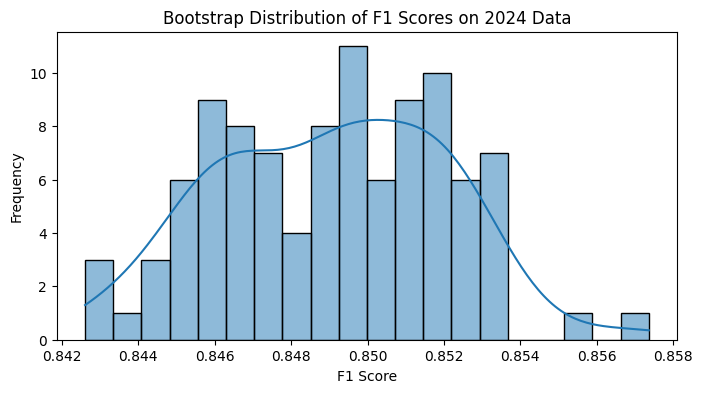

Computing permutation importance on 2024 test set...


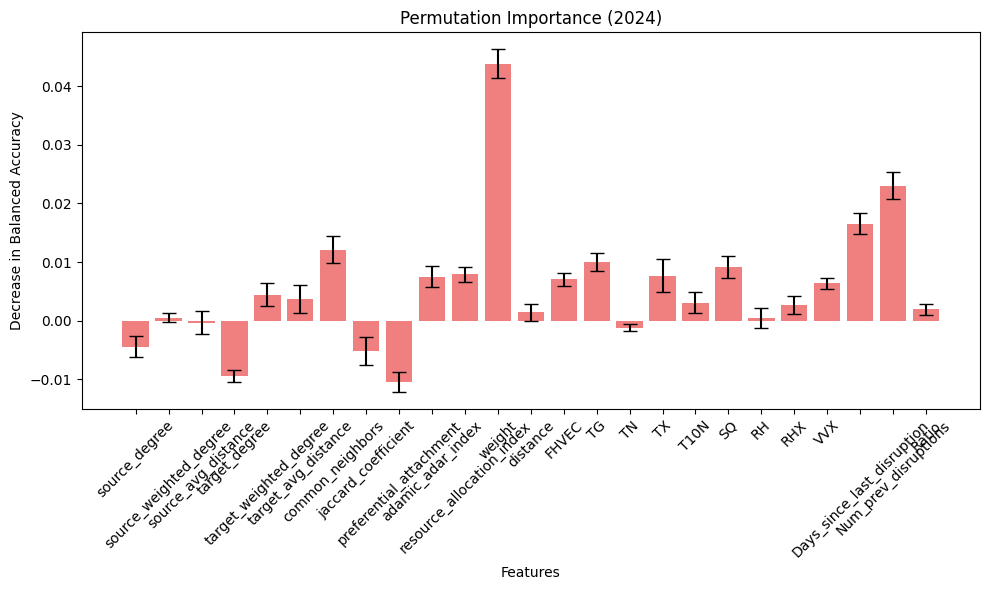

In [199]:
X_summer = seasonal_splits['Summer']
X_test_summer = split_season_by_year(X_summer, 'Summer')['Summer 2024'] 
y_test_summer = X_test_summer['Disrupted']
lstm_summer_scores = lstm_bootstrap_predict(X_test_summer[feature_cols], y_test_summer, lstm_model_summer, feature_names=feature_cols, n_iterations=100)

Initial 2024 Evaluation
              precision    recall  f1-score   support

       False       0.90      0.97      0.94     16959
        True       0.44      0.17      0.25      2165

    accuracy                           0.88     19124
   macro avg       0.67      0.57      0.59     19124
weighted avg       0.85      0.88      0.86     19124



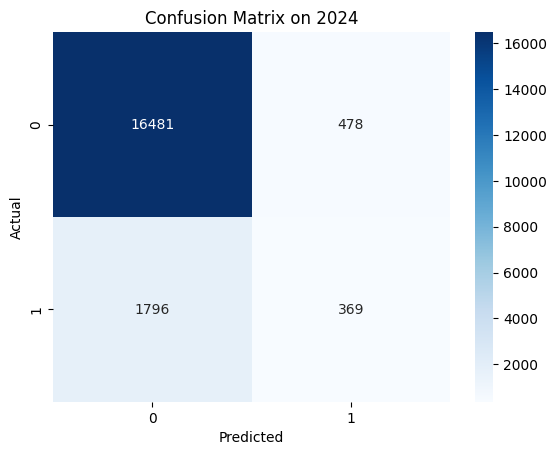

Bootstrapping F1 Scores for 2024 Data (100 iterations)...
Mean F1: 0.8578 ± 0.0032


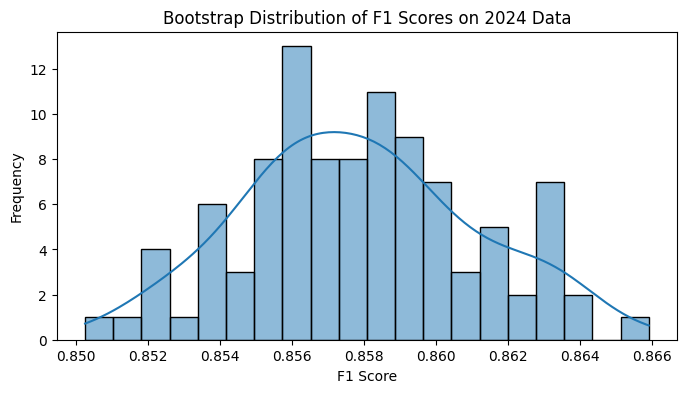

Computing permutation importance on 2024 test set...


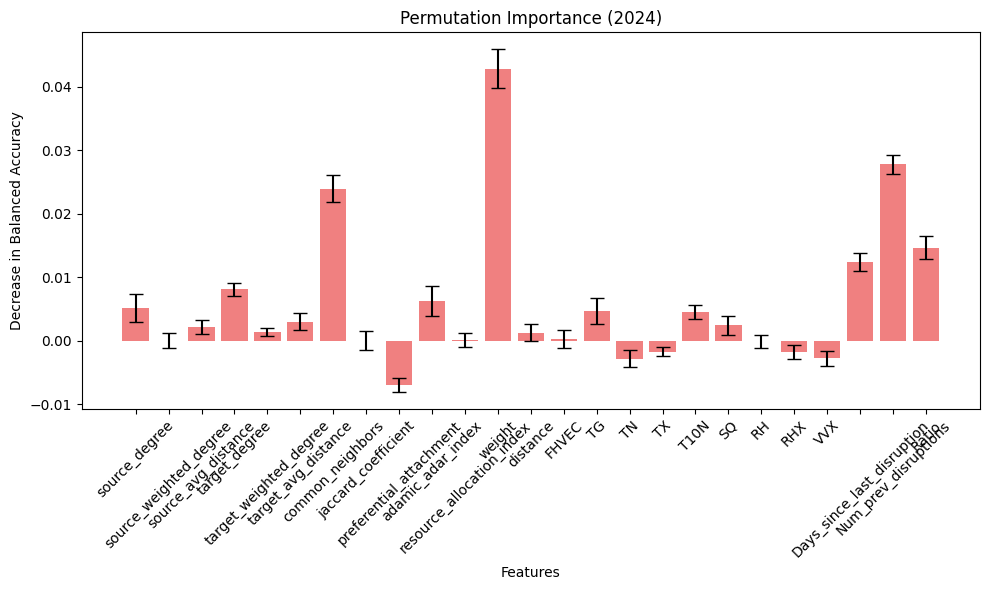

In [219]:
X_autumn = seasonal_splits['Autumn']
X_test_autumn = split_season_by_year(X_autumn, 'Autumn')['Autumn 2024']
y_test_autumn = X_test_autumn['Disrupted']
lstm_autumn_scores = lstm_bootstrap_predict(X_test_autumn[feature_cols], y_test_autumn, lstm_model_autumn, feature_names=feature_cols, n_iterations=100)
# Combine all LSTM scores into a single DataFrame
lstm_scores = {
    'Winter': lstm_winter_scores,
    'Spring': lstm_spring_scores,
    'Summer': lstm_summer_scores,
    'Autumn': lstm_autumn_scores
}

In [220]:
lstm_features = {}
for season in seasons:
    lstm_scores[season]['mean_importance'] = pd.Series(lstm_scores[season]['mean_importance']).sort_values(ascending=False)
    top_features = lstm_scores[season]['mean_importance'][lstm_scores[season]['mean_importance'] > 0.005].index.tolist()
    lstm_features[season] = top_features[:10]
    print(f"Top features for {season}: {top_features[:10]}")

Top features for Winter: ['weight', 'Ratio', 'Num_prev_disruptions', 'Days_since_last_disruption']
Top features for Spring: ['weight', 'Num_prev_disruptions', 'Ratio', 'Days_since_last_disruption', 'target_weighted_degree', 'TX', 'source_weighted_degree']
Top features for Summer: ['weight', 'Num_prev_disruptions', 'Days_since_last_disruption', 'common_neighbors', 'TG', 'SQ', 'resource_allocation_index', 'TX', 'adamic_adar_index', 'FHVEC']
Top features for Autumn: ['weight', 'Num_prev_disruptions', 'common_neighbors', 'Ratio', 'Days_since_last_disruption', 'target_degree', 'adamic_adar_index', 'source_degree']


In [223]:
lstm_parameters = {
    'Winter': lstm_params_winter,
    'Spring': lstm_params_spring,
    'Summer': lstm_params_summer,
    'Autumn': lstm_params_autumn
}
print(lstm_parameters['Winter'])

{'dense': 102.82065324578976, 'learning_rate': 0.008833076278148428, 'lstm1': 82.88560732666426, 'lstm2': 57.711566867382786}


In [227]:
lstm_models_trained = {}

for season in seasons:
    # Get the seasonal data
    X = seasonal_splits[season]
    test_data = split_season_by_year(X, season)
    train_data = pd.concat([test_data[year] for year in test_data if year != f'{season} 2024'])
    test_data = test_data[f'{season} 2024']
    
    # Extract selected features
    selected_features = lstm_features[season]
    
    # Prepare training and testing data
    X_train = train_data[selected_features]
    y_train = train_data['Disrupted']
    X_test = test_data[selected_features]
    y_test = test_data['Disrupted']
    
    # One-hot encode the target variable
    y_train_encoded = to_categorical(y_train.astype(int))
    y_test_encoded = to_categorical(y_test.astype(int))
    
    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train).reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_test_scaled = scaler.transform(X_test).reshape((X_test.shape[0], 1, X_test.shape[1]))
    
    # Build and train the LSTM model
    lstm_params_season = lstm_parameters[season]
    model = build_lstm_model(
        input_shape=(1, len(selected_features)),
        lstm1=lstm_params_season['lstm1'],
        lstm2=lstm_params_season['lstm2'],
        dense=lstm_params_season['dense'],
        learning_rate=lstm_params_season['learning_rate']
    )
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    model.fit(
        X_train_scaled, y_train_encoded,
        epochs=50, batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=0
    )
    
    # Store the trained model
    lstm_models_trained[season] = model
    
    # Evaluate the model
    y_pred = model.predict(X_test_scaled)
    y_pred_classes = np.argmax(y_pred, axis=1)
    print(f"Season: {season}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred_classes))
    print(f"Accuracy: {accuracy_score(y_test, y_pred_classes):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred_classes):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred_classes):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred_classes):.4f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_classes):.4f}")
    print(f"AUC: {roc_auc_score(y_test, y_pred[:, 1]):.4f}")

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Season: Winter
Classification Report:
              precision    recall  f1-score   support

       False       0.94      0.99      0.96      2651
        True       0.57      0.24      0.34       210

    accuracy                           0.93      2861
   macro avg       0.75      0.61      0.65      2861
weighted avg       0.92      0.93      0.92      2861

Accuracy: 0.9308
F1 Score: 0.3400
Precision: 0.5667
Recall: 0.2429
Balanced Accuracy: 0.6141
AUC: 0.8317


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


608/608 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Season: Spring
Classification Report:
              precision    recall  f1-score   support

       False       0.92      0.96      0.94     17463
        True       0.42      0.26      0.32      1984

    accuracy                           0.89     19447
   macro avg       0.67      0.61      0.63     19447
weighted avg       0.87      0.89      0.88     19447

Accuracy: 0.8878
F1 Score: 0.3182
Precision: 0.4189
Recall: 0.2566
Balanced Accuracy: 0.6081
AUC: 0.8136


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Season: Summer
Classification Report:
              precision    recall  f1-score   support

       False       0.90      0.98      0.94     16903
        True       0.50      0.14      0.22      2188

    accuracy                           0.89     19091
   macro avg       0.70      0.56      0.58     19091
weighted avg       0.85      0.89      0.86     19091

Accuracy: 0.8851
F1 Score: 0.2243
Precision: 0.4961
Recall: 0.1449
Balanced Accuracy: 0.5629
AUC: 0.7760


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Season: Autumn
Classification Report:
              precision    recall  f1-score   support

       False       0.90      0.98      0.94     16959
        True       0.51      0.16      0.24      2165

    accuracy                           0.89     19124
   macro avg       0.70      0.57      0.59     19124
weighted avg       0.86      0.89      0.86     19124

Accuracy: 0.8873
F1 Score: 0.2430
Precision: 0.5066
Recall: 0.1598
Balanced Accuracy: 0.5700
AUC: 0.8056


In [ ]:
def plot_f1_scores(f1_scores_by_model):
    plt.figure(figsize=(10, 6))
    for model, scores in f1_scores_by_model.items():
        sns.kdeplot(scores, label=model, fill=True, alpha=0.5)
    plt.title("F1 Score Distribution by Model")
    plt.xlabel("F1 Score")
    plt.ylabel("Density")
    plt.legend()
    plt.grid()
    plt.show()

90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
90/90 ━━━━━━━━━━━━━━━━━━━

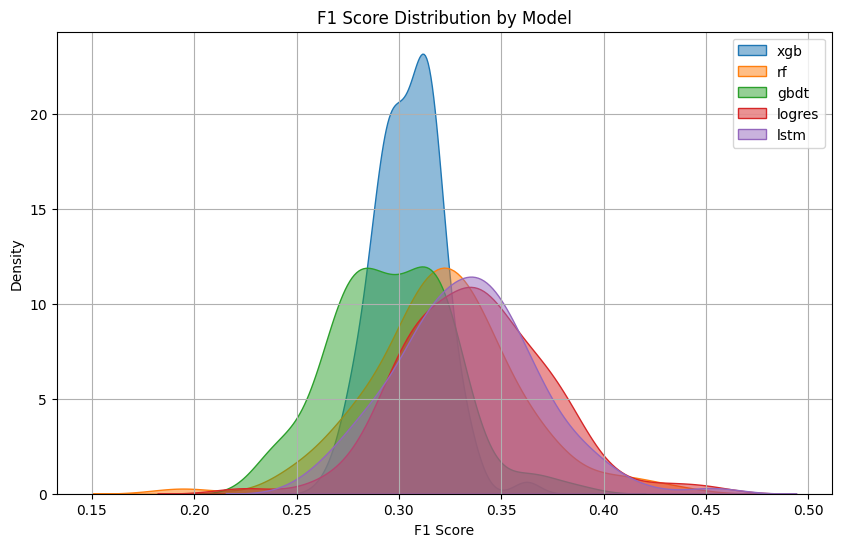

608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
608/608 ━━━━━━━━

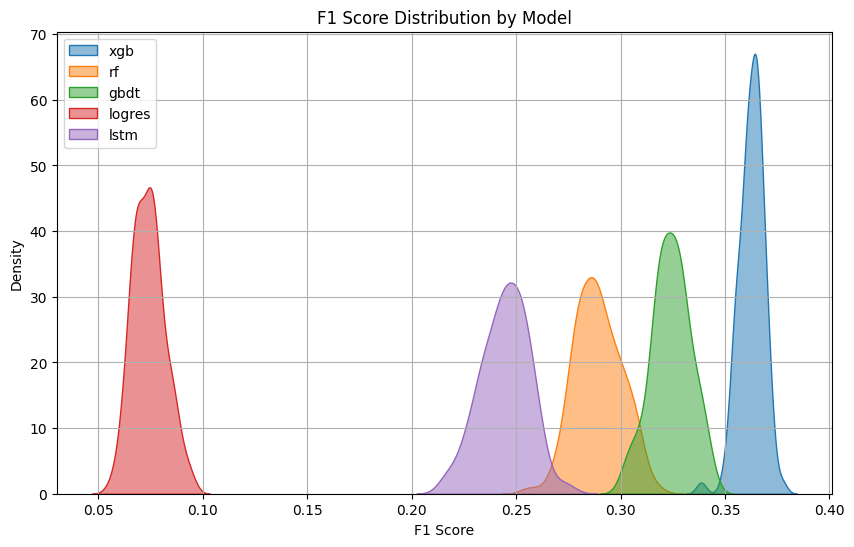

597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
597/597 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
597/597 ━━━━━━━━

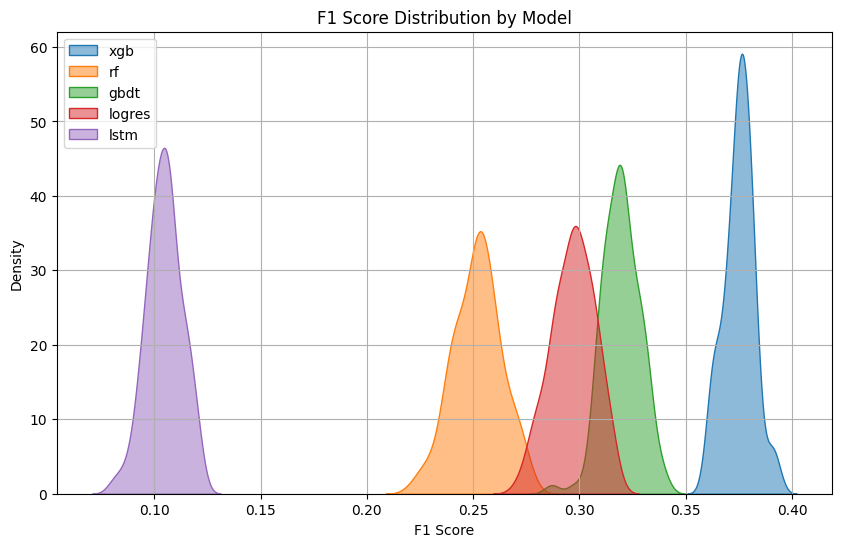

598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
598/598 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
598/598 ━━━━━━━━

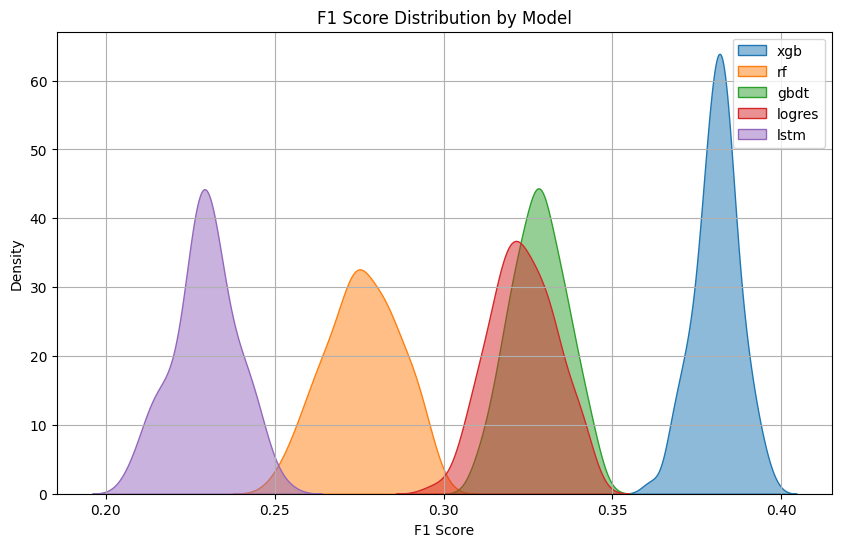

In [242]:
def bootstrap_metrics_scores(model, X, y, is_lstm=False, n_bootstraps=100, seed=42):
    rng = np.random.RandomState(seed)
    scores = {
        'f1': [], 'precision': [], 'recall': [], 'balanced_acc': [], 'auc': []
    }
    
    for _ in range(n_bootstraps):
        indices = rng.choice(len(X), len(X), replace=True)
        X_sample = X.iloc[indices]
        y_sample = y.iloc[indices].astype(int)

        if is_lstm:
            scaler = StandardScaler()
            X_sample_reset = X_sample.reset_index(drop=True)  # Ensure alignment
            y_sample = y_sample.reset_index(drop=True)        # Align labels
    
            X_scaled = scaler.fit_transform(X_sample_reset)
            X_np = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))
    
            y_pred = model.predict(X_np)
            y_pred_prob = np.argmax(y_pred, axis=1)
        else:
            y_pred_prob = model.predict_proba(X_sample)[:, 1] if hasattr(model, "predict_proba") else model.predict(X_sample)

        y_pred = (y_pred_prob >= 0.5).astype(int)

        scores['f1'].append(f1_score(y_sample, y_pred))
        scores['precision'].append(precision_score(y_sample, y_pred))
        scores['recall'].append(recall_score(y_sample, y_pred))
        scores['balanced_acc'].append(balanced_accuracy_score(y_sample, y_pred))
        try:
            scores['auc'].append(roc_auc_score(y_sample, y_pred_prob))
        except:
            scores['auc'].append(np.nan)

    return scores

def get_confidence_interval(data, ci=95):
    lower = np.percentile(data, (100 - ci) / 2)
    upper = np.percentile(data, 100 - (100 - ci) / 2)
    return lower, upper

def compare_models(models, X_test_dict, y_test, season):
    """
    Compare different models using paired t-tests on bootstrapped F1 scores.
    Also returns confidence intervals for all metrics.
    """
    all_metrics = {}
    
    for name, model in models.items():
        is_lstm = (name == 'lstm')
        scores = bootstrap_metrics_scores(model, X_test_dict[name], y_test, is_lstm=is_lstm)
        all_metrics[name] = scores

    model_names = list(all_metrics.keys())
    
    print(f"\n--- Paired t-tests on F1 for {season} ---")
    for i in range(len(model_names)):
        for j in range(i + 1, len(model_names)):
            m1, m2 = model_names[i], model_names[j]
            t_stat, p_val = ttest_rel(all_metrics[m1]['f1'], all_metrics[m2]['f1'])
            print(f"{m1} vs {m2}: t = {t_stat:.3f}, p = {p_val:.4f}")
    
    # Print confidence intervals
    print(f"\n--- Bootstrap Confidence Intervals ({season}) ---")
    for name, scores in all_metrics.items():
        print(f"\n{name}:")
        for metric in scores:
            mean = np.mean(scores[metric])
            low, high = get_confidence_interval(scores[metric])
            print(f"{metric}: {mean:.3f} ({low:.3f}–{high:.3f})")

    return {k: v['f1'] for k, v in all_metrics.items()}  # Return only F1 scores for plotting

# Dictionary to store F1 scores for each season
season_f1_scores = {}

for season in seasons:
    # Get the seasonal data
    X = seasonal_splits[season]
    year_split = split_season_by_year(X, season)
    train_data = pd.concat([year_split[year] for year in year_split if year != f'{season} 2024'])
    test_data = year_split[f'{season} 2024']
    
    y_train = train_data['Disrupted'].astype(int)
    y_test = test_data['Disrupted'].astype(int)
    
    selected_features = {
        'xgb': feature_selection_xgb[season],
        'rf': rf_top_features[season],
        'gbdt': feature_selection_gb[season],
        'logres': lr_top_features[season],
        'lstm': lstm_features[season]  # you must define this if needed
    }

    models = {}
    X_test_dict = {}

    for model_name in ['xgb', 'rf', 'gbdt', 'logres']:
        X_train = train_data[selected_features[model_name]]
        X_test = test_data[selected_features[model_name]]
        
        if model_name == 'xgb':
            model = XGBClassifier(random_state=42, **xgb_params[season])
        elif model_name == 'rf':
            model = RandomForestClassifier(random_state=42, **rf_params[season])
        elif model_name == 'gbdt':
            model = GradientBoostingClassifier(random_state=42, **gb_params[season])
        elif model_name == 'logres':
            model = LogisticRegression(random_state=42, **lr_params[season])
        
        model.fit(X_train, y_train)
        models[model_name] = model
        X_test_dict[model_name] = X_test

    # Add LSTM
    lstm_model = lstm_models_trained[season]
    X_test_lstm = test_data[selected_features['lstm']]
    X_test_dict['lstm'] = X_test_lstm
    models['lstm'] = lstm_model

    # Compare models
    f1_scores = compare_models(models, X_test_dict, y_test, season)
    plot_f1_scores(f1_scores)
    season_f1_scores[season] = {k: np.mean(v) for k, v in f1_scores.items()}


Fold 1/6


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - AUC: 0.8897 - Precision: 0.8715 - Recall: 0.8715 - accuracy: 0.8715 - loss: 0.3868 - val_AUC: 0.9029 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3614
Epoch 2/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - AUC: 0.9031 - Precision: 0.8685 - Recall: 0.8685 - accuracy: 0.8685 - loss: 0.3696 - val_AUC: 0.9299 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3321
Epoch 3/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - AUC: 0.9228 - Precision: 0.8720 - Recall: 0.8720 - accuracy: 0.8720 - loss: 0.3445 - val_AUC: 0.9293 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3332
Epoch 4/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - AUC: 0.9256 - Precision: 0.8727 - Recall: 0.8727 - accuracy: 0.8727 - loss: 0.3399 - val_AUC: 0.9313 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3311
Epoch 5/50
2055/

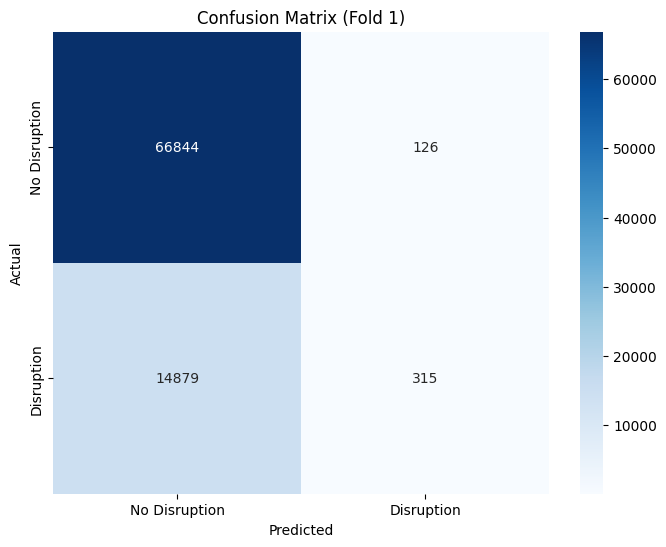


Fold 2/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4109/4109 ━━━━━━━━━━━━━━━━━━━━ 46s 10ms/step - AUC: 0.8614 - Precision: 0.8383 - Recall: 0.8383 - accuracy: 0.8383 - loss: 0.4391 - val_AUC: 0.9098 - val_Precision: 0.8655 - val_Recall: 0.8655 - val_accuracy: 0.8655 - val_loss: 0.3741
Epoch 2/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - AUC: 0.8837 - Precision: 0.8387 - Recall: 0.8387 - accuracy: 0.8387 - loss: 0.4169 - val_AUC: 0.9261 - val_Precision: 0.8641 - val_Recall: 0.8641 - val_accuracy: 0.8641 - val_loss: 0.3487
Epoch 3/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 40s 10ms/step - AUC: 0.8893 - Precision: 0.8392 - Recall: 0.8392 - accuracy: 0.8392 - loss: 0.4105 - val_AUC: 0.9260 - val_Precision: 0.8645 - val_Recall: 0.8645 - val_accuracy: 0.8645 - val_loss: 0.3488
Epoch 4/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 40s 10ms/step - AUC: 0.8907 - Precision: 0.8402 - Recall: 0.8402 - accuracy: 0.8402 - loss: 0.4084 - val_AUC: 0.9257 - val_Precision: 0.8641 - val_Recall: 0.8641 - val_accuracy: 0.8641 - val_loss: 0.3539
Epoch 5/50
4109/4109 ━━━━━━

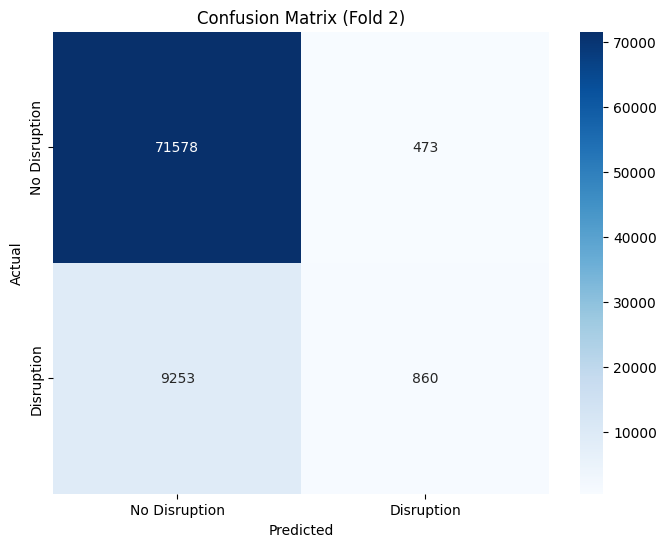


Fold 3/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6163/6163 ━━━━━━━━━━━━━━━━━━━━ 61s 9ms/step - AUC: 0.8723 - Precision: 0.8452 - Recall: 0.8452 - accuracy: 0.8452 - loss: 0.4231 - val_AUC: 0.9435 - val_Precision: 0.8908 - val_Recall: 0.8908 - val_accuracy: 0.8908 - val_loss: 0.3092
Epoch 2/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 59s 10ms/step - AUC: 0.8973 - Precision: 0.8467 - Recall: 0.8467 - accuracy: 0.8467 - loss: 0.3954 - val_AUC: 0.9434 - val_Precision: 0.8906 - val_Recall: 0.8906 - val_accuracy: 0.8906 - val_loss: 0.3040
Epoch 3/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 59s 10ms/step - AUC: 0.8984 - Precision: 0.8464 - Recall: 0.8464 - accuracy: 0.8464 - loss: 0.3944 - val_AUC: 0.9460 - val_Precision: 0.8941 - val_Recall: 0.8941 - val_accuracy: 0.8941 - val_loss: 0.2970
Epoch 4/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 60s 10ms/step - AUC: 0.9030 - Precision: 0.8493 - Recall: 0.8493 - accuracy: 0.8493 - loss: 0.3869 - val_AUC: 0.9448 - val_Precision: 0.8944 - val_Recall: 0.8944 - val_accuracy: 0.8944 - val_loss: 0.2988
Epoch 5/50
6163/6163 ━━━━━━━

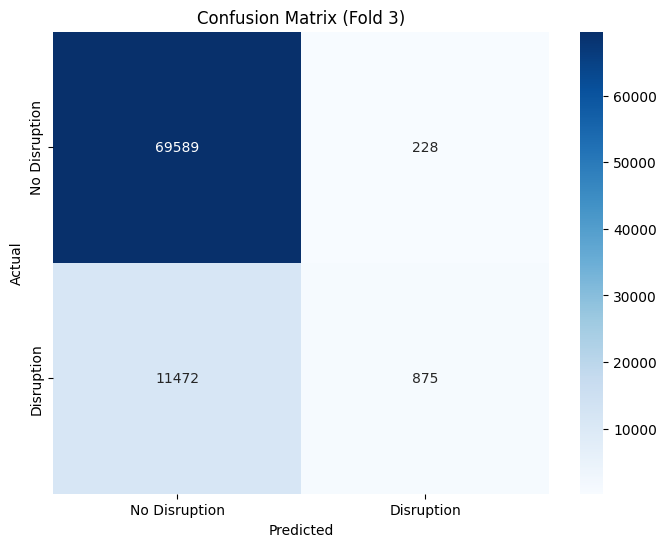


Fold 4/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8217/8217 ━━━━━━━━━━━━━━━━━━━━ 92s 11ms/step - AUC: 0.8862 - Precision: 0.8550 - Recall: 0.8550 - accuracy: 0.8550 - loss: 0.4016 - val_AUC: 0.9185 - val_Precision: 0.8533 - val_Recall: 0.8533 - val_accuracy: 0.8533 - val_loss: 0.3636
Epoch 2/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 84s 10ms/step - AUC: 0.9093 - Precision: 0.8584 - Recall: 0.8584 - accuracy: 0.8584 - loss: 0.3731 - val_AUC: 0.9186 - val_Precision: 0.8524 - val_Recall: 0.8524 - val_accuracy: 0.8524 - val_loss: 0.3671
Epoch 3/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 83s 10ms/step - AUC: 0.9103 - Precision: 0.8578 - Recall: 0.8578 - accuracy: 0.8578 - loss: 0.3720 - val_AUC: 0.9203 - val_Precision: 0.8529 - val_Recall: 0.8529 - val_accuracy: 0.8529 - val_loss: 0.3633
Epoch 4/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 84s 10ms/step - AUC: 0.9123 - Precision: 0.8582 - Recall: 0.8582 - accuracy: 0.8582 - loss: 0.3687 - val_AUC: 0.9189 - val_Precision: 0.8516 - val_Recall: 0.8516 - val_accuracy: 0.8516 - val_loss: 0.3631
Epoch 5/50
8217/8217 ━━━━━━

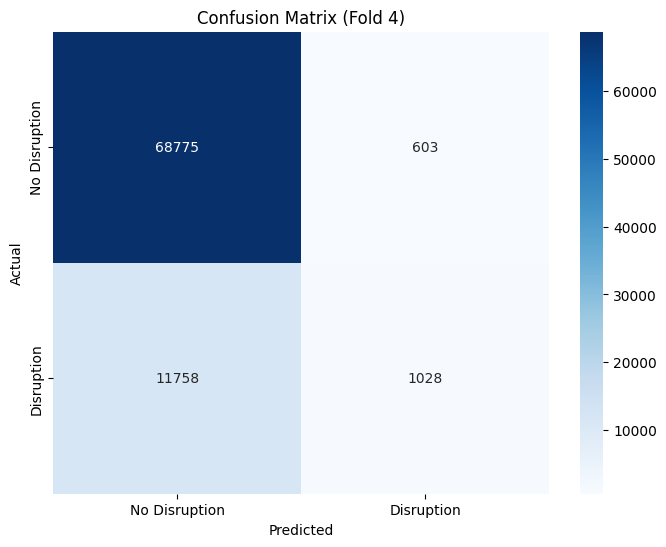


Fold 5/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10271/10271 ━━━━━━━━━━━━━━━━━━━━ 113s 11ms/step - AUC: 0.8897 - Precision: 0.8548 - Recall: 0.8548 - accuracy: 0.8548 - loss: 0.3986 - val_AUC: 0.9153 - val_Precision: 0.8485 - val_Recall: 0.8485 - val_accuracy: 0.8485 - val_loss: 0.3710
Epoch 2/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 106s 10ms/step - AUC: 0.9098 - Precision: 0.8567 - Recall: 0.8567 - accuracy: 0.8567 - loss: 0.3737 - val_AUC: 0.9145 - val_Precision: 0.8479 - val_Recall: 0.8479 - val_accuracy: 0.8479 - val_loss: 0.3721
Epoch 3/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 109s 11ms/step - AUC: 0.9120 - Precision: 0.8563 - Recall: 0.8563 - accuracy: 0.8563 - loss: 0.3704 - val_AUC: 0.9158 - val_Precision: 0.8490 - val_Recall: 0.8490 - val_accuracy: 0.8490 - val_loss: 0.3684
Epoch 4/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 108s 11ms/step - AUC: 0.9147 - Precision: 0.8581 - Recall: 0.8581 - accuracy: 0.8581 - loss: 0.3656 - val_AUC: 0.9158 - val_Precision: 0.8489 - val_Recall: 0.8489 - val_accuracy: 0.8489 - val_loss: 0.3727
Epoch 5/50
1027

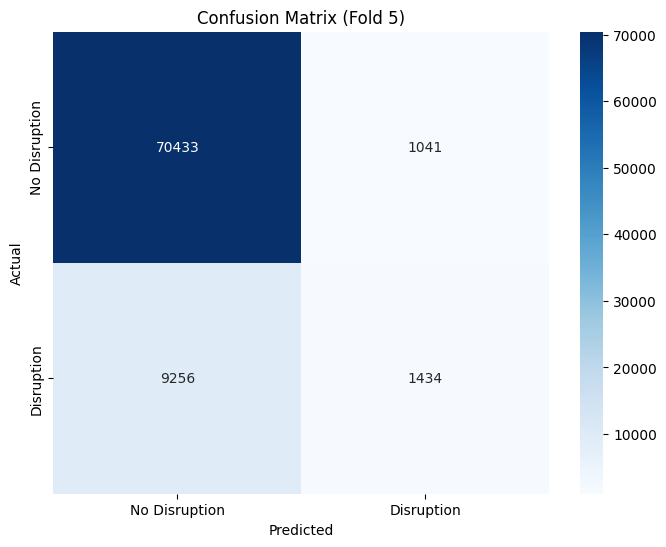


Fold 6/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12325/12325 ━━━━━━━━━━━━━━━━━━━━ 133s 11ms/step - AUC: 0.8874 - Precision: 0.8507 - Recall: 0.8507 - accuracy: 0.8507 - loss: 0.4035 - val_AUC: 0.9332 - val_Precision: 0.8746 - val_Recall: 0.8746 - val_accuracy: 0.8746 - val_loss: 0.3275
Epoch 2/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 1160s 94ms/step - AUC: 0.9113 - Precision: 0.8537 - Recall: 0.8537 - accuracy: 0.8537 - loss: 0.3731 - val_AUC: 0.9351 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3226
Epoch 3/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 125s 10ms/step - AUC: 0.9139 - Precision: 0.8550 - Recall: 0.8550 - accuracy: 0.8550 - loss: 0.3685 - val_AUC: 0.9347 - val_Precision: 0.8777 - val_Recall: 0.8777 - val_accuracy: 0.8777 - val_loss: 0.3268
Epoch 4/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 127s 10ms/step - AUC: 0.9148 - Precision: 0.8551 - Recall: 0.8551 - accuracy: 0.8551 - loss: 0.3671 - val_AUC: 0.9362 - val_Precision: 0.8764 - val_Recall: 0.8764 - val_accuracy: 0.8764 - val_loss: 0.3206
Epoch 5/50
123

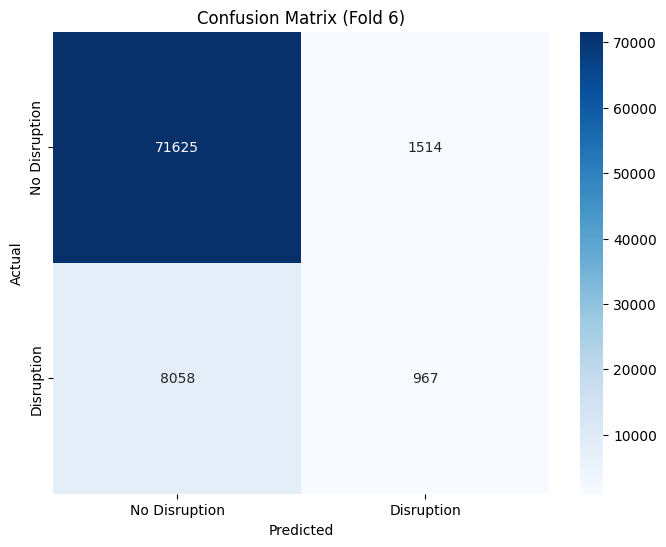


Cross-Validation Results (Mean ± Std):
Accuracy: 0.8607 ± 0.0230
Precision: 0.8607 ± 0.0230
Recall: 0.8607 ± 0.0230
F1: 0.1415 ± 0.0532
Auc: 0.7491 ± 0.0354
Balanced_acc: 0.5369 ± 0.0149

Fold 1/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step
Test Loss: 0.4137
Test Accuracy: 0.8261
Test Precision: 0.8261
Test Recall: 0.8261
Test F1 Score: 0.1881
Test Balanced Accuracy: 0.5489
Test AUC: 0.7525

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.99      0.90     66970
           1       0.69      0.11      0.19     15194

    accuracy                           0.83     82164
   macro avg       0.76      0.55      0.55     82164
weighted avg       0.80      0.83      0.77     82164



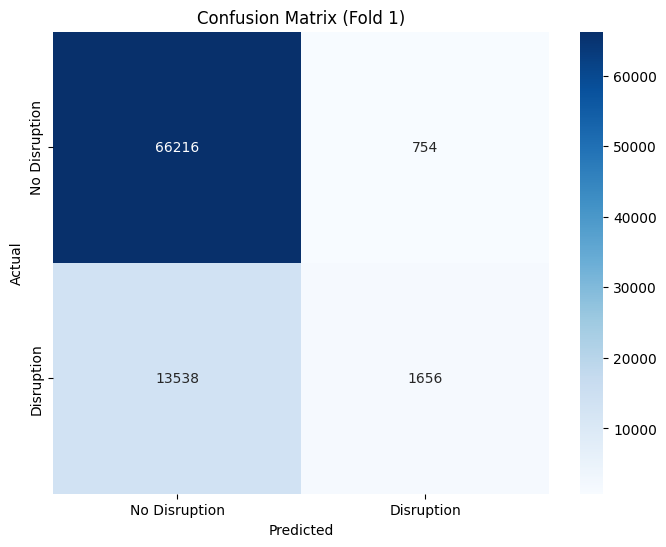


Fold 2/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step
Test Loss: 0.3125
Test Accuracy: 0.8839
Test Precision: 0.8839
Test Recall: 0.8839
Test F1 Score: 0.1877
Test Balanced Accuracy: 0.5508
Test AUC: 0.7958

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     72051
           1       0.68      0.11      0.19     10113

    accuracy                           0.88     82164
   macro avg       0.78      0.55      0.56     82164
weighted avg       0.86      0.88      0.85     82164



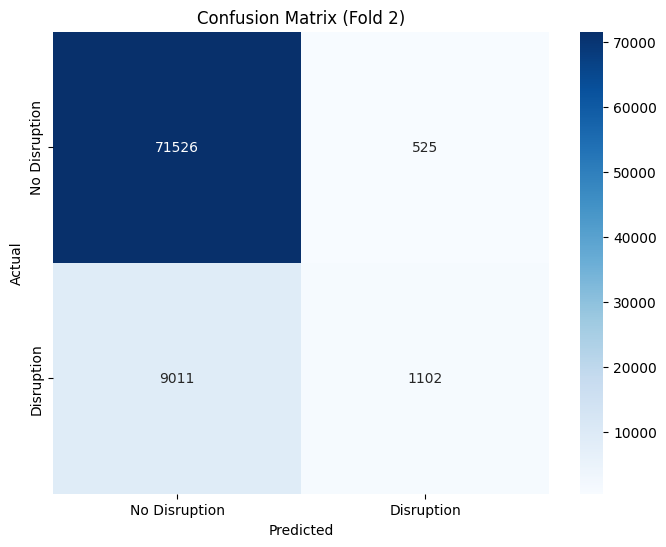


Fold 3/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step
Test Loss: 0.3437
Test Accuracy: 0.8596
Test Precision: 0.8596
Test Recall: 0.8596
Test F1 Score: 0.2057
Test Balanced Accuracy: 0.5556
Test AUC: 0.8029

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92     69817
           1       0.69      0.12      0.21     12347

    accuracy                           0.86     82164
   macro avg       0.78      0.56      0.56     82164
weighted avg       0.84      0.86      0.82     82164



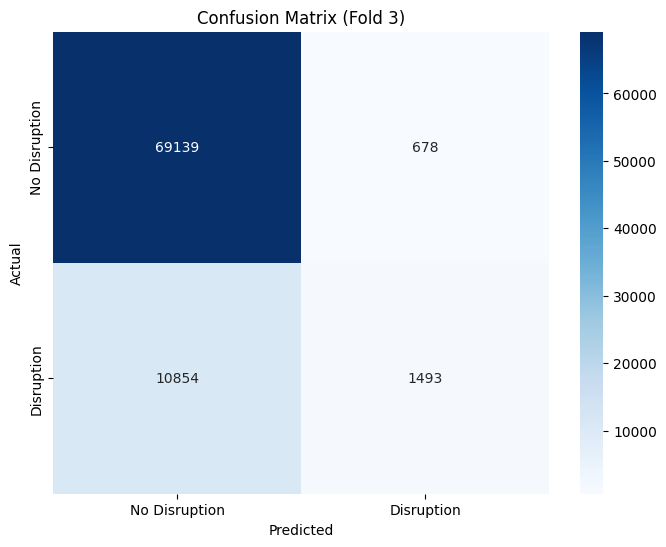


Fold 4/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step
Test Loss: 0.3592
Test Accuracy: 0.8529
Test Precision: 0.8529
Test Recall: 0.8529
Test F1 Score: 0.2061
Test Balanced Accuracy: 0.5551
Test AUC: 0.7866

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92     69378
           1       0.64      0.12      0.21     12786

    accuracy                           0.85     82164
   macro avg       0.75      0.56      0.56     82164
weighted avg       0.83      0.85      0.81     82164



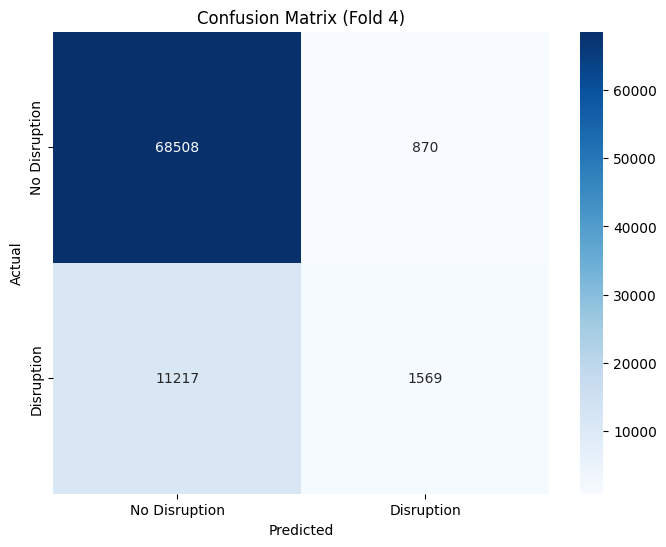


Fold 5/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step
Test Loss: 0.3251
Test Accuracy: 0.8792
Test Precision: 0.8792
Test Recall: 0.8792
Test F1 Score: 0.2477
Test Balanced Accuracy: 0.5704
Test AUC: 0.7938

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.93     71474
           1       0.65      0.15      0.25     10690

    accuracy                           0.88     82164
   macro avg       0.77      0.57      0.59     82164
weighted avg       0.86      0.88      0.85     82164



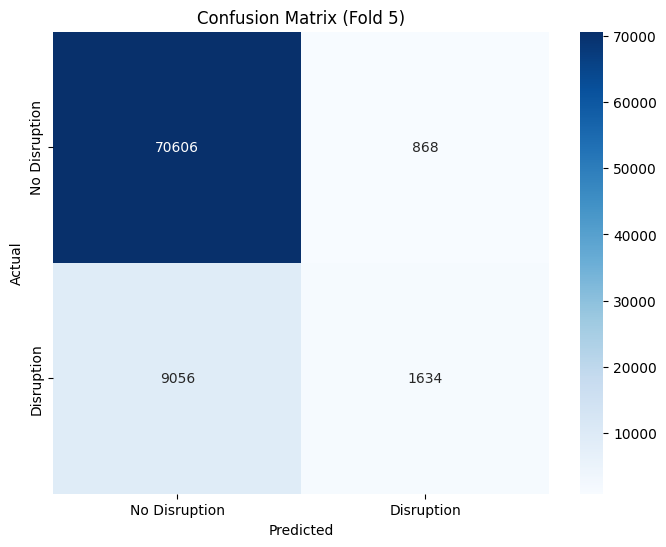


Fold 6/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step
Test Loss: 0.3255
Test Accuracy: 0.8835
Test Precision: 0.8835
Test Recall: 0.8835
Test F1 Score: 0.1681
Test Balanced Accuracy: 0.5432
Test AUC: 0.7643

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94     73139
           1       0.39      0.11      0.17      9025

    accuracy                           0.88     82164
   macro avg       0.64      0.54      0.55     82164
weighted avg       0.84      0.88      0.85     82164



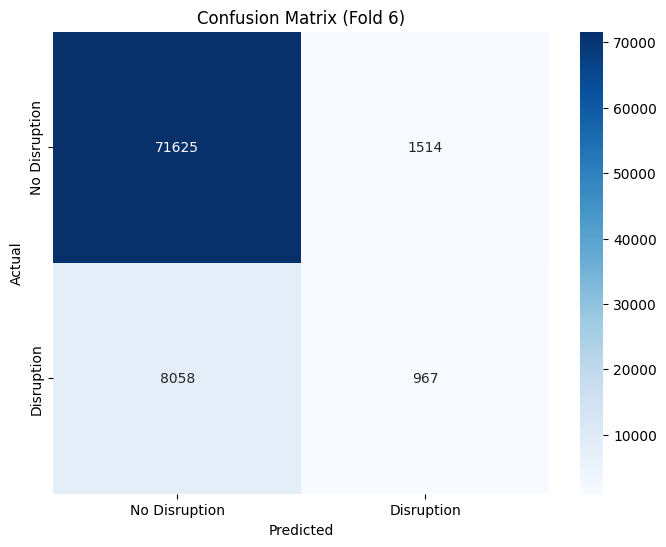


Cross-Validation Results (Mean ± Std):
Accuracy: 0.8642 ± 0.0208
Precision: 0.8642 ± 0.0208
Recall: 0.8642 ± 0.0208
F1: 0.2006 ± 0.0247
Auc: 0.7827 ± 0.0181
Balanced_acc: 0.5540 ± 0.0084


({'accuracy': [0.8260552287101746,
   0.8839394450187683,
   0.8596465587615967,
   0.8528918027877808,
   0.8792171478271484,
   0.8835012912750244],
  'precision': [0.8260552287101746,
   0.8839394450187683,
   0.8596465587615967,
   0.8528918027877808,
   0.8792171478271484,
   0.8835012912750244],
  'recall': [0.8260552287101746,
   0.8839394450187683,
   0.8596465587615967,
   0.8528918027877808,
   0.8792171478271484,
   0.8835012912750244],
  'f1': [0.18813905930470348,
   0.1877342419080068,
   0.20567571290811407,
   0.20610837438423646,
   0.24772589448150395,
   0.1680862158873631],
  'auc': [0.7525241700545524,
   0.795834292107518,
   0.8028569131867804,
   0.78659258325245,
   0.7938309496152028,
   0.7643177255284297],
  'balanced_acc': [0.5488658091795271,
   0.5508410744077209,
   0.5556044798363915,
   0.555086171676653,
   0.5703544287647836,
   0.5432232520182513]},
 {'accuracy': 0.8642085790634155,
  'precision': 0.8642085790634155,
  'recall': 0.8642085790634155,


In [21]:
topo_reshaped = X_topo.reshape((X_topo.shape[0], X_topo.shape[1], 1))
topo_features = [ 
    'source_degree', 'source_weighted_degree', 'source_avg_distance', 
    'target_degree', 'target_weighted_degree', 'target_avg_distance', 
    'common_neighbors', 'jaccard_coefficient', 'preferential_attachment', 
    'adamic_adar_index', 'resource_allocation_index','weight', 'distance']
# Ensure the LSTM model is compatible with the reshaped input
final_model_topo, cv_metrics, feature_importance = cross_validate_lstm(
    X=topo_reshaped, 
    y=y, 
    features=topo_features, 
    resample=False, 
    n_splits=6, 
    epochs=50, 
    batch_size=32
)
lstm_predict(topo_reshaped, y, final_model_topo, n_splits=6)


Fold 1/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2055/2055 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - AUC: 0.8888 - Precision: 0.8725 - Recall: 0.8725 - accuracy: 0.8725 - loss: 0.3859 - val_AUC: 0.9042 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3688
Epoch 2/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - AUC: 0.9078 - Precision: 0.8713 - Recall: 0.8713 - accuracy: 0.8713 - loss: 0.3638 - val_AUC: 0.9302 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3364
Epoch 3/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - AUC: 0.9213 - Precision: 0.8695 - Recall: 0.8695 - accuracy: 0.8695 - loss: 0.3486 - val_AUC: 0.9307 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3296
Epoch 4/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - AUC: 0.9238 - Precision: 0.8703 - Recall: 0.8703 - accuracy: 0.8703 - loss: 0.3440 - val_AUC: 0.9313 - val_Precision: 0.8756 - val_Recall: 0.8756 - val_accuracy: 0.8756 - val_loss: 0.3285
Epoch 5/50
2055/2055 ━━━━━━

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

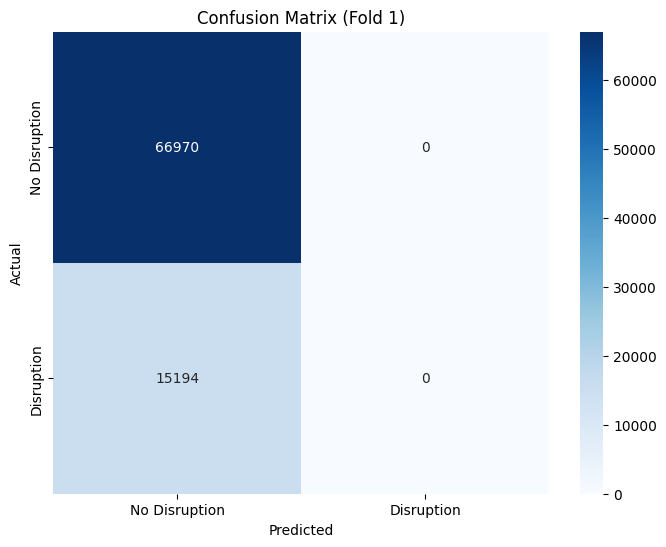


Fold 2/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4109/4109 ━━━━━━━━━━━━━━━━━━━━ 58s 13ms/step - AUC: 0.8605 - Precision: 0.8377 - Recall: 0.8377 - accuracy: 0.8377 - loss: 0.4403 - val_AUC: 0.9086 - val_Precision: 0.8655 - val_Recall: 0.8655 - val_accuracy: 0.8655 - val_loss: 0.3744
Epoch 2/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 54s 13ms/step - AUC: 0.8836 - Precision: 0.8385 - Recall: 0.8385 - accuracy: 0.8385 - loss: 0.4173 - val_AUC: 0.9239 - val_Precision: 0.8655 - val_Recall: 0.8655 - val_accuracy: 0.8655 - val_loss: 0.3533
Epoch 3/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 54s 13ms/step - AUC: 0.8898 - Precision: 0.8399 - Recall: 0.8399 - accuracy: 0.8399 - loss: 0.4094 - val_AUC: 0.9268 - val_Precision: 0.8667 - val_Recall: 0.8667 - val_accuracy: 0.8667 - val_loss: 0.3500
Epoch 4/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 55s 13ms/step - AUC: 0.8915 - Precision: 0.8379 - Recall: 0.8379 - accuracy: 0.8379 - loss: 0.4090 - val_AUC: 0.9261 - val_Precision: 0.8645 - val_Recall: 0.8645 - val_accuracy: 0.8645 - val_loss: 0.3528
Epoch 5/50
4109/4109 ━━━━━━

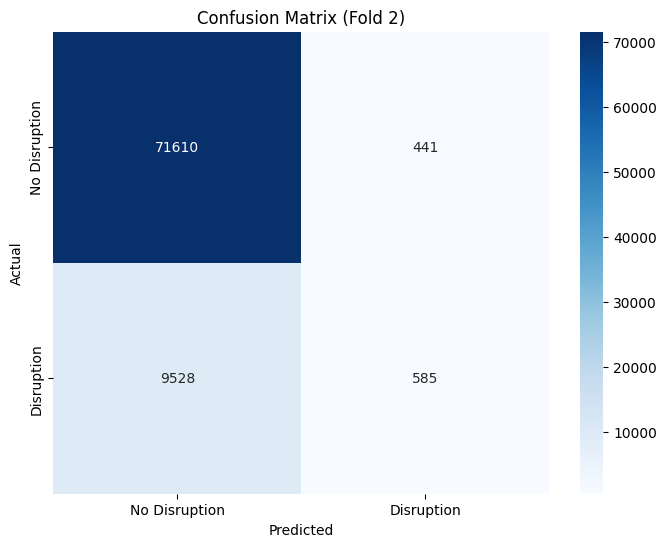


Fold 3/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6163/6163 ━━━━━━━━━━━━━━━━━━━━ 88s 14ms/step - AUC: 0.8746 - Precision: 0.8472 - Recall: 0.8472 - accuracy: 0.8472 - loss: 0.4193 - val_AUC: 0.9430 - val_Precision: 0.8908 - val_Recall: 0.8908 - val_accuracy: 0.8908 - val_loss: 0.3027
Epoch 2/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 81s 13ms/step - AUC: 0.8984 - Precision: 0.8456 - Recall: 0.8456 - accuracy: 0.8456 - loss: 0.3954 - val_AUC: 0.9448 - val_Precision: 0.8924 - val_Recall: 0.8924 - val_accuracy: 0.8924 - val_loss: 0.2990
Epoch 3/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 81s 13ms/step - AUC: 0.9022 - Precision: 0.8492 - Recall: 0.8492 - accuracy: 0.8492 - loss: 0.3883 - val_AUC: 0.9449 - val_Precision: 0.8938 - val_Recall: 0.8938 - val_accuracy: 0.8938 - val_loss: 0.2973
Epoch 4/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 82s 13ms/step - AUC: 0.9037 - Precision: 0.8486 - Recall: 0.8486 - accuracy: 0.8486 - loss: 0.3866 - val_AUC: 0.9453 - val_Precision: 0.8925 - val_Recall: 0.8925 - val_accuracy: 0.8925 - val_loss: 0.3035
Epoch 5/50
6163/6163 ━━━━━━

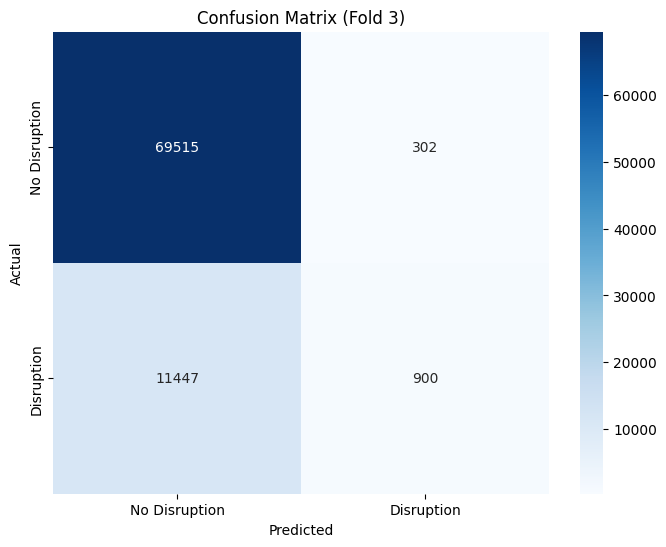


Fold 4/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8217/8217 ━━━━━━━━━━━━━━━━━━━━ 115s 14ms/step - AUC: 0.8857 - Precision: 0.8558 - Recall: 0.8558 - accuracy: 0.8558 - loss: 0.4019 - val_AUC: 0.9170 - val_Precision: 0.8524 - val_Recall: 0.8524 - val_accuracy: 0.8524 - val_loss: 0.3696
Epoch 2/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 111s 14ms/step - AUC: 0.9074 - Precision: 0.8575 - Recall: 0.8575 - accuracy: 0.8575 - loss: 0.3765 - val_AUC: 0.9196 - val_Precision: 0.8530 - val_Recall: 0.8530 - val_accuracy: 0.8530 - val_loss: 0.3642
Epoch 3/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 112s 14ms/step - AUC: 0.9095 - Precision: 0.8584 - Recall: 0.8584 - accuracy: 0.8584 - loss: 0.3729 - val_AUC: 0.9197 - val_Precision: 0.8532 - val_Recall: 0.8532 - val_accuracy: 0.8532 - val_loss: 0.3630
Epoch 4/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 112s 14ms/step - AUC: 0.9123 - Precision: 0.8594 - Recall: 0.8594 - accuracy: 0.8594 - loss: 0.3683 - val_AUC: 0.9178 - val_Precision: 0.8511 - val_Recall: 0.8511 - val_accuracy: 0.8511 - val_loss: 0.3678
Epoch 5/50
8217/8217 ━━

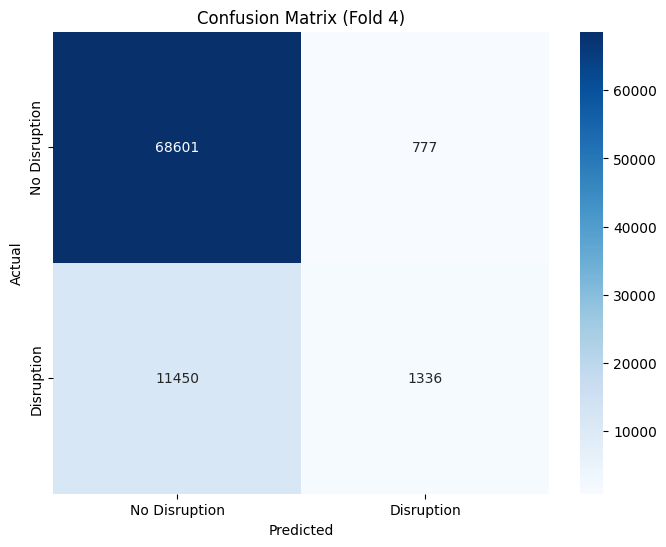


Fold 5/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10271/10271 ━━━━━━━━━━━━━━━━━━━━ 150s 14ms/step - AUC: 0.8894 - Precision: 0.8558 - Recall: 0.8558 - accuracy: 0.8558 - loss: 0.3985 - val_AUC: 0.9149 - val_Precision: 0.8485 - val_Recall: 0.8485 - val_accuracy: 0.8485 - val_loss: 0.3716
Epoch 2/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 145s 14ms/step - AUC: 0.9109 - Precision: 0.8578 - Recall: 0.8578 - accuracy: 0.8578 - loss: 0.3714 - val_AUC: 0.9155 - val_Precision: 0.8484 - val_Recall: 0.8484 - val_accuracy: 0.8484 - val_loss: 0.3720
Epoch 3/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 146s 14ms/step - AUC: 0.9119 - Precision: 0.8575 - Recall: 0.8575 - accuracy: 0.8575 - loss: 0.3699 - val_AUC: 0.9154 - val_Precision: 0.8491 - val_Recall: 0.8491 - val_accuracy: 0.8491 - val_loss: 0.3708
Epoch 4/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 147s 14ms/step - AUC: 0.9132 - Precision: 0.8566 - Recall: 0.8566 - accuracy: 0.8566 - loss: 0.3684 - val_AUC: 0.9166 - val_Precision: 0.8488 - val_Recall: 0.8488 - val_accuracy: 0.8488 - val_loss: 0.3692
Epoch 5/50
1027

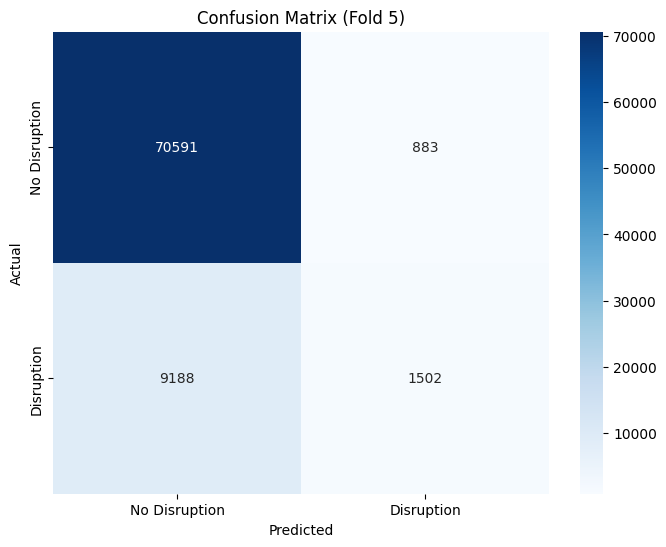


Fold 6/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12325/12325 ━━━━━━━━━━━━━━━━━━━━ 183s 15ms/step - AUC: 0.8884 - Precision: 0.8511 - Recall: 0.8511 - accuracy: 0.8511 - loss: 0.4028 - val_AUC: 0.9334 - val_Precision: 0.8749 - val_Recall: 0.8749 - val_accuracy: 0.8749 - val_loss: 0.3270
Epoch 2/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 164s 13ms/step - AUC: 0.9114 - Precision: 0.8547 - Recall: 0.8547 - accuracy: 0.8547 - loss: 0.3725 - val_AUC: 0.9344 - val_Precision: 0.8757 - val_Recall: 0.8757 - val_accuracy: 0.8757 - val_loss: 0.3241
Epoch 3/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 165s 13ms/step - AUC: 0.9133 - Precision: 0.8551 - Recall: 0.8551 - accuracy: 0.8551 - loss: 0.3693 - val_AUC: 0.9361 - val_Precision: 0.8781 - val_Recall: 0.8781 - val_accuracy: 0.8781 - val_loss: 0.3201
Epoch 4/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 165s 13ms/step - AUC: 0.9153 - Precision: 0.8554 - Recall: 0.8554 - accuracy: 0.8554 - loss: 0.3658 - val_AUC: 0.9344 - val_Precision: 0.8771 - val_Recall: 0.8771 - val_accuracy: 0.8771 - val_loss: 0.3253
Epoch 5/50
1232

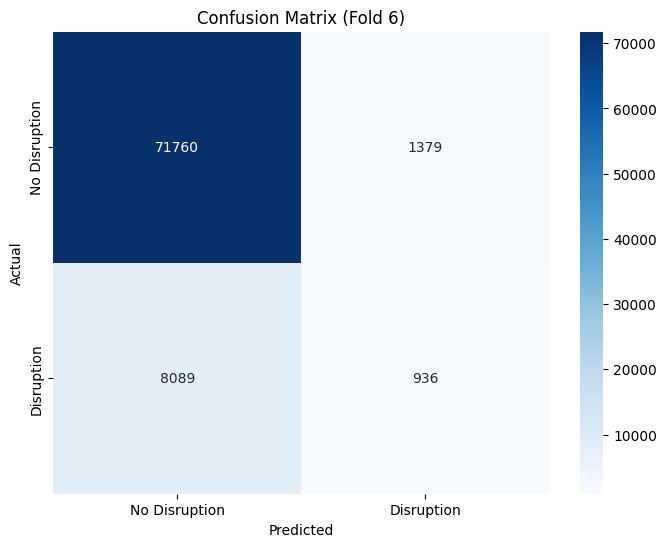


Cross-Validation Results (Mean ± Std):
Accuracy: 0.8607 ± 0.0237
Precision: 0.8607 ± 0.0237
Recall: 0.8607 ± 0.0237
F1: 0.1353 ± 0.0719
Auc: 0.7366 ± 0.0551
Balanced_acc: 0.5355 ± 0.0198

Fold 1/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step
Test Loss: 2.1125
Test Accuracy: 0.6419
Test Precision: 0.6419
Test Recall: 0.6419
Test F1 Score: 0.2203
Test Balanced Accuracy: 0.4995
Test AUC: 0.4960

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.73      0.77     66970
           1       0.18      0.27      0.22     15194

    accuracy                           0.64     82164
   macro avg       0.50      0.50      0.49     82164
weighted avg       0.70      0.64      0.67     82164



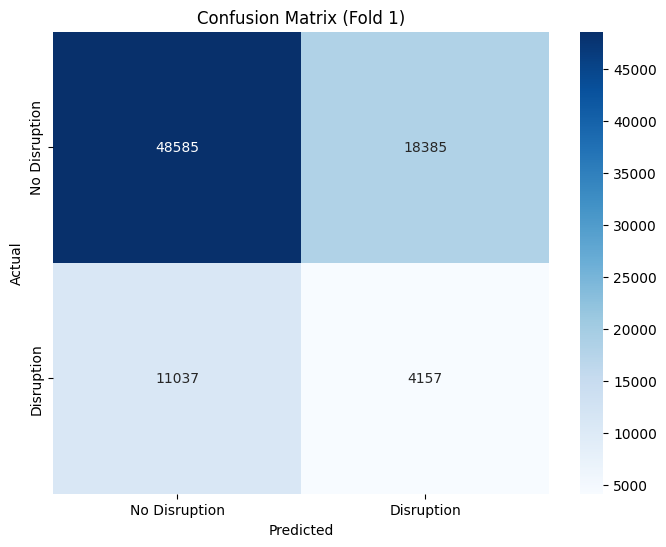


Fold 2/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step
Test Loss: 3.1364
Test Accuracy: 0.6690
Test Precision: 0.6690
Test Recall: 0.6690
Test F1 Score: 0.1752
Test Balanced Accuracy: 0.5042
Test AUC: 0.4878

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.72      0.79     72051
           1       0.13      0.29      0.18     10113

    accuracy                           0.67     82164
   macro avg       0.50      0.50      0.48     82164
weighted avg       0.79      0.67      0.72     82164



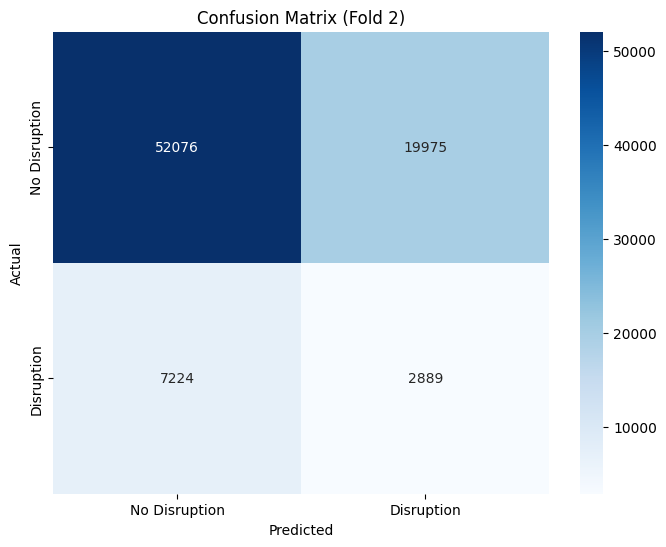


Fold 3/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step
Test Loss: 2.0038
Test Accuracy: 0.6565
Test Precision: 0.6565
Test Recall: 0.6565
Test F1 Score: 0.1894
Test Balanced Accuracy: 0.4962
Test AUC: 0.4932

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.73      0.78     69817
           1       0.15      0.27      0.19     12347

    accuracy                           0.66     82164
   macro avg       0.50      0.50      0.49     82164
weighted avg       0.74      0.66      0.69     82164



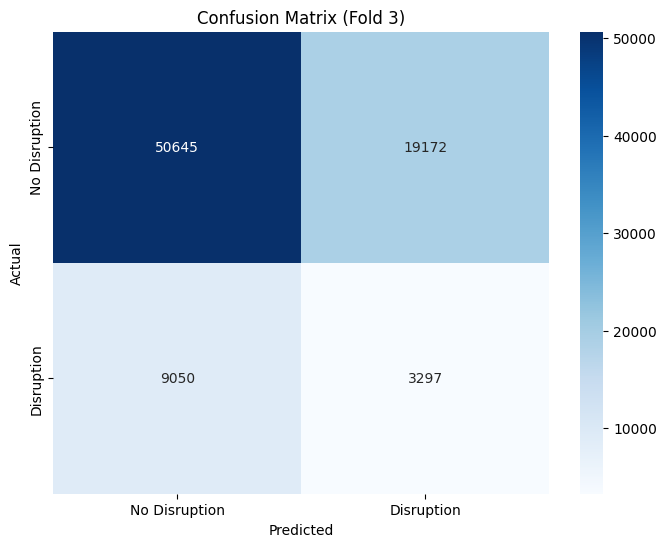


Fold 4/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step
Test Loss: 2.6521
Test Accuracy: 0.6703
Test Precision: 0.6703
Test Recall: 0.6703
Test F1 Score: 0.2190
Test Balanced Accuracy: 0.5181
Test AUC: 0.5288

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.74      0.79     69378
           1       0.17      0.30      0.22     12786

    accuracy                           0.67     82164
   macro avg       0.51      0.52      0.51     82164
weighted avg       0.75      0.67      0.70     82164



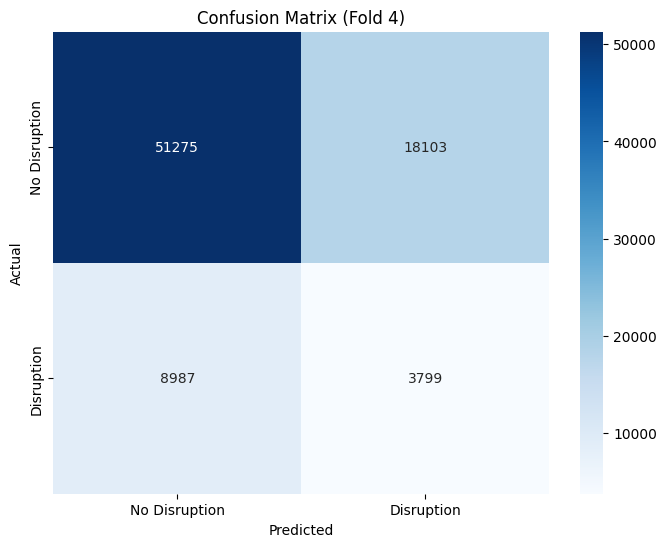


Fold 5/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step
Test Loss: 1.8405
Test Accuracy: 0.6972
Test Precision: 0.6972
Test Recall: 0.6972
Test F1 Score: 0.1529
Test Balanced Accuracy: 0.4901
Test AUC: 0.4846

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.77      0.82     71474
           1       0.12      0.21      0.15     10690

    accuracy                           0.70     82164
   macro avg       0.49      0.49      0.48     82164
weighted avg       0.77      0.70      0.73     82164



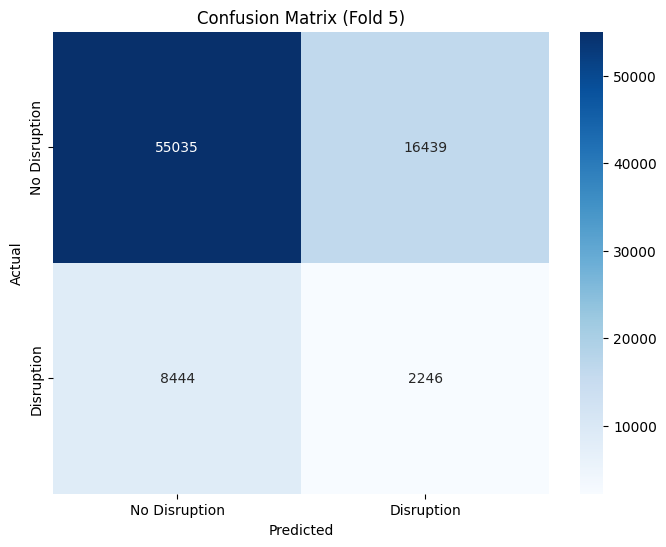


Fold 6/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step
Test Loss: 1.5900
Test Accuracy: 0.6648
Test Precision: 0.6648
Test Recall: 0.6648
Test F1 Score: 0.1590
Test Balanced Accuracy: 0.4999
Test AUC: 0.5010

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.71      0.79     73139
           1       0.11      0.29      0.16      9025

    accuracy                           0.66     82164
   macro avg       0.50      0.50      0.47     82164
weighted avg       0.80      0.66      0.72     82164



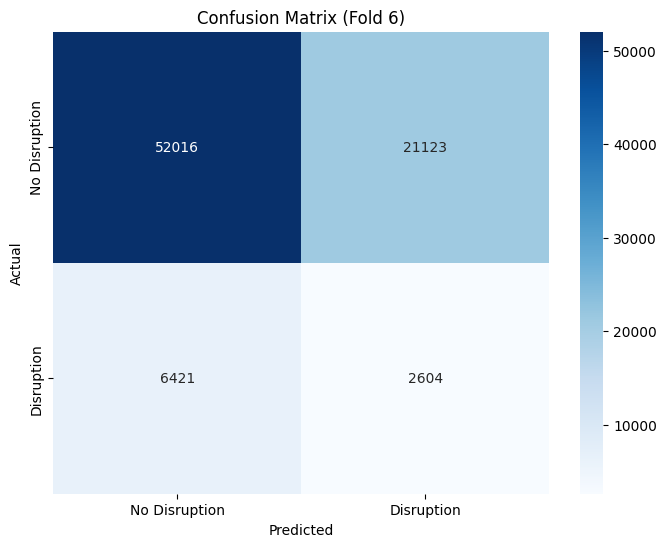


Cross-Validation Results (Mean ± Std):
Accuracy: 0.6666 ± 0.0167
Precision: 0.6666 ± 0.0167
Recall: 0.6666 ± 0.0167
F1: 0.1860 ± 0.0265
Auc: 0.4986 ± 0.0145
Balanced_acc: 0.5013 ± 0.0086


({'accuracy': [0.6419113278388977,
   0.6689669489860535,
   0.6565162539482117,
   0.6702935695648193,
   0.6971544623374939,
   0.6647680401802063],
  'precision': [0.6419113278388977,
   0.6689669489860535,
   0.6565162539482117,
   0.6702935695648193,
   0.6971544623374939,
   0.6647680401802063],
  'recall': [0.6419113278388977,
   0.6689669489860535,
   0.6565162539482117,
   0.6702935695648193,
   0.6971544623374939,
   0.6647680401802063],
  'f1': [0.22032011871952512,
   0.17521302726142463,
   0.18939568014705882,
   0.21903828413284132,
   0.1529191489361702,
   0.1590131900341964],
  'auc': [0.49600082868309203,
   0.487826357595734,
   0.4932221093026547,
   0.5287620809856474,
   0.4846228061815174,
   0.5009562128863346],
  'balanced_acc': [0.499534466472928,
   0.5042188630510457,
   0.4962124106933715,
   0.5180944957323341,
   0.4900515898642439,
   0.49986280515690934]},
 {'accuracy': 0.6666017671426138,
  'precision': 0.6666017671426138,
  'recall': 0.66660176714261

In [22]:
wthr_reshaped = X_wthr.reshape((X_wthr.shape[0], X_wthr.shape[1], 1))

# Ensure the LSTM model is compatible with the reshaped input
final_model_wthr, cv_metrics, feature_importance = cross_validate_lstm(
    X=topo_reshaped, 
    y=y, 
    features=wthr_features, 
    resample=False, 
    n_splits=6, 
    epochs=50, 
    batch_size=32
)
lstm_predict(wthr_reshaped, y, final_model_wthr, n_splits=6)


Fold 1/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2055/2055 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - AUC: 0.9121 - Precision: 0.8721 - Recall: 0.8721 - accuracy: 0.8721 - loss: 0.3711 - val_AUC: 0.9386 - val_Precision: 0.8823 - val_Recall: 0.8823 - val_accuracy: 0.8823 - val_loss: 0.3249
Epoch 2/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - AUC: 0.9304 - Precision: 0.8738 - Recall: 0.8738 - accuracy: 0.8738 - loss: 0.3319 - val_AUC: 0.9357 - val_Precision: 0.8757 - val_Recall: 0.8757 - val_accuracy: 0.8757 - val_loss: 0.3252
Epoch 3/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - AUC: 0.9314 - Precision: 0.8771 - Recall: 0.8771 - accuracy: 0.8771 - loss: 0.3278 - val_AUC: 0.9393 - val_Precision: 0.8799 - val_Recall: 0.8799 - val_accuracy: 0.8799 - val_loss: 0.3292
Epoch 4/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - AUC: 0.9320 - Precision: 0.8762 - Recall: 0.8762 - accuracy: 0.8762 - loss: 0.3275 - val_AUC: 0.9363 - val_Precision: 0.8784 - val_Recall: 0.8784 - val_accuracy: 0.8784 - val_loss: 0.3283
Epoch 5/50
2055/2055 ━━━━━━━━━━

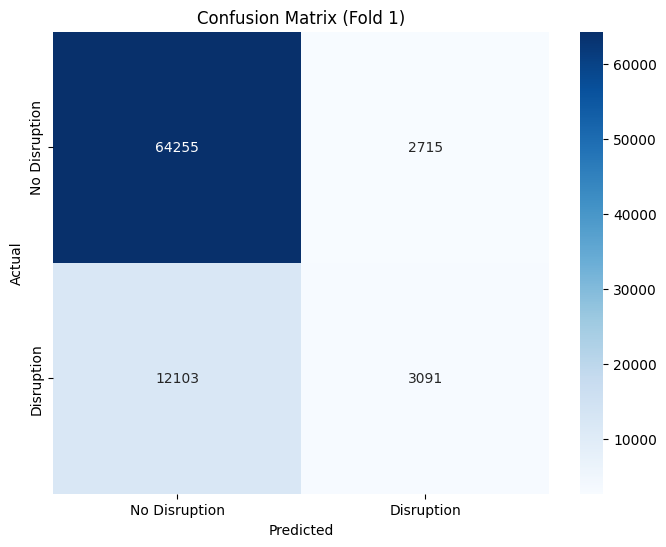


Fold 2/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4109/4109 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - AUC: 0.9069 - Precision: 0.8409 - Recall: 0.8409 - accuracy: 0.8409 - loss: 0.3867 - val_AUC: 0.9070 - val_Precision: 0.8282 - val_Recall: 0.8282 - val_accuracy: 0.8282 - val_loss: 0.3923
Epoch 2/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - AUC: 0.9235 - Precision: 0.8506 - Recall: 0.8506 - accuracy: 0.8506 - loss: 0.3516 - val_AUC: 0.9225 - val_Precision: 0.8443 - val_Recall: 0.8443 - val_accuracy: 0.8443 - val_loss: 0.3551
Epoch 3/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - AUC: 0.9263 - Precision: 0.8542 - Recall: 0.8542 - accuracy: 0.8542 - loss: 0.3452 - val_AUC: 0.9170 - val_Precision: 0.8376 - val_Recall: 0.8376 - val_accuracy: 0.8376 - val_loss: 0.3768
Epoch 4/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 27s 6ms/step - AUC: 0.9252 - Precision: 0.8540 - Recall: 0.8540 - accuracy: 0.8540 - loss: 0.3475 - val_AUC: 0.9205 - val_Precision: 0.8420 - val_Recall: 0.8420 - val_accuracy: 0.8420 - val_loss: 0.3639
Epoch 5/50
4109/4109 ━━━━━━━━━━

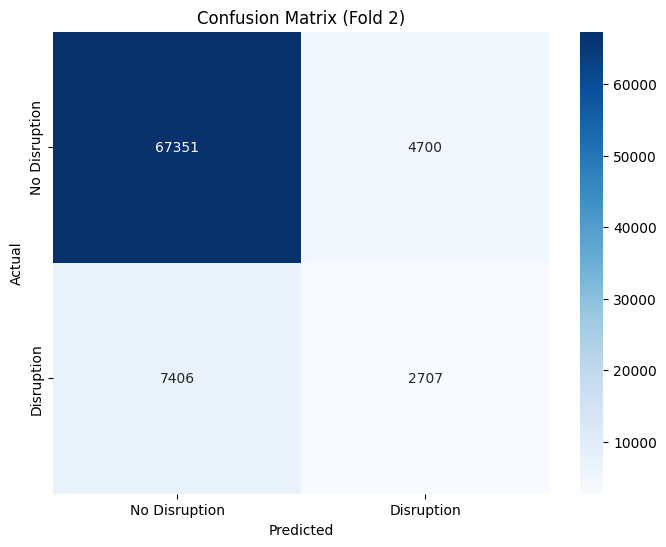


Fold 3/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6163/6163 ━━━━━━━━━━━━━━━━━━━━ 42s 6ms/step - AUC: 0.9099 - Precision: 0.8454 - Recall: 0.8454 - accuracy: 0.8454 - loss: 0.3794 - val_AUC: 0.9421 - val_Precision: 0.8935 - val_Recall: 0.8935 - val_accuracy: 0.8935 - val_loss: 0.3093
Epoch 2/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - AUC: 0.9247 - Precision: 0.8516 - Recall: 0.8516 - accuracy: 0.8516 - loss: 0.3487 - val_AUC: 0.9412 - val_Precision: 0.8795 - val_Recall: 0.8795 - val_accuracy: 0.8795 - val_loss: 0.3140
Epoch 3/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - AUC: 0.9239 - Precision: 0.8512 - Recall: 0.8512 - accuracy: 0.8512 - loss: 0.3504 - val_AUC: 0.9357 - val_Precision: 0.8456 - val_Recall: 0.8456 - val_accuracy: 0.8456 - val_loss: 0.3211
Epoch 4/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - AUC: 0.9260 - Precision: 0.8536 - Recall: 0.8536 - accuracy: 0.8536 - loss: 0.3455 - val_AUC: 0.9394 - val_Precision: 0.8821 - val_Recall: 0.8821 - val_accuracy: 0.8821 - val_loss: 0.3148
Epoch 5/50
6163/6163 ━━━━━━━━━━

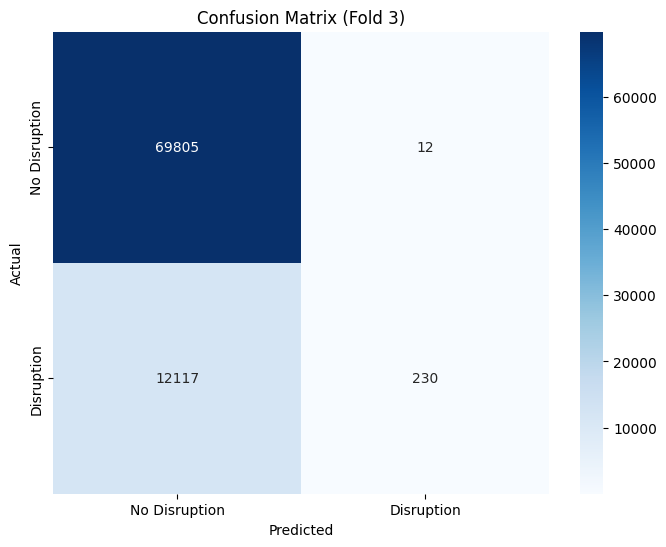


Fold 4/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8217/8217 ━━━━━━━━━━━━━━━━━━━━ 54s 6ms/step - AUC: 0.9128 - Precision: 0.8553 - Recall: 0.8553 - accuracy: 0.8553 - loss: 0.3727 - val_AUC: 0.9104 - val_Precision: 0.8478 - val_Recall: 0.8478 - val_accuracy: 0.8478 - val_loss: 0.3790
Epoch 2/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 50s 6ms/step - AUC: 0.9270 - Precision: 0.8601 - Recall: 0.8601 - accuracy: 0.8601 - loss: 0.3432 - val_AUC: 0.9156 - val_Precision: 0.8506 - val_Recall: 0.8506 - val_accuracy: 0.8506 - val_loss: 0.3687
Epoch 3/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - AUC: 0.9262 - Precision: 0.8577 - Recall: 0.8577 - accuracy: 0.8577 - loss: 0.3450 - val_AUC: 0.9098 - val_Precision: 0.8480 - val_Recall: 0.8480 - val_accuracy: 0.8480 - val_loss: 0.3787
Epoch 4/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - AUC: 0.9278 - Precision: 0.8604 - Recall: 0.8604 - accuracy: 0.8604 - loss: 0.3410 - val_AUC: 0.9134 - val_Precision: 0.8476 - val_Recall: 0.8476 - val_accuracy: 0.8476 - val_loss: 0.3749
Epoch 5/50
8217/8217 ━━━━━━━━━━

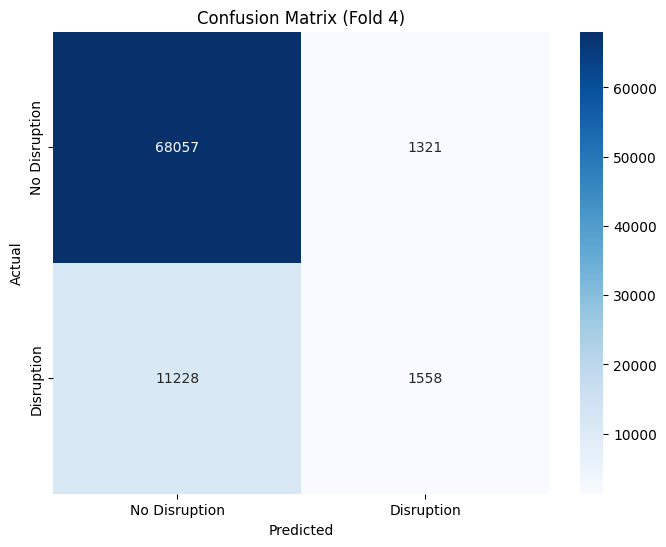


Fold 5/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10271/10271 ━━━━━━━━━━━━━━━━━━━━ 66s 6ms/step - AUC: 0.9128 - Precision: 0.8538 - Recall: 0.8538 - accuracy: 0.8538 - loss: 0.3722 - val_AUC: 0.9129 - val_Precision: 0.8512 - val_Recall: 0.8512 - val_accuracy: 0.8512 - val_loss: 0.3758
Epoch 2/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 62s 6ms/step - AUC: 0.9228 - Precision: 0.8556 - Recall: 0.8556 - accuracy: 0.8556 - loss: 0.3526 - val_AUC: 0.9113 - val_Precision: 0.8498 - val_Recall: 0.8498 - val_accuracy: 0.8498 - val_loss: 0.3765
Epoch 3/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 61s 6ms/step - AUC: 0.9238 - Precision: 0.8560 - Recall: 0.8560 - accuracy: 0.8560 - loss: 0.3504 - val_AUC: 0.9086 - val_Precision: 0.8418 - val_Recall: 0.8418 - val_accuracy: 0.8418 - val_loss: 0.3883
Epoch 4/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 61s 6ms/step - AUC: 0.9240 - Precision: 0.8562 - Recall: 0.8562 - accuracy: 0.8562 - loss: 0.3499 - val_AUC: 0.9126 - val_Precision: 0.8511 - val_Recall: 0.8511 - val_accuracy: 0.8511 - val_loss: 0.3757
Epoch 5/50
10271/10271 

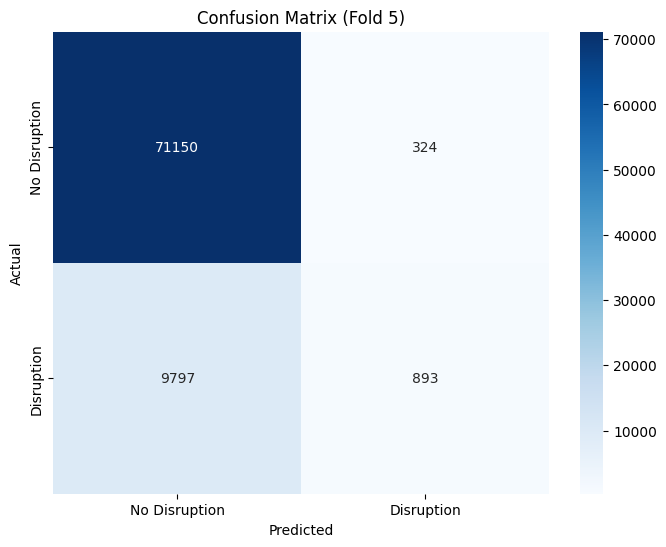


Fold 6/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12325/12325 ━━━━━━━━━━━━━━━━━━━━ 82s 6ms/step - AUC: 0.9104 - Precision: 0.8520 - Recall: 0.8520 - accuracy: 0.8520 - loss: 0.3773 - val_AUC: 0.9283 - val_Precision: 0.8722 - val_Recall: 0.8722 - val_accuracy: 0.8722 - val_loss: 0.3484
Epoch 2/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 77s 6ms/step - AUC: 0.9194 - Precision: 0.8536 - Recall: 0.8536 - accuracy: 0.8536 - loss: 0.3597 - val_AUC: 0.9314 - val_Precision: 0.8780 - val_Recall: 0.8780 - val_accuracy: 0.8780 - val_loss: 0.3446
Epoch 3/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 77s 6ms/step - AUC: 0.9207 - Precision: 0.8542 - Recall: 0.8542 - accuracy: 0.8542 - loss: 0.3570 - val_AUC: 0.9296 - val_Precision: 0.8759 - val_Recall: 0.8759 - val_accuracy: 0.8759 - val_loss: 0.3327
Epoch 4/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 77s 6ms/step - AUC: 0.9209 - Precision: 0.8546 - Recall: 0.8546 - accuracy: 0.8546 - loss: 0.3565 - val_AUC: 0.9312 - val_Precision: 0.8760 - val_Recall: 0.8760 - val_accuracy: 0.8760 - val_loss: 0.3386
Epoch 5/50
12325/12325 

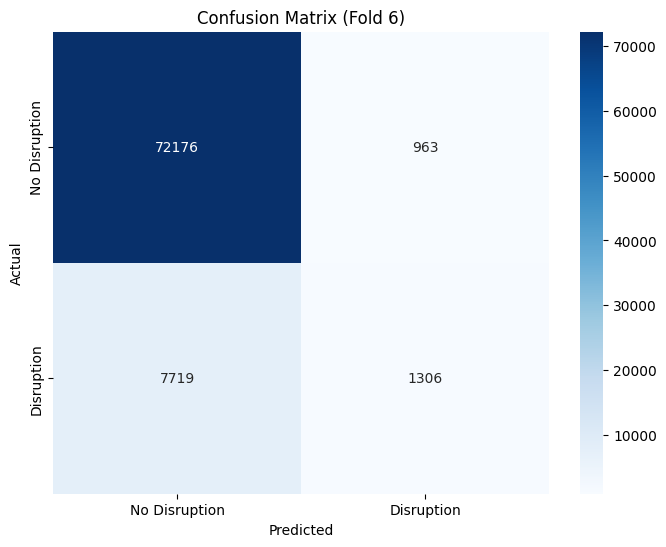


Cross-Validation Results (Mean ± Std):
Accuracy: 0.8572 ± 0.0235
Precision: 0.8572 ± 0.0235
Recall: 0.8572 ± 0.0235
F1: 0.2034 ± 0.0921
Auc: 0.7630 ± 0.0110
Balanced_acc: 0.5581 ± 0.0296

Fold 1/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
Test Loss: 0.4456
Test Accuracy: 0.8259
Test Precision: 0.8259
Test Recall: 0.8259
Test F1 Score: 0.4084
Test Balanced Accuracy: 0.6323
Test AUC: 0.8247

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.94      0.90     66970
           1       0.55      0.33      0.41     15194

    accuracy                           0.83     82164
   macro avg       0.70      0.63      0.65     82164
weighted avg       0.80      0.83      0.81     82164



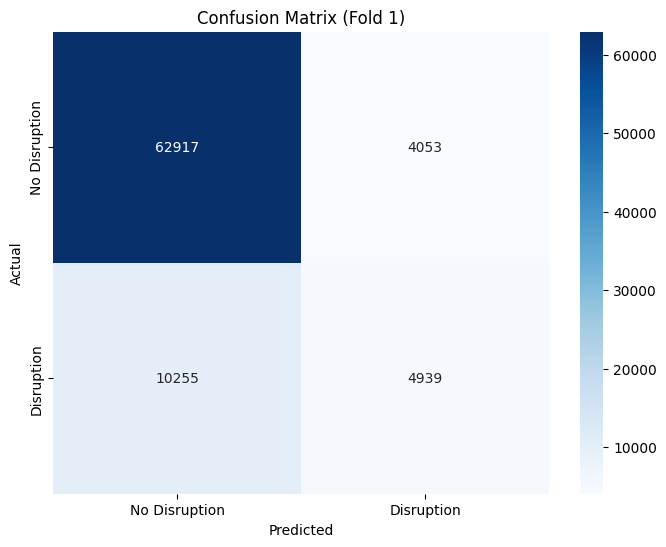


Fold 2/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
Test Loss: 0.3959
Test Accuracy: 0.8596
Test Precision: 0.8596
Test Recall: 0.8596
Test F1 Score: 0.3071
Test Balanced Accuracy: 0.5988
Test AUC: 0.7722

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92     72051
           1       0.39      0.25      0.31     10113

    accuracy                           0.86     82164
   macro avg       0.65      0.60      0.61     82164
weighted avg       0.84      0.86      0.85     82164



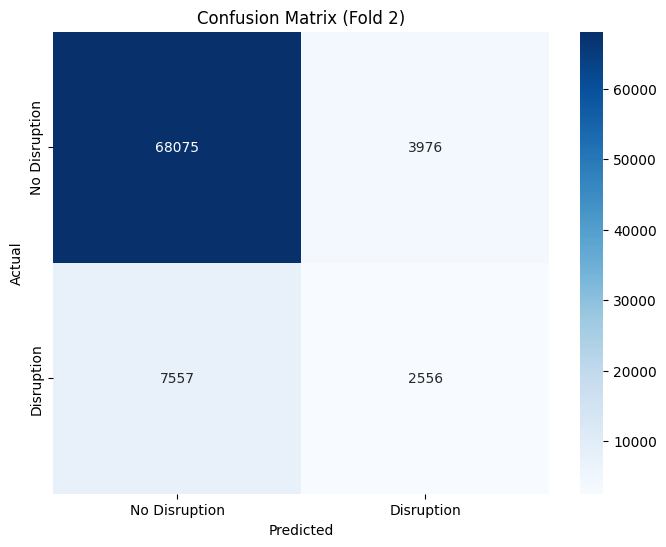


Fold 3/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
Test Loss: 0.4497
Test Accuracy: 0.8330
Test Precision: 0.8330
Test Recall: 0.8330
Test F1 Score: 0.3208
Test Balanced Accuracy: 0.5982
Test AUC: 0.7493

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90     69817
           1       0.41      0.26      0.32     12347

    accuracy                           0.83     82164
   macro avg       0.65      0.60      0.61     82164
weighted avg       0.81      0.83      0.82     82164



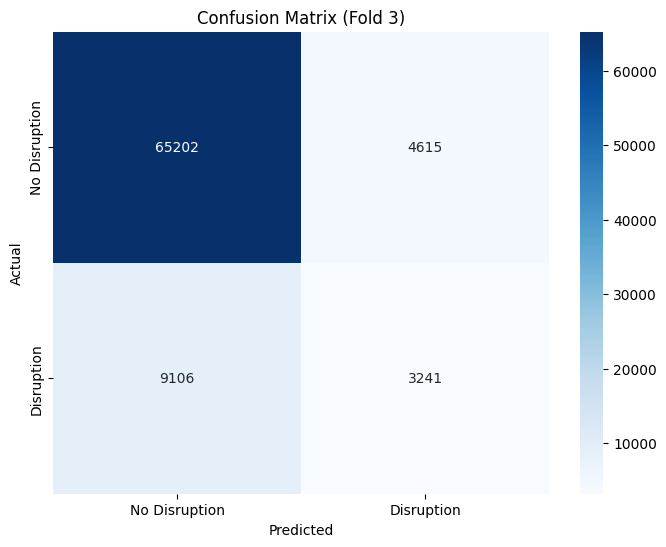


Fold 4/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
Test Loss: 0.4423
Test Accuracy: 0.8321
Test Precision: 0.8321
Test Recall: 0.8321
Test F1 Score: 0.3149
Test Balanced Accuracy: 0.5939
Test AUC: 0.7505

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.94      0.90     69378
           1       0.43      0.25      0.31     12786

    accuracy                           0.83     82164
   macro avg       0.65      0.59      0.61     82164
weighted avg       0.80      0.83      0.81     82164



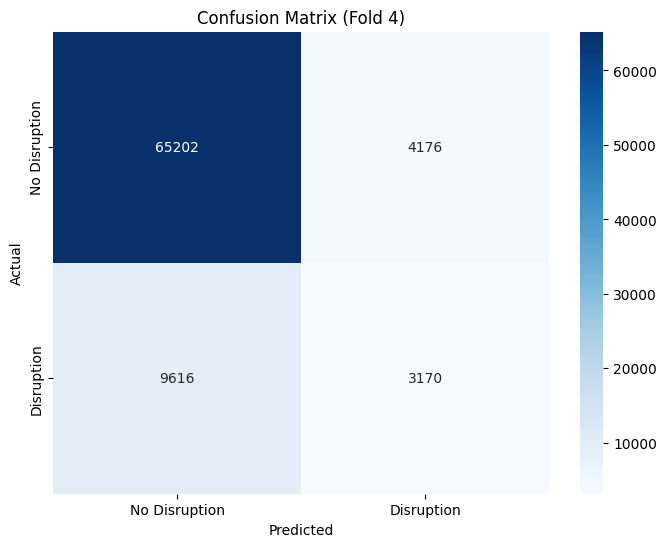


Fold 5/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
Test Loss: 0.3683
Test Accuracy: 0.8706
Test Precision: 0.8706
Test Recall: 0.8706
Test F1 Score: 0.2566
Test Balanced Accuracy: 0.5734
Test AUC: 0.7616

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93     71474
           1       0.51      0.17      0.26     10690

    accuracy                           0.87     82164
   macro avg       0.70      0.57      0.59     82164
weighted avg       0.84      0.87      0.84     82164



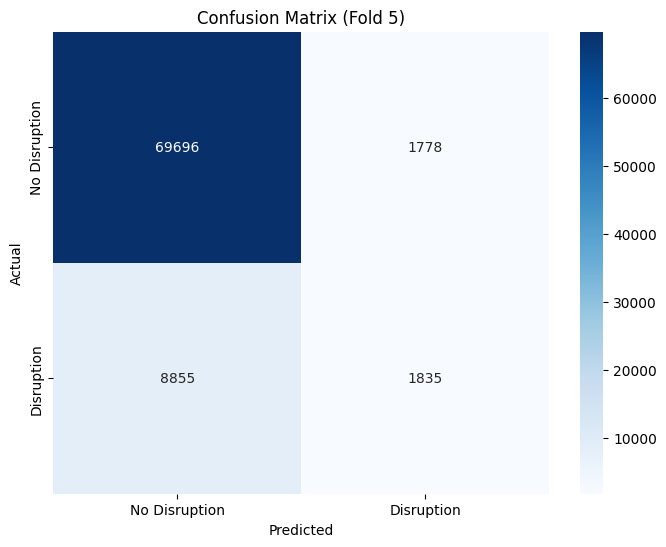


Fold 6/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
Test Loss: 0.3273
Test Accuracy: 0.8943
Test Precision: 0.8943
Test Recall: 0.8943
Test F1 Score: 0.2313
Test Balanced Accuracy: 0.5658
Test AUC: 0.7773

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94     73139
           1       0.58      0.14      0.23      9025

    accuracy                           0.89     82164
   macro avg       0.74      0.57      0.59     82164
weighted avg       0.87      0.89      0.87     82164



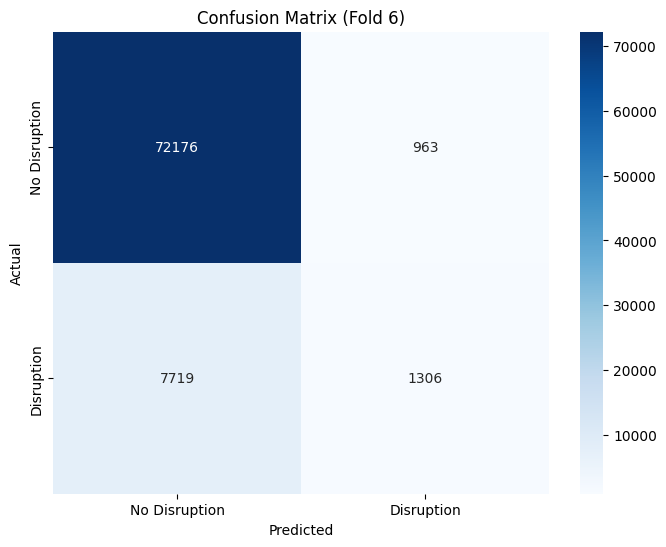


Cross-Validation Results (Mean ± Std):
Accuracy: 0.8526 ± 0.0246
Precision: 0.8526 ± 0.0246
Recall: 0.8526 ± 0.0246
F1: 0.3065 ± 0.0560
Auc: 0.7726 ± 0.0254
Balanced_acc: 0.5937 ± 0.0213


({'accuracy': [0.8258605003356934,
   0.8596343994140625,
   0.8330047130584717,
   0.8321406245231628,
   0.8705880641937256,
   0.8943333029747009],
  'precision': [0.8258605003356934,
   0.8596343994140625,
   0.8330047130584717,
   0.8321406245231628,
   0.8705880641937256,
   0.8943333029747009],
  'recall': [0.8258605003356934,
   0.8596343994140625,
   0.8330047130584717,
   0.8321406245231628,
   0.8705880641937256,
   0.8943333029747009],
  'f1': [0.4084180931117175,
   0.307119255031541,
   0.32084343909320395,
   0.3149215179813233,
   0.256589526672726,
   0.23127324242960864],
  'auc': [0.8246558349060282,
   0.7721933735306149,
   0.7493396396639558,
   0.7505113530824322,
   0.7615795494383626,
   0.7773448545722468],
  'balanced_acc': [0.632271444511519,
   0.5987804293557992,
   0.5981957669690292,
   0.5938677144593214,
   0.5733897871449549,
   0.5657712156555088]},
 {'accuracy': 0.8525936007499695,
  'precision': 0.8525936007499695,
  'recall': 0.8525936007499695,
 

In [29]:
oper_reshaped = X_oper.reshape((X_oper.shape[0], X_oper.shape[1], 1))

final_model_oper, cv_metrics, feature_importance = cross_validate_lstm(
    X=oper_reshaped, 
    y=y, 
    features=oper_features, 
    resample=False, 
    n_splits=6, 
    epochs=50, 
    batch_size=32
)
lstm_predict(oper_reshaped, y, final_model_oper, n_splits=6)


Fold 1/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2055/2055 ━━━━━━━━━━━━━━━━━━━━ 51s 23ms/step - AUC: 0.8871 - Precision: 0.8679 - Recall: 0.8679 - accuracy: 0.8679 - loss: 0.3928 - val_AUC: 0.8963 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3640
Epoch 2/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 46s 23ms/step - AUC: 0.8990 - Precision: 0.8716 - Recall: 0.8716 - accuracy: 0.8716 - loss: 0.3719 - val_AUC: 0.8974 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3688
Epoch 3/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 45s 22ms/step - AUC: 0.9056 - Precision: 0.8715 - Recall: 0.8715 - accuracy: 0.8715 - loss: 0.3650 - val_AUC: 0.9025 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3715
Epoch 4/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 46s 22ms/step - AUC: 0.9143 - Precision: 0.8735 - Recall: 0.8735 - accuracy: 0.8735 - loss: 0.3544 - val_AUC: 0.9117 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3586
Epoch 5/50
2055/2055 ━━━━━━

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

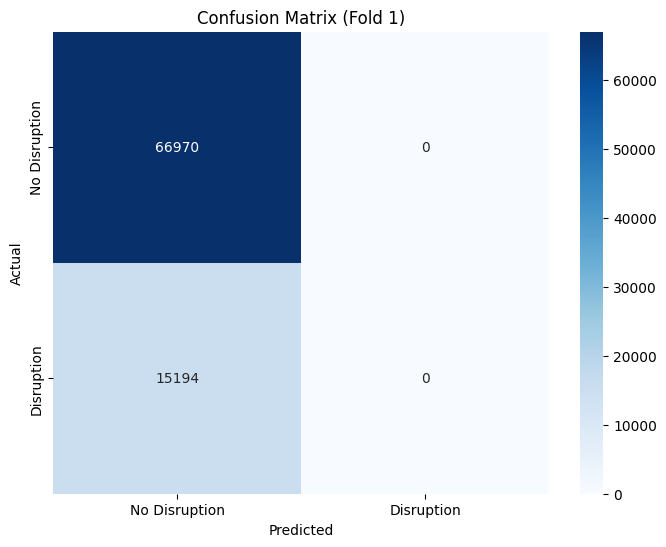


Fold 2/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4109/4109 ━━━━━━━━━━━━━━━━━━━━ 96s 23ms/step - AUC: 0.8605 - Precision: 0.8379 - Recall: 0.8379 - accuracy: 0.8379 - loss: 0.4389 - val_AUC: 0.8903 - val_Precision: 0.8655 - val_Recall: 0.8655 - val_accuracy: 0.8655 - val_loss: 0.3858
Epoch 2/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 90s 22ms/step - AUC: 0.8801 - Precision: 0.8375 - Recall: 0.8375 - accuracy: 0.8375 - loss: 0.4214 - val_AUC: 0.9160 - val_Precision: 0.8655 - val_Recall: 0.8655 - val_accuracy: 0.8655 - val_loss: 0.3603
Epoch 3/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 90s 22ms/step - AUC: 0.8927 - Precision: 0.8379 - Recall: 0.8379 - accuracy: 0.8379 - loss: 0.4075 - val_AUC: 0.9188 - val_Precision: 0.8650 - val_Recall: 0.8650 - val_accuracy: 0.8650 - val_loss: 0.3570
Epoch 4/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 91s 22ms/step - AUC: 0.8976 - Precision: 0.8385 - Recall: 0.8385 - accuracy: 0.8385 - loss: 0.4008 - val_AUC: 0.9169 - val_Precision: 0.8641 - val_Recall: 0.8641 - val_accuracy: 0.8641 - val_loss: 0.3596
Epoch 5/50
4109/4109 ━━━━━━

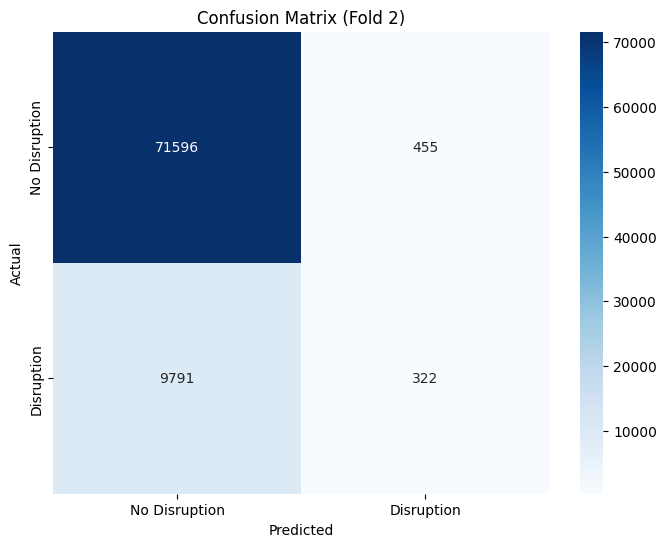


Fold 3/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6163/6163 ━━━━━━━━━━━━━━━━━━━━ 149s 24ms/step - AUC: 0.8675 - Precision: 0.8459 - Recall: 0.8459 - accuracy: 0.8459 - loss: 0.4256 - val_AUC: 0.9101 - val_Precision: 0.8908 - val_Recall: 0.8908 - val_accuracy: 0.8908 - val_loss: 0.3432
Epoch 2/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 143s 23ms/step - AUC: 0.8875 - Precision: 0.8457 - Recall: 0.8457 - accuracy: 0.8457 - loss: 0.4072 - val_AUC: 0.9327 - val_Precision: 0.8905 - val_Recall: 0.8905 - val_accuracy: 0.8905 - val_loss: 0.3174
Epoch 3/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 144s 23ms/step - AUC: 0.9038 - Precision: 0.8480 - Recall: 0.8480 - accuracy: 0.8480 - loss: 0.3870 - val_AUC: 0.9380 - val_Precision: 0.8919 - val_Recall: 0.8919 - val_accuracy: 0.8919 - val_loss: 0.3067
Epoch 4/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 146s 24ms/step - AUC: 0.9071 - Precision: 0.8484 - Recall: 0.8484 - accuracy: 0.8484 - loss: 0.3823 - val_AUC: 0.9391 - val_Precision: 0.8915 - val_Recall: 0.8915 - val_accuracy: 0.8915 - val_loss: 0.3112
Epoch 5/50
6163/6163 ━━

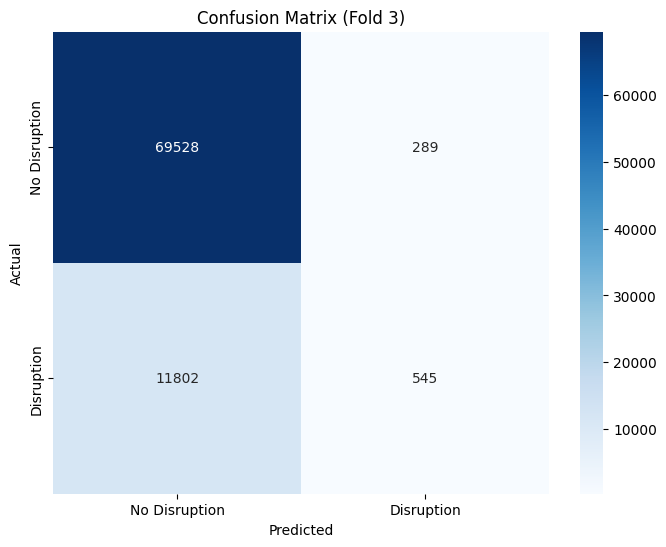


Fold 4/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8217/8217 ━━━━━━━━━━━━━━━━━━━━ 207s 25ms/step - AUC: 0.8749 - Precision: 0.8548 - Recall: 0.8548 - accuracy: 0.8548 - loss: 0.4141 - val_AUC: 0.9000 - val_Precision: 0.8466 - val_Recall: 0.8466 - val_accuracy: 0.8466 - val_loss: 0.3949
Epoch 2/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 202s 25ms/step - AUC: 0.9071 - Precision: 0.8549 - Recall: 0.8549 - accuracy: 0.8549 - loss: 0.3785 - val_AUC: 0.9085 - val_Precision: 0.8467 - val_Recall: 0.8467 - val_accuracy: 0.8467 - val_loss: 0.3812
Epoch 3/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 204s 25ms/step - AUC: 0.9139 - Precision: 0.8564 - Recall: 0.8564 - accuracy: 0.8564 - loss: 0.3676 - val_AUC: 0.9097 - val_Precision: 0.8478 - val_Recall: 0.8478 - val_accuracy: 0.8478 - val_loss: 0.3786
Epoch 4/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 205s 25ms/step - AUC: 0.9165 - Precision: 0.8575 - Recall: 0.8575 - accuracy: 0.8575 - loss: 0.3631 - val_AUC: 0.9095 - val_Precision: 0.8505 - val_Recall: 0.8505 - val_accuracy: 0.8505 - val_loss: 0.3807
Epoch 5/50
8217/8217 ━━

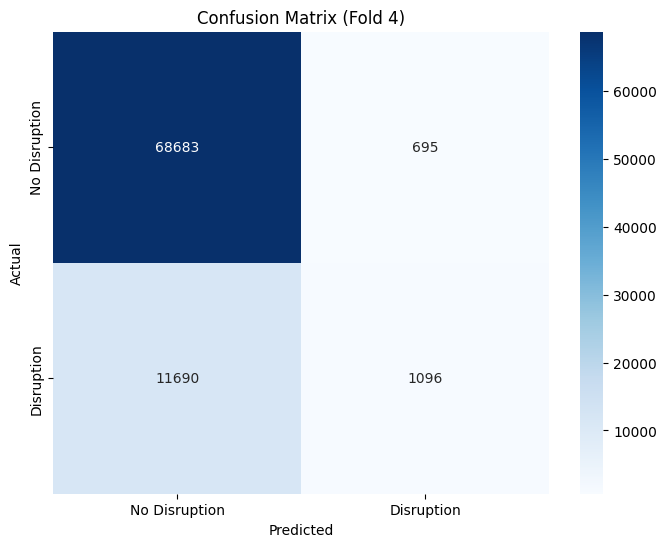


Fold 5/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10271/10271 ━━━━━━━━━━━━━━━━━━━━ 281s 27ms/step - AUC: 0.8766 - Precision: 0.8535 - Recall: 0.8535 - accuracy: 0.8535 - loss: 0.4108 - val_AUC: 0.9098 - val_Precision: 0.8444 - val_Recall: 0.8444 - val_accuracy: 0.8444 - val_loss: 0.3808
Epoch 2/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 276s 27ms/step - AUC: 0.9112 - Precision: 0.8547 - Recall: 0.8547 - accuracy: 0.8547 - loss: 0.3725 - val_AUC: 0.9120 - val_Precision: 0.8466 - val_Recall: 0.8466 - val_accuracy: 0.8466 - val_loss: 0.3752
Epoch 3/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 280s 27ms/step - AUC: 0.9152 - Precision: 0.8561 - Recall: 0.8561 - accuracy: 0.8561 - loss: 0.3660 - val_AUC: 0.9089 - val_Precision: 0.8475 - val_Recall: 0.8475 - val_accuracy: 0.8475 - val_loss: 0.3816
Epoch 4/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 282s 27ms/step - AUC: 0.9173 - Precision: 0.8578 - Recall: 0.8578 - accuracy: 0.8578 - loss: 0.3615 - val_AUC: 0.9119 - val_Precision: 0.8487 - val_Recall: 0.8487 - val_accuracy: 0.8487 - val_loss: 0.3811
Epoch 5/50
1027

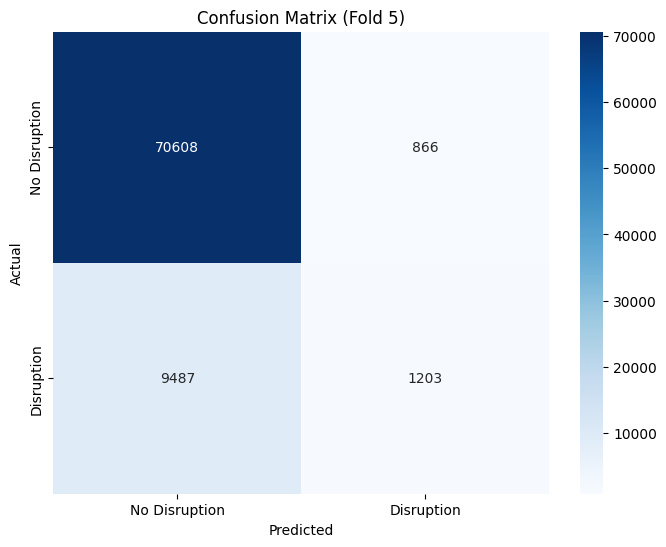


Fold 6/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12325/12325 ━━━━━━━━━━━━━━━━━━━━ 372s 30ms/step - AUC: 0.8763 - Precision: 0.8500 - Recall: 0.8500 - accuracy: 0.8500 - loss: 0.4141 - val_AUC: 0.9255 - val_Precision: 0.8718 - val_Recall: 0.8718 - val_accuracy: 0.8718 - val_loss: 0.3411
Epoch 2/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 43345s 4s/step - AUC: 0.9104 - Precision: 0.8538 - Recall: 0.8538 - accuracy: 0.8538 - loss: 0.3744 - val_AUC: 0.9304 - val_Precision: 0.8737 - val_Recall: 0.8737 - val_accuracy: 0.8737 - val_loss: 0.3306
Epoch 3/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 373s 30ms/step - AUC: 0.9138 - Precision: 0.8545 - Recall: 0.8545 - accuracy: 0.8545 - loss: 0.3687 - val_AUC: 0.9327 - val_Precision: 0.8735 - val_Recall: 0.8735 - val_accuracy: 0.8735 - val_loss: 0.3275
Epoch 4/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 380s 31ms/step - AUC: 0.9157 - Precision: 0.8547 - Recall: 0.8547 - accuracy: 0.8547 - loss: 0.3656 - val_AUC: 0.9341 - val_Precision: 0.8746 - val_Recall: 0.8746 - val_accuracy: 0.8746 - val_loss: 0.3251
Epoch 5/50
1232

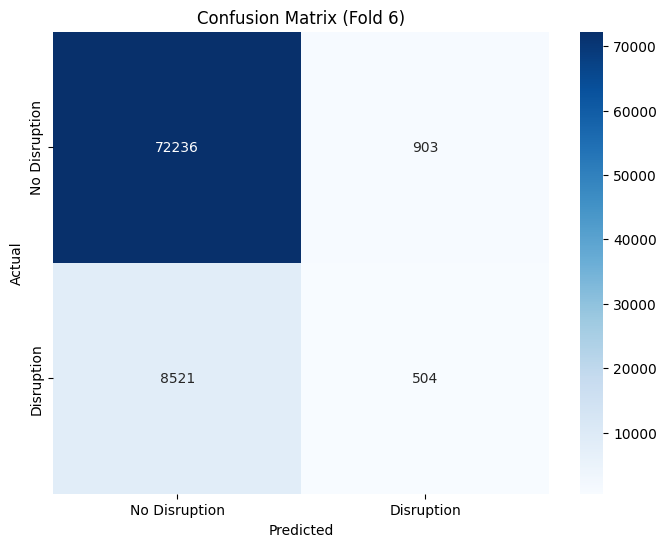


Cross-Validation Results (Mean ± Std):
Accuracy: 0.8586 ± 0.0233
Precision: 0.8586 ± 0.0233
Recall: 0.8586 ± 0.0233
F1: 0.0962 ± 0.0609
Auc: 0.7190 ± 0.0627
Balanced_acc: 0.5238 ± 0.0163

Fold 1/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step
Test Loss: 0.4039
Test Accuracy: 0.8246
Test Precision: 0.8246
Test Recall: 0.8246
Test F1 Score: 0.1362
Test Balanced Accuracy: 0.5348
Test AUC: 0.7778

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.99      0.90     66970
           1       0.76      0.07      0.14     15194

    accuracy                           0.82     82164
   macro avg       0.80      0.53      0.52     82164
weighted avg       0.81      0.82      0.76     82164



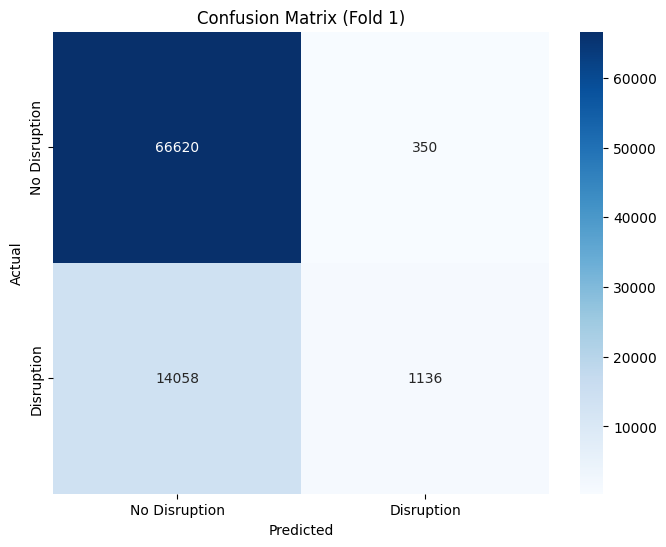


Fold 2/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step
Test Loss: 0.2957
Test Accuracy: 0.8890
Test Precision: 0.8890
Test Recall: 0.8890
Test F1 Score: 0.2396
Test Balanced Accuracy: 0.5679
Test AUC: 0.8117

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     72051
           1       0.77      0.14      0.24     10113

    accuracy                           0.89     82164
   macro avg       0.83      0.57      0.59     82164
weighted avg       0.88      0.89      0.85     82164



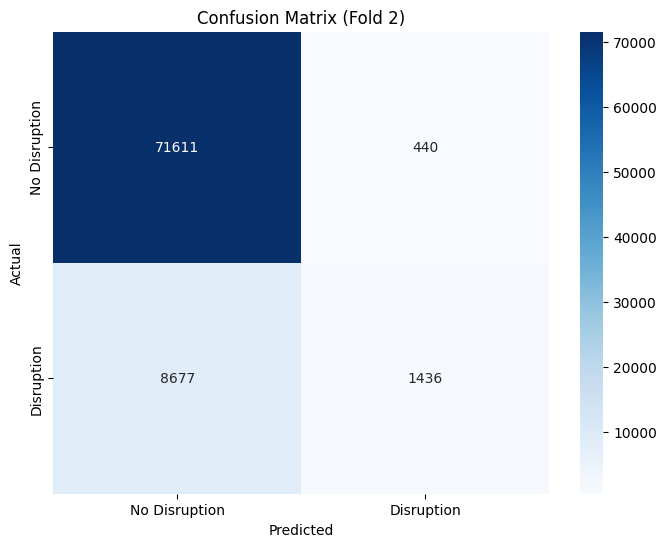


Fold 3/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step
Test Loss: 0.3491
Test Accuracy: 0.8587
Test Precision: 0.8587
Test Recall: 0.8587
Test F1 Score: 0.1576
Test Balanced Accuracy: 0.5415
Test AUC: 0.7875

Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92     69817
           1       0.76      0.09      0.16     12347

    accuracy                           0.86     82164
   macro avg       0.81      0.54      0.54     82164
weighted avg       0.85      0.86      0.81     82164



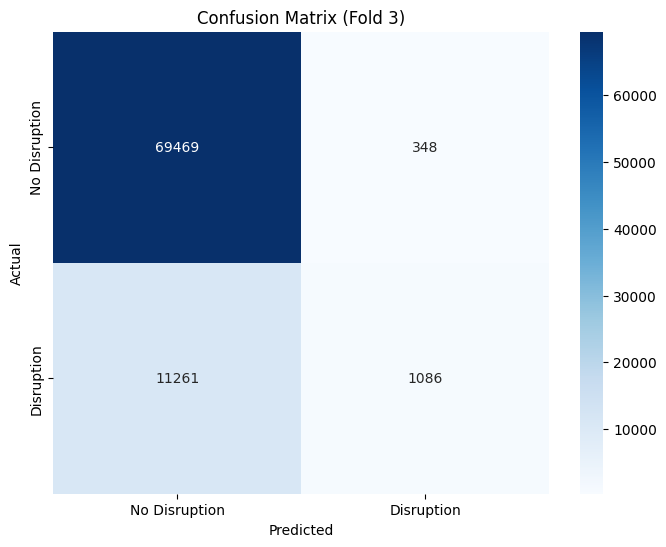


Fold 4/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step
Test Loss: 0.3636
Test Accuracy: 0.8531
Test Precision: 0.8531
Test Recall: 0.8531
Test F1 Score: 0.1728
Test Balanced Accuracy: 0.5454
Test AUC: 0.7745

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92     69378
           1       0.70      0.10      0.17     12786

    accuracy                           0.85     82164
   macro avg       0.78      0.55      0.55     82164
weighted avg       0.83      0.85      0.80     82164



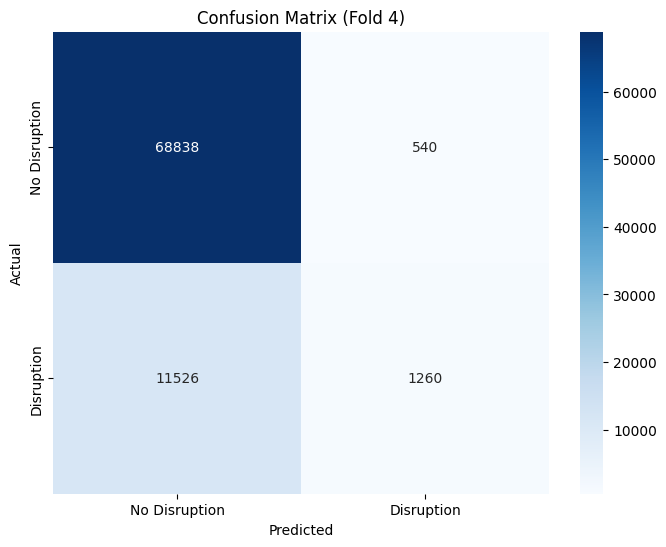


Fold 5/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step
Test Loss: 0.3261
Test Accuracy: 0.8762
Test Precision: 0.8762
Test Recall: 0.8762
Test F1 Score: 0.1811
Test Balanced Accuracy: 0.5484
Test AUC: 0.7793

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93     71474
           1       0.65      0.11      0.18     10690

    accuracy                           0.88     82164
   macro avg       0.77      0.55      0.56     82164
weighted avg       0.85      0.88      0.84     82164



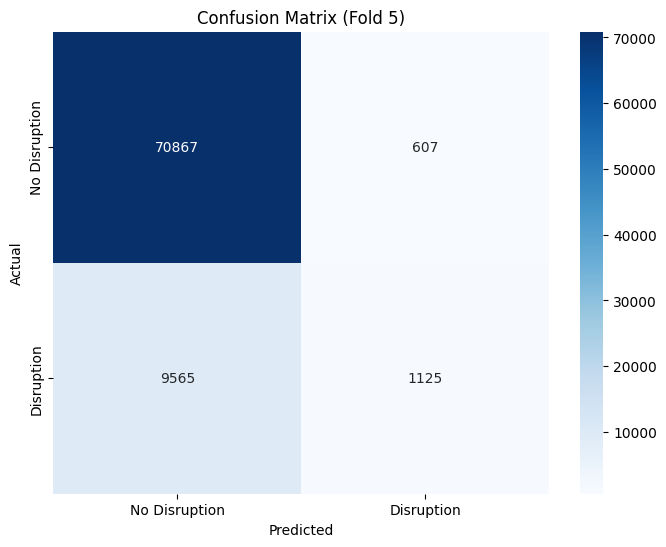


Fold 6/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 36s 14ms/step
Test Loss: 0.3143
Test Accuracy: 0.8853
Test Precision: 0.8853
Test Recall: 0.8853
Test F1 Score: 0.0966
Test Balanced Accuracy: 0.5217
Test AUC: 0.7507

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     73139
           1       0.36      0.06      0.10      9025

    accuracy                           0.89     82164
   macro avg       0.63      0.52      0.52     82164
weighted avg       0.84      0.89      0.85     82164



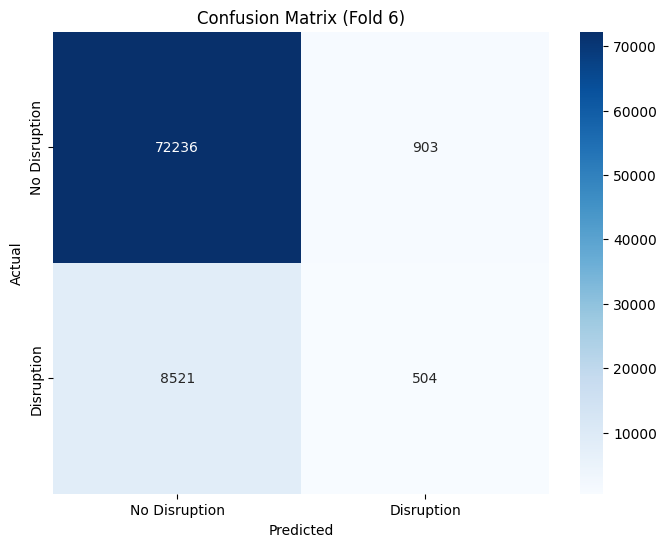


Cross-Validation Results (Mean ± Std):
Accuracy: 0.8645 ± 0.0221
Precision: 0.8645 ± 0.0221
Recall: 0.8645 ± 0.0221
F1: 0.1640 ± 0.0436
Auc: 0.7803 ± 0.0180
Balanced_acc: 0.5433 ± 0.0140


({'accuracy': [0.8246433734893799,
   0.8890389800071716,
   0.8587093949317932,
   0.8531473875045776,
   0.8761988282203674,
   0.8853025436401367],
  'precision': [0.8246433734893799,
   0.8890389800071716,
   0.8587093949317932,
   0.8531473875045776,
   0.8761988282203674,
   0.8853025436401367],
  'recall': [0.8246433734893799,
   0.8890389800071716,
   0.8587093949317932,
   0.8531473875045776,
   0.8761988282203674,
   0.8853025436401367],
  'f1': [0.13621103117505995,
   0.23955292351322044,
   0.15760830128437703,
   0.17276840806252572,
   0.18113025277733055,
   0.09662576687116564],
  'auc': [0.7778442766863973,
   0.8117106298691548,
   0.7874589742328826,
   0.7744589696814685,
   0.7793090080209454,
   0.7507334317583501],
  'balanced_acc': [0.5347700672221765,
   0.5679443329638935,
   0.541486064636328,
   0.5453809183509936,
   0.5483729709925068,
   0.521749260571994]},
 {'accuracy': 0.8645067512989044,
  'precision': 0.8645067512989044,
  'recall': 0.86450675129890

In [30]:
tnw_reshaped = X_tnw.reshape((X_tnw.shape[0], X_tnw.shape[1], 1))

final_model_tnw, cv_metrics, feature_importance = cross_validate_lstm(
    X=tnw_reshaped, 
    y=y, 
    features=wthr_features + topo_features, 
    resample=False, 
    n_splits=6, 
    epochs=50, 
    batch_size=32
)
lstm_predict(tnw_reshaped, y, final_model_tnw, n_splits=6)


Fold 1/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2055/2055 ━━━━━━━━━━━━━━━━━━━━ 58s 27ms/step - AUC: 0.8876 - Precision: 0.8698 - Recall: 0.8698 - accuracy: 0.8698 - loss: 0.3918 - val_AUC: 0.9029 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3620
Epoch 2/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 54s 26ms/step - AUC: 0.9033 - Precision: 0.8721 - Recall: 0.8721 - accuracy: 0.8721 - loss: 0.3659 - val_AUC: 0.9059 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3627
Epoch 3/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 52s 26ms/step - AUC: 0.9089 - Precision: 0.8719 - Recall: 0.8719 - accuracy: 0.8719 - loss: 0.3610 - val_AUC: 0.9157 - val_Precision: 0.8767 - val_Recall: 0.8767 - val_accuracy: 0.8767 - val_loss: 0.3507
Epoch 4/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 53s 26ms/step - AUC: 0.9198 - Precision: 0.8717 - Recall: 0.8717 - accuracy: 0.8717 - loss: 0.3486 - val_AUC: 0.9378 - val_Precision: 0.8775 - val_Recall: 0.8775 - val_accuracy: 0.8775 - val_loss: 0.3202
Epoch 5/50
2055/2055 ━━━━━━

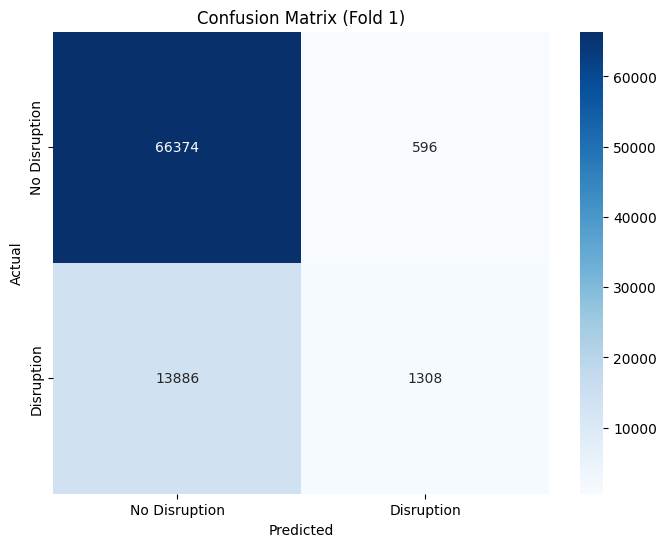


Fold 2/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4109/4109 ━━━━━━━━━━━━━━━━━━━━ 109s 26ms/step - AUC: 0.8645 - Precision: 0.8393 - Recall: 0.8393 - accuracy: 0.8393 - loss: 0.4361 - val_AUC: 0.9204 - val_Precision: 0.8354 - val_Recall: 0.8354 - val_accuracy: 0.8354 - val_loss: 0.3744
Epoch 2/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 106s 26ms/step - AUC: 0.9147 - Precision: 0.8415 - Recall: 0.8415 - accuracy: 0.8415 - loss: 0.3713 - val_AUC: 0.9259 - val_Precision: 0.8486 - val_Recall: 0.8486 - val_accuracy: 0.8486 - val_loss: 0.3506
Epoch 3/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 106s 26ms/step - AUC: 0.9237 - Precision: 0.8491 - Recall: 0.8491 - accuracy: 0.8491 - loss: 0.3519 - val_AUC: 0.9169 - val_Precision: 0.8237 - val_Recall: 0.8237 - val_accuracy: 0.8237 - val_loss: 0.3672
Epoch 4/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 108s 26ms/step - AUC: 0.9281 - Precision: 0.8566 - Recall: 0.8566 - accuracy: 0.8566 - loss: 0.3414 - val_AUC: 0.9234 - val_Precision: 0.8375 - val_Recall: 0.8375 - val_accuracy: 0.8375 - val_loss: 0.3541
Epoch 5/50
4109/4109 ━━

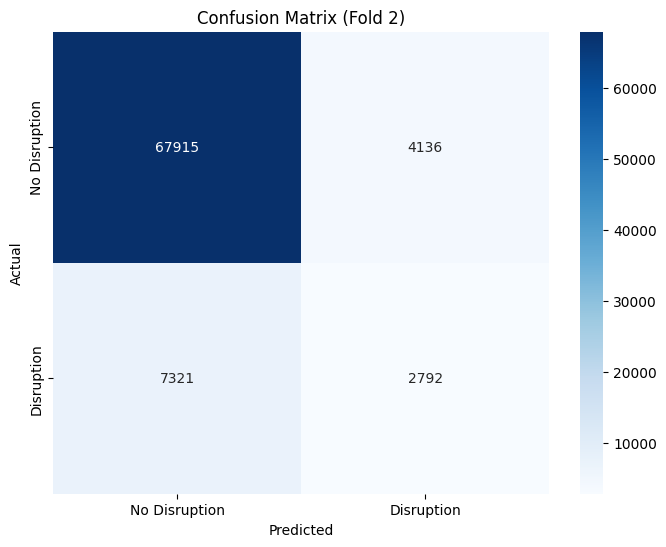


Fold 3/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6163/6163 ━━━━━━━━━━━━━━━━━━━━ 169s 27ms/step - AUC: 0.8751 - Precision: 0.8459 - Recall: 0.8459 - accuracy: 0.8459 - loss: 0.4183 - val_AUC: 0.9470 - val_Precision: 0.8929 - val_Recall: 0.8929 - val_accuracy: 0.8929 - val_loss: 0.2950
Epoch 2/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 164s 27ms/step - AUC: 0.9198 - Precision: 0.8487 - Recall: 0.8487 - accuracy: 0.8487 - loss: 0.3606 - val_AUC: 0.9434 - val_Precision: 0.8812 - val_Recall: 0.8812 - val_accuracy: 0.8812 - val_loss: 0.3128
Epoch 3/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 164s 27ms/step - AUC: 0.9268 - Precision: 0.8540 - Recall: 0.8540 - accuracy: 0.8540 - loss: 0.3448 - val_AUC: 0.9488 - val_Precision: 0.8934 - val_Recall: 0.8934 - val_accuracy: 0.8934 - val_loss: 0.2980
Epoch 4/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 166s 27ms/step - AUC: 0.9289 - Precision: 0.8555 - Recall: 0.8555 - accuracy: 0.8555 - loss: 0.3401 - val_AUC: 0.9427 - val_Precision: 0.8690 - val_Recall: 0.8690 - val_accuracy: 0.8690 - val_loss: 0.3089
Epoch 5/50
6163/6163 ━━

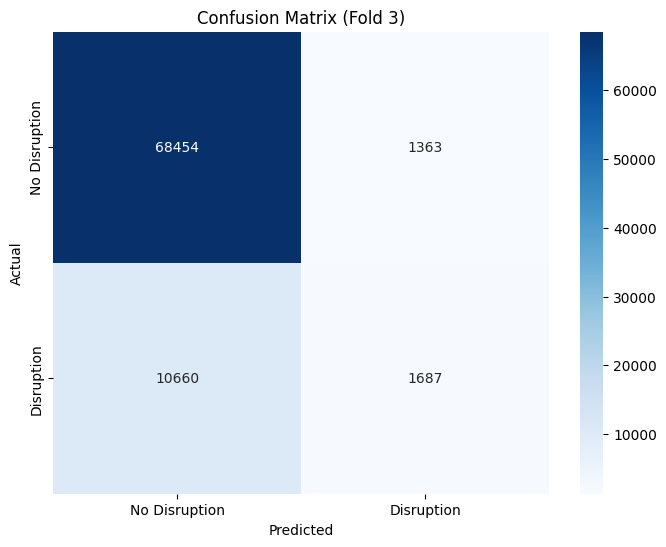


Fold 4/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8217/8217 ━━━━━━━━━━━━━━━━━━━━ 227s 27ms/step - AUC: 0.8851 - Precision: 0.8557 - Recall: 0.8557 - accuracy: 0.8557 - loss: 0.4015 - val_AUC: 0.9207 - val_Precision: 0.8526 - val_Recall: 0.8526 - val_accuracy: 0.8526 - val_loss: 0.3615
Epoch 2/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 220s 27ms/step - AUC: 0.9256 - Precision: 0.8592 - Recall: 0.8592 - accuracy: 0.8592 - loss: 0.3463 - val_AUC: 0.9214 - val_Precision: 0.8542 - val_Recall: 0.8542 - val_accuracy: 0.8542 - val_loss: 0.3589
Epoch 3/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 219s 27ms/step - AUC: 0.9298 - Precision: 0.8595 - Recall: 0.8595 - accuracy: 0.8595 - loss: 0.3375 - val_AUC: 0.9212 - val_Precision: 0.8516 - val_Recall: 0.8516 - val_accuracy: 0.8516 - val_loss: 0.3581
Epoch 4/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 220s 27ms/step - AUC: 0.9326 - Precision: 0.8627 - Recall: 0.8627 - accuracy: 0.8627 - loss: 0.3310 - val_AUC: 0.9246 - val_Precision: 0.8528 - val_Recall: 0.8528 - val_accuracy: 0.8528 - val_loss: 0.3506
Epoch 5/50
8217/8217 ━━

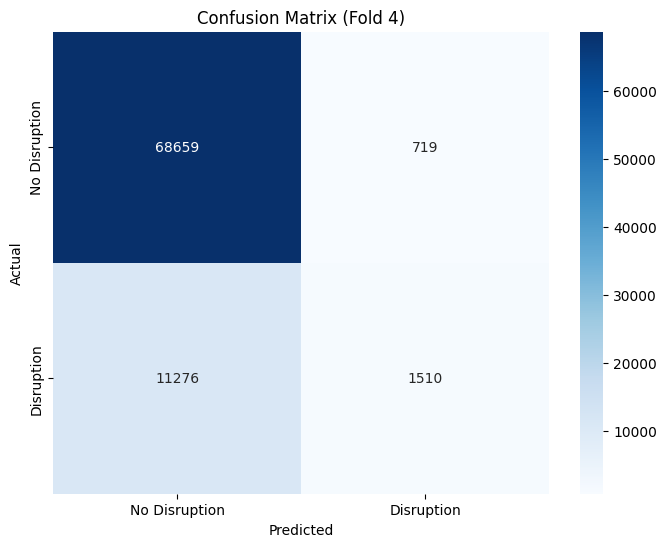


Fold 5/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10271/10271 ━━━━━━━━━━━━━━━━━━━━ 312s 30ms/step - AUC: 0.8993 - Precision: 0.8546 - Recall: 0.8546 - accuracy: 0.8546 - loss: 0.3864 - val_AUC: 0.9193 - val_Precision: 0.8530 - val_Recall: 0.8530 - val_accuracy: 0.8530 - val_loss: 0.3607
Epoch 2/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 302s 29ms/step - AUC: 0.9259 - Precision: 0.8577 - Recall: 0.8577 - accuracy: 0.8577 - loss: 0.3462 - val_AUC: 0.9204 - val_Precision: 0.8513 - val_Recall: 0.8513 - val_accuracy: 0.8513 - val_loss: 0.3593
Epoch 3/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 300s 29ms/step - AUC: 0.9298 - Precision: 0.8583 - Recall: 0.8583 - accuracy: 0.8583 - loss: 0.3378 - val_AUC: 0.9218 - val_Precision: 0.8527 - val_Recall: 0.8527 - val_accuracy: 0.8527 - val_loss: 0.3566
Epoch 4/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 301s 29ms/step - AUC: 0.9313 - Precision: 0.8601 - Recall: 0.8601 - accuracy: 0.8601 - loss: 0.3343 - val_AUC: 0.9216 - val_Precision: 0.8496 - val_Recall: 0.8496 - val_accuracy: 0.8496 - val_loss: 0.3576
Epoch 5/50
1027

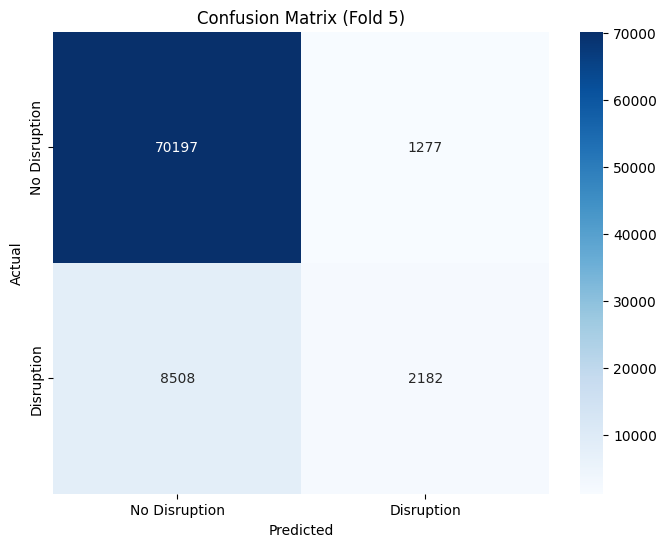


Fold 6/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12325/12325 ━━━━━━━━━━━━━━━━━━━━ 382s 31ms/step - AUC: 0.9044 - Precision: 0.8522 - Recall: 0.8522 - accuracy: 0.8522 - loss: 0.3813 - val_AUC: 0.9388 - val_Precision: 0.8820 - val_Recall: 0.8820 - val_accuracy: 0.8820 - val_loss: 0.3166
Epoch 2/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 378s 31ms/step - AUC: 0.9264 - Precision: 0.8556 - Recall: 0.8556 - accuracy: 0.8556 - loss: 0.3456 - val_AUC: 0.9398 - val_Precision: 0.8761 - val_Recall: 0.8761 - val_accuracy: 0.8761 - val_loss: 0.3153
Epoch 3/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 377s 31ms/step - AUC: 0.9307 - Precision: 0.8592 - Recall: 0.8592 - accuracy: 0.8592 - loss: 0.3356 - val_AUC: 0.9418 - val_Precision: 0.8839 - val_Recall: 0.8839 - val_accuracy: 0.8839 - val_loss: 0.3051
Epoch 4/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 381s 31ms/step - AUC: 0.9316 - Precision: 0.8607 - Recall: 0.8607 - accuracy: 0.8607 - loss: 0.3333 - val_AUC: 0.9421 - val_Precision: 0.8807 - val_Recall: 0.8807 - val_accuracy: 0.8807 - val_loss: 0.3090
Epoch 5/50
1232

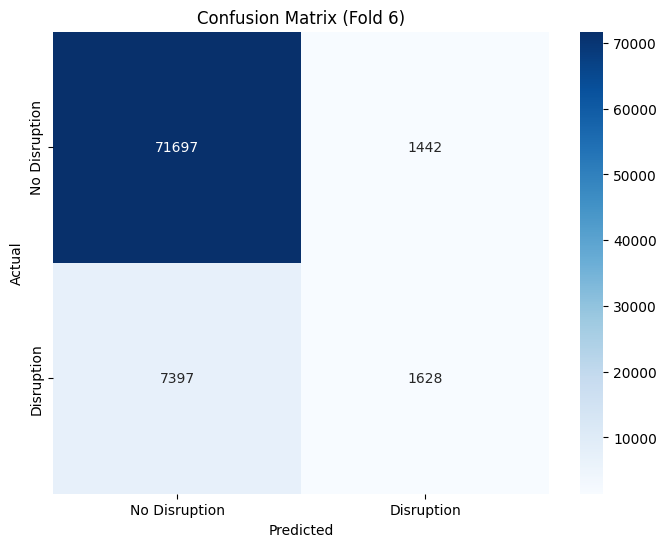


Cross-Validation Results (Mean ± Std):
Accuracy: 0.8609 ± 0.0219
Precision: 0.8609 ± 0.0219
Recall: 0.8609 ± 0.0219
F1: 0.2464 ± 0.0612
Auc: 0.7901 ± 0.0200
Balanced_acc: 0.5723 ± 0.0243

Fold 1/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step
Test Loss: 0.4079
Test Accuracy: 0.8199
Test Precision: 0.8199
Test Recall: 0.8199
Test F1 Score: 0.1757
Test Balanced Accuracy: 0.5431
Test AUC: 0.7770

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.98      0.90     66970
           1       0.57      0.10      0.18     15194

    accuracy                           0.82     82164
   macro avg       0.70      0.54      0.54     82164
weighted avg       0.78      0.82      0.77     82164



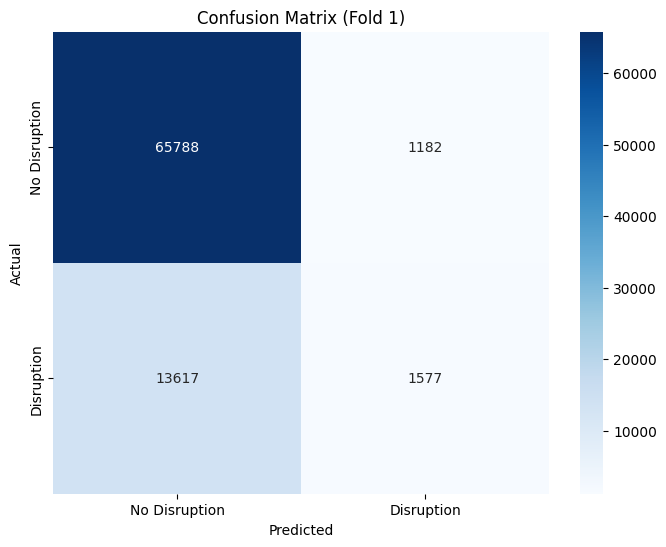


Fold 2/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step
Test Loss: 0.3098
Test Accuracy: 0.8828
Test Precision: 0.8828
Test Recall: 0.8828
Test F1 Score: 0.2178
Test Balanced Accuracy: 0.5603
Test AUC: 0.8093

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     72051
           1       0.61      0.13      0.22     10113

    accuracy                           0.88     82164
   macro avg       0.75      0.56      0.58     82164
weighted avg       0.86      0.88      0.85     82164



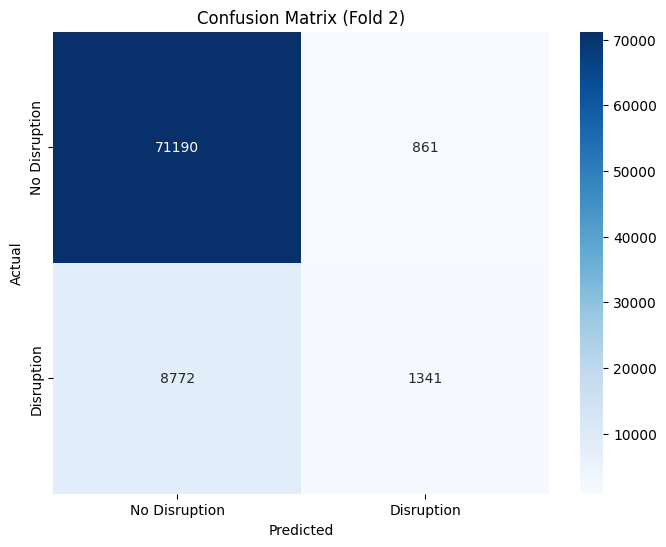


Fold 3/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step
Test Loss: 0.3368
Test Accuracy: 0.8613
Test Precision: 0.8613
Test Recall: 0.8613
Test F1 Score: 0.2517
Test Balanced Accuracy: 0.5707
Test AUC: 0.8093

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.99      0.92     69817
           1       0.66      0.16      0.25     12347

    accuracy                           0.86     82164
   macro avg       0.77      0.57      0.59     82164
weighted avg       0.84      0.86      0.82     82164



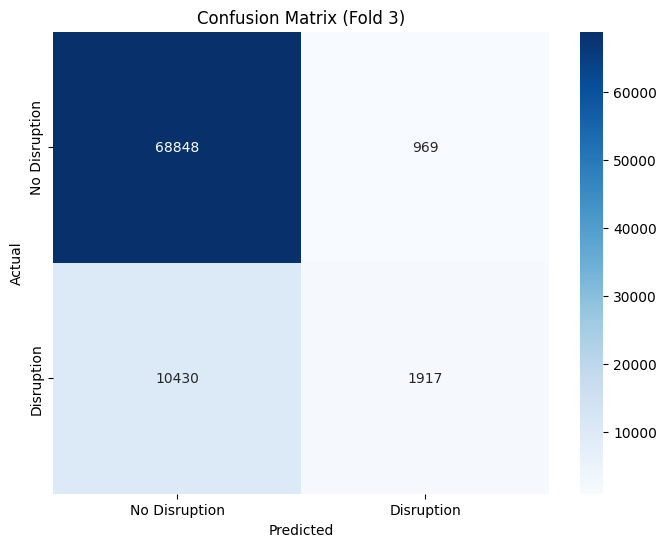


Fold 4/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step
Test Loss: 0.3432
Test Accuracy: 0.8574
Test Precision: 0.8574
Test Recall: 0.8574
Test F1 Score: 0.2788
Test Balanced Accuracy: 0.5800
Test AUC: 0.8093

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92     69378
           1       0.65      0.18      0.28     12786

    accuracy                           0.86     82164
   macro avg       0.76      0.58      0.60     82164
weighted avg       0.83      0.86      0.82     82164



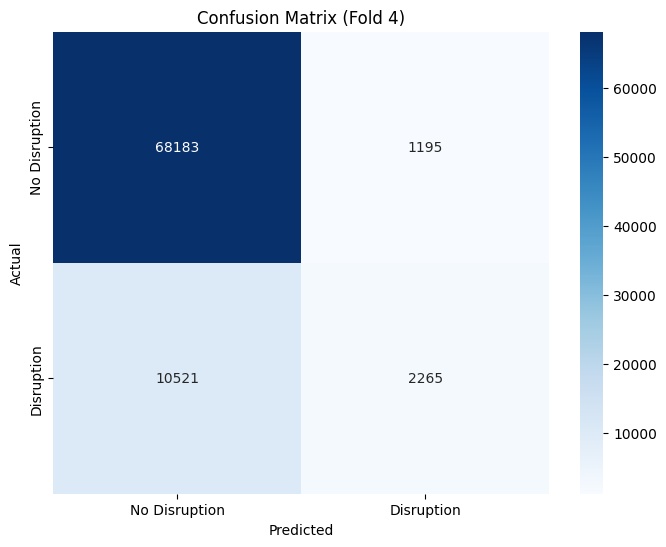


Fold 5/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step
Test Loss: 0.3055
Test Accuracy: 0.8828
Test Precision: 0.8828
Test Recall: 0.8828
Test F1 Score: 0.3007
Test Balanced Accuracy: 0.5898
Test AUC: 0.8137

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     71474
           1       0.67      0.19      0.30     10690

    accuracy                           0.88     82164
   macro avg       0.78      0.59      0.62     82164
weighted avg       0.86      0.88      0.85     82164



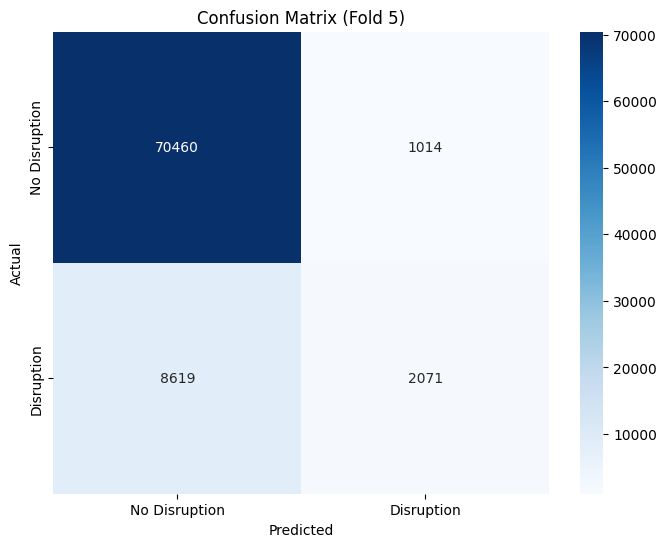


Fold 6/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step
Test Loss: 0.2879
Test Accuracy: 0.8924
Test Precision: 0.8924
Test Recall: 0.8924
Test F1 Score: 0.2692
Test Balanced Accuracy: 0.5803
Test AUC: 0.8045

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94     73139
           1       0.53      0.18      0.27      9025

    accuracy                           0.89     82164
   macro avg       0.72      0.58      0.61     82164
weighted avg       0.87      0.89      0.87     82164



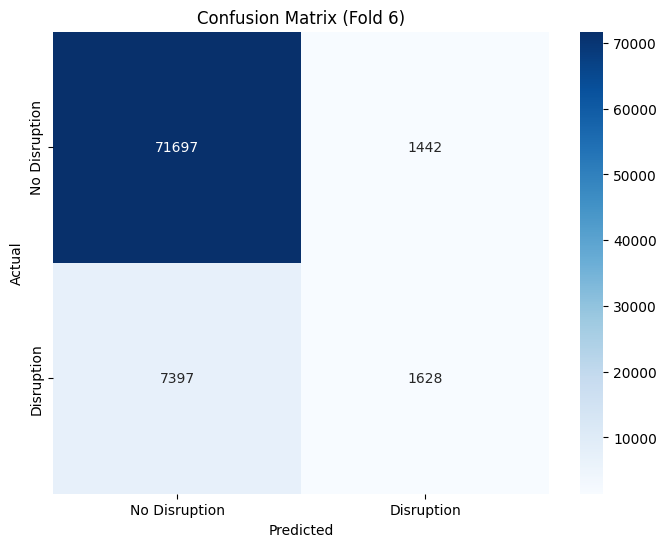


Cross-Validation Results (Mean ± Std):
Accuracy: 0.8661 ± 0.0241
Precision: 0.8661 ± 0.0241
Recall: 0.8661 ± 0.0241
F1: 0.2490 ± 0.0415
Auc: 0.8039 ± 0.0123
Balanced_acc: 0.5707 ± 0.0153


({'accuracy': [0.8198845982551575,
   0.8827588558197021,
   0.8612653017044067,
   0.8574071526527405,
   0.8827588558197021,
   0.8924224972724915],
  'precision': [0.8198845982551575,
   0.8827588558197021,
   0.8612653017044067,
   0.8574071526527405,
   0.8827588558197021,
   0.8924224972724915],
  'recall': [0.8198845982551575,
   0.8827588558197021,
   0.8612653017044067,
   0.8574071526527405,
   0.8827588558197021,
   0.8924224972724915],
  'f1': [0.17568094468890993,
   0.21778319123020706,
   0.2516904089805029,
   0.27883786778283887,
   0.3006896551724138,
   0.2692021496486151],
  'auc': [0.7769867259949853,
   0.809337138047932,
   0.8093326892834216,
   0.8093450056092035,
   0.8136962611143204,
   0.804508743435781],
  'balanced_acc': [0.5430706381134982,
   0.5603258665278217,
   0.5706906229775984,
   0.5799611995082563,
   0.5897727415803212,
   0.5803359640897787]},
 {'accuracy': 0.8660828769207001,
  'precision': 0.8660828769207001,
  'recall': 0.8660828769207001,

In [32]:
tno_reshaped = X_tno.reshape((X_tno.shape[0], X_tno.shape[1], 1))

final_model_tno, cv_metrics, feature_importance = cross_validate_lstm(
    X=tno_reshaped, 
    y=y, 
    features= topo_features + oper_features, 
    resample=False, 
    n_splits=6, 
    epochs=50, 
    batch_size=32
)
lstm_predict(tno_reshaped, y, final_model_tno, n_splits=6)


Fold 1/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2055/2055 ━━━━━━━━━━━━━━━━━━━━ 46s 21ms/step - AUC: 0.8866 - Precision: 0.8705 - Recall: 0.8705 - accuracy: 0.8705 - loss: 0.3872 - val_AUC: 0.9322 - val_Precision: 0.8742 - val_Recall: 0.8742 - val_accuracy: 0.8742 - val_loss: 0.3665
Epoch 2/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - AUC: 0.9287 - Precision: 0.8721 - Recall: 0.8721 - accuracy: 0.8721 - loss: 0.3355 - val_AUC: 0.9288 - val_Precision: 0.8695 - val_Recall: 0.8695 - val_accuracy: 0.8695 - val_loss: 0.3744
Epoch 3/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - AUC: 0.9344 - Precision: 0.8742 - Recall: 0.8742 - accuracy: 0.8742 - loss: 0.3236 - val_AUC: 0.9220 - val_Precision: 0.8507 - val_Recall: 0.8507 - val_accuracy: 0.8507 - val_loss: 0.3775
Epoch 4/50
2055/2055 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - AUC: 0.9340 - Precision: 0.8743 - Recall: 0.8743 - accuracy: 0.8743 - loss: 0.3245 - val_AUC: 0.9254 - val_Precision: 0.8579 - val_Recall: 0.8579 - val_accuracy: 0.8579 - val_loss: 0.3690
Epoch 5/50
2055/2055 ━━━━━━

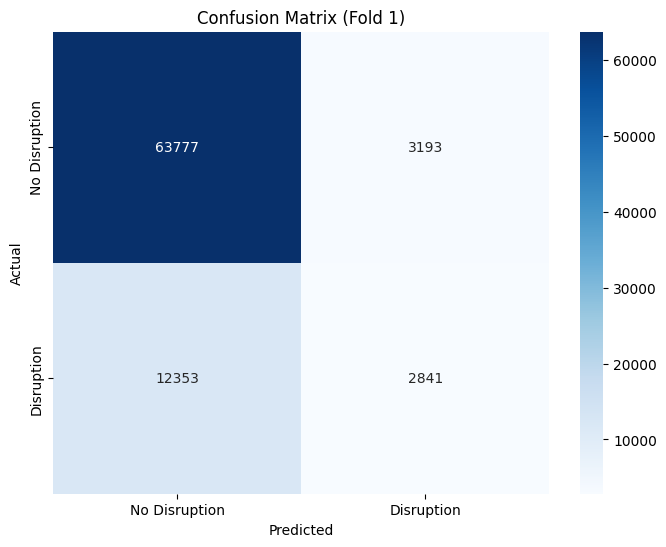


Fold 2/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4109/4109 ━━━━━━━━━━━━━━━━━━━━ 85s 20ms/step - AUC: 0.8861 - Precision: 0.8413 - Recall: 0.8413 - accuracy: 0.8413 - loss: 0.4098 - val_AUC: 0.9101 - val_Precision: 0.8324 - val_Recall: 0.8324 - val_accuracy: 0.8324 - val_loss: 0.3849
Epoch 2/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 81s 20ms/step - AUC: 0.9209 - Precision: 0.8501 - Recall: 0.8501 - accuracy: 0.8501 - loss: 0.3578 - val_AUC: 0.9142 - val_Precision: 0.8362 - val_Recall: 0.8362 - val_accuracy: 0.8362 - val_loss: 0.3731
Epoch 3/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 82s 20ms/step - AUC: 0.9236 - Precision: 0.8555 - Recall: 0.8555 - accuracy: 0.8555 - loss: 0.3513 - val_AUC: 0.9020 - val_Precision: 0.8234 - val_Recall: 0.8234 - val_accuracy: 0.8234 - val_loss: 0.3965
Epoch 4/50
4109/4109 ━━━━━━━━━━━━━━━━━━━━ 81s 20ms/step - AUC: 0.9254 - Precision: 0.8595 - Recall: 0.8595 - accuracy: 0.8595 - loss: 0.3466 - val_AUC: 0.8993 - val_Precision: 0.8178 - val_Recall: 0.8178 - val_accuracy: 0.8178 - val_loss: 0.4018
Epoch 5/50
4109/4109 ━━━━━━

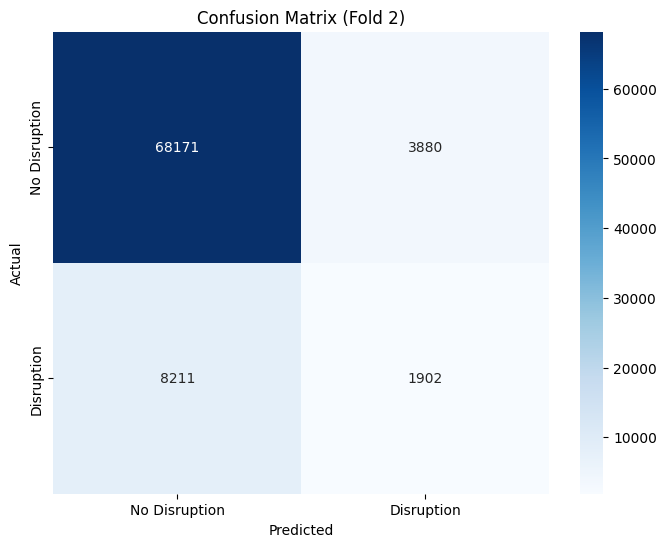


Fold 3/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6163/6163 ━━━━━━━━━━━━━━━━━━━━ 125s 20ms/step - AUC: 0.8925 - Precision: 0.8461 - Recall: 0.8461 - accuracy: 0.8461 - loss: 0.4007 - val_AUC: 0.9123 - val_Precision: 0.8162 - val_Recall: 0.8162 - val_accuracy: 0.8162 - val_loss: 0.3740
Epoch 2/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 116s 19ms/step - AUC: 0.9228 - Precision: 0.8546 - Recall: 0.8546 - accuracy: 0.8546 - loss: 0.3530 - val_AUC: 0.9377 - val_Precision: 0.8721 - val_Recall: 0.8721 - val_accuracy: 0.8721 - val_loss: 0.3272
Epoch 3/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 121s 20ms/step - AUC: 0.9255 - Precision: 0.8587 - Recall: 0.8587 - accuracy: 0.8587 - loss: 0.3466 - val_AUC: 0.9375 - val_Precision: 0.8721 - val_Recall: 0.8721 - val_accuracy: 0.8721 - val_loss: 0.3266
Epoch 4/50
6163/6163 ━━━━━━━━━━━━━━━━━━━━ 122s 20ms/step - AUC: 0.9282 - Precision: 0.8629 - Recall: 0.8629 - accuracy: 0.8629 - loss: 0.3398 - val_AUC: 0.9302 - val_Precision: 0.8580 - val_Recall: 0.8580 - val_accuracy: 0.8580 - val_loss: 0.3387
Epoch 5/50
6163/6163 ━━

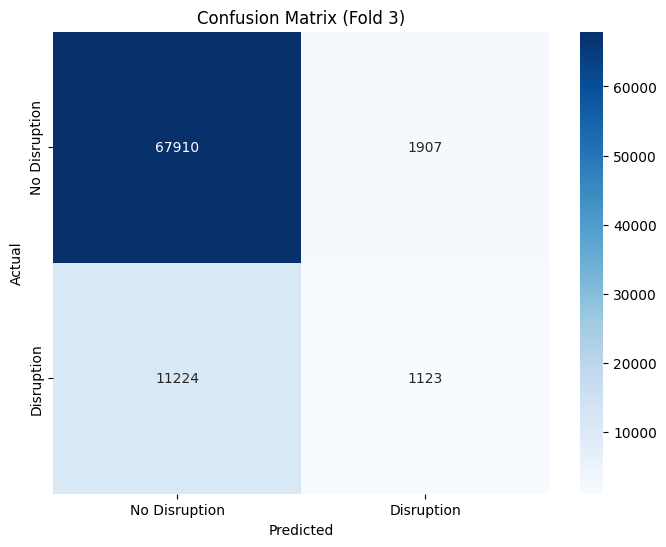


Fold 4/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8217/8217 ━━━━━━━━━━━━━━━━━━━━ 170s 20ms/step - AUC: 0.9007 - Precision: 0.8540 - Recall: 0.8540 - accuracy: 0.8540 - loss: 0.3850 - val_AUC: 0.9092 - val_Precision: 0.8400 - val_Recall: 0.8400 - val_accuracy: 0.8400 - val_loss: 0.3830
Epoch 2/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 165s 20ms/step - AUC: 0.9265 - Precision: 0.8615 - Recall: 0.8615 - accuracy: 0.8615 - loss: 0.3439 - val_AUC: 0.9095 - val_Precision: 0.8351 - val_Recall: 0.8351 - val_accuracy: 0.8351 - val_loss: 0.3823
Epoch 3/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 165s 20ms/step - AUC: 0.9287 - Precision: 0.8652 - Recall: 0.8652 - accuracy: 0.8652 - loss: 0.3384 - val_AUC: 0.9119 - val_Precision: 0.8446 - val_Recall: 0.8446 - val_accuracy: 0.8446 - val_loss: 0.3766
Epoch 4/50
8217/8217 ━━━━━━━━━━━━━━━━━━━━ 167s 20ms/step - AUC: 0.9299 - Precision: 0.8666 - Recall: 0.8666 - accuracy: 0.8666 - loss: 0.3354 - val_AUC: 0.9051 - val_Precision: 0.8310 - val_Recall: 0.8310 - val_accuracy: 0.8310 - val_loss: 0.3908
Epoch 5/50
8217/8217 ━━

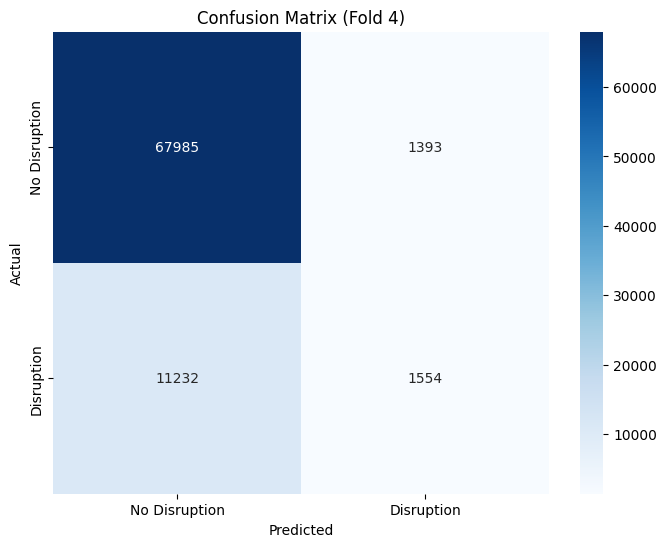


Fold 5/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10271/10271 ━━━━━━━━━━━━━━━━━━━━ 222s 21ms/step - AUC: 0.9041 - Precision: 0.8542 - Recall: 0.8542 - accuracy: 0.8542 - loss: 0.3816 - val_AUC: 0.9048 - val_Precision: 0.8403 - val_Recall: 0.8403 - val_accuracy: 0.8403 - val_loss: 0.3909
Epoch 2/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 207s 20ms/step - AUC: 0.9230 - Precision: 0.8562 - Recall: 0.8562 - accuracy: 0.8562 - loss: 0.3522 - val_AUC: 0.9110 - val_Precision: 0.8452 - val_Recall: 0.8452 - val_accuracy: 0.8452 - val_loss: 0.3813
Epoch 3/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 204s 20ms/step - AUC: 0.9254 - Precision: 0.8609 - Recall: 0.8609 - accuracy: 0.8609 - loss: 0.3460 - val_AUC: 0.9072 - val_Precision: 0.8405 - val_Recall: 0.8405 - val_accuracy: 0.8405 - val_loss: 0.3891
Epoch 4/50
10271/10271 ━━━━━━━━━━━━━━━━━━━━ 208s 20ms/step - AUC: 0.9263 - Precision: 0.8617 - Recall: 0.8617 - accuracy: 0.8617 - loss: 0.3441 - val_AUC: 0.9094 - val_Precision: 0.8418 - val_Recall: 0.8418 - val_accuracy: 0.8418 - val_loss: 0.3827
Epoch 5/50
1027

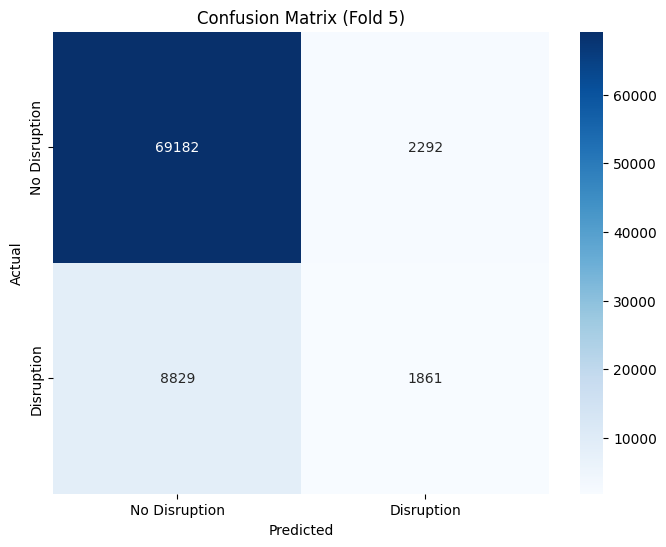


Fold 6/6
Epoch 1/50


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12325/12325 ━━━━━━━━━━━━━━━━━━━━ 258s 21ms/step - AUC: 0.8998 - Precision: 0.8501 - Recall: 0.8501 - accuracy: 0.8501 - loss: 0.3896 - val_AUC: 0.9238 - val_Precision: 0.8586 - val_Recall: 0.8586 - val_accuracy: 0.8586 - val_loss: 0.3579
Epoch 2/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 264s 21ms/step - AUC: 0.9191 - Precision: 0.8523 - Recall: 0.8523 - accuracy: 0.8523 - loss: 0.3606 - val_AUC: 0.9271 - val_Precision: 0.8679 - val_Recall: 0.8679 - val_accuracy: 0.8679 - val_loss: 0.3441
Epoch 3/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 269s 22ms/step - AUC: 0.9212 - Precision: 0.8562 - Recall: 0.8562 - accuracy: 0.8562 - loss: 0.3557 - val_AUC: 0.9247 - val_Precision: 0.8674 - val_Recall: 0.8674 - val_accuracy: 0.8674 - val_loss: 0.3538
Epoch 4/50
12325/12325 ━━━━━━━━━━━━━━━━━━━━ 268s 22ms/step - AUC: 0.9232 - Precision: 0.8587 - Recall: 0.8587 - accuracy: 0.8587 - loss: 0.3507 - val_AUC: 0.9253 - val_Precision: 0.8677 - val_Recall: 0.8677 - val_accuracy: 0.8677 - val_loss: 0.3467
Epoch 5/50
1232

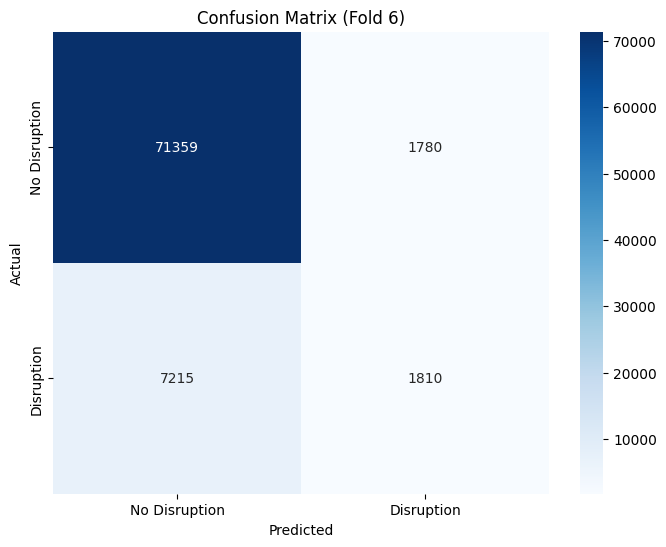


Cross-Validation Results (Mean ± Std):
Accuracy: 0.8509 ± 0.0242
Precision: 0.8509 ± 0.0242
Recall: 0.8509 ± 0.0242
F1: 0.2314 ± 0.0470
Auc: 0.7408 ± 0.0189
Balanced_acc: 0.5631 ± 0.0177

Fold 1/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step
Test Loss: 0.4196
Test Accuracy: 0.8309
Test Precision: 0.8309
Test Recall: 0.8309
Test F1 Score: 0.5644
Test Balanced Accuracy: 0.7388
Test AUC: 0.8391

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.90     66970
           1       0.54      0.59      0.56     15194

    accuracy                           0.83     82164
   macro avg       0.72      0.74      0.73     82164
weighted avg       0.84      0.83      0.83     82164



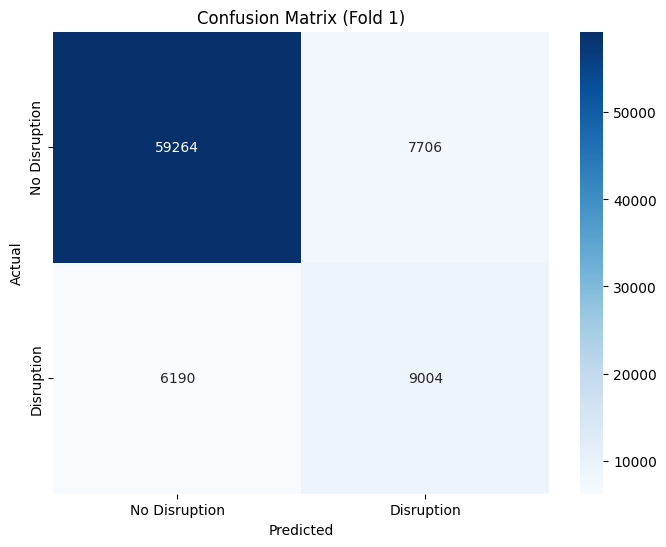


Fold 2/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step
Test Loss: 0.4848
Test Accuracy: 0.8135
Test Precision: 0.8135
Test Recall: 0.8135
Test F1 Score: 0.3599
Test Balanced Accuracy: 0.6470
Test AUC: 0.7760

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.87      0.89     72051
           1       0.31      0.43      0.36     10113

    accuracy                           0.81     82164
   macro avg       0.61      0.65      0.63     82164
weighted avg       0.84      0.81      0.83     82164



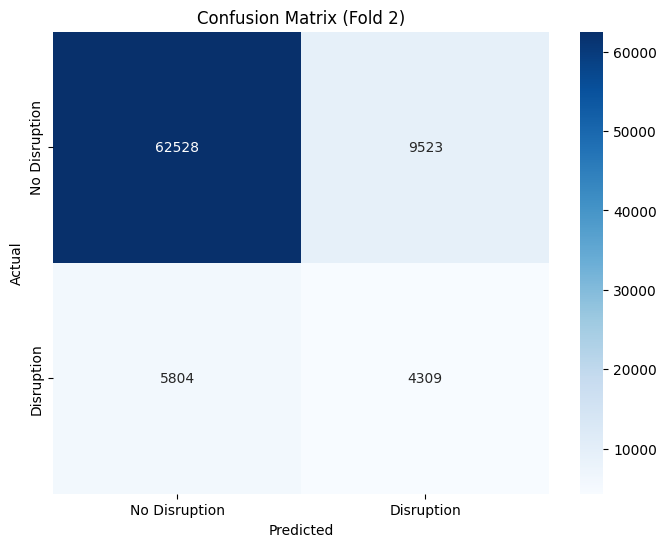


Fold 3/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step
Test Loss: 0.4761
Test Accuracy: 0.7981
Test Precision: 0.7981
Test Recall: 0.7981
Test F1 Score: 0.3319
Test Balanced Accuracy: 0.6069
Test AUC: 0.7482

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88     69817
           1       0.33      0.33      0.33     12347

    accuracy                           0.80     82164
   macro avg       0.61      0.61      0.61     82164
weighted avg       0.80      0.80      0.80     82164



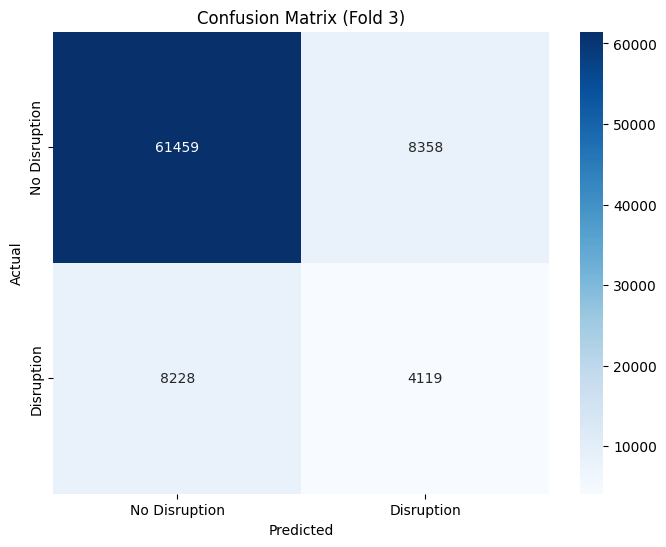


Fold 4/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step
Test Loss: 0.4272
Test Accuracy: 0.8195
Test Precision: 0.8195
Test Recall: 0.8195
Test F1 Score: 0.3581
Test Balanced Accuracy: 0.6172
Test AUC: 0.7574

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.89     69378
           1       0.40      0.32      0.36     12786

    accuracy                           0.82     82164
   macro avg       0.64      0.62      0.63     82164
weighted avg       0.81      0.82      0.81     82164



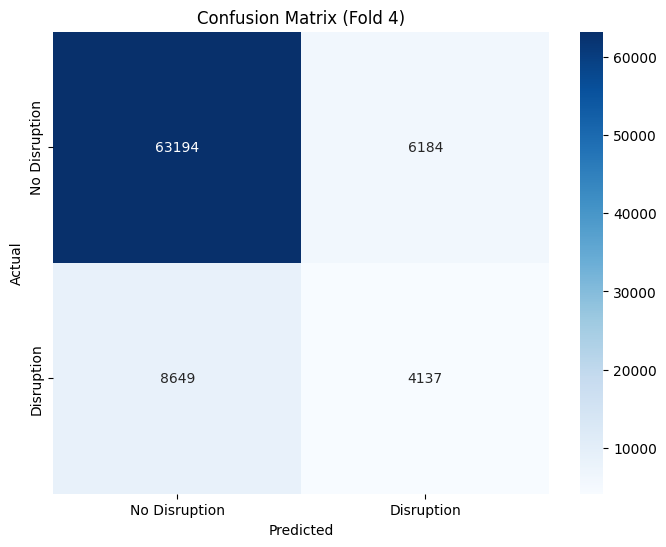


Fold 5/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step
Test Loss: 0.3543
Test Accuracy: 0.8651
Test Precision: 0.8651
Test Recall: 0.8651
Test F1 Score: 0.2752
Test Balanced Accuracy: 0.5810
Test AUC: 0.7587

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93     71474
           1       0.46      0.20      0.28     10690

    accuracy                           0.87     82164
   macro avg       0.67      0.58      0.60     82164
weighted avg       0.83      0.87      0.84     82164



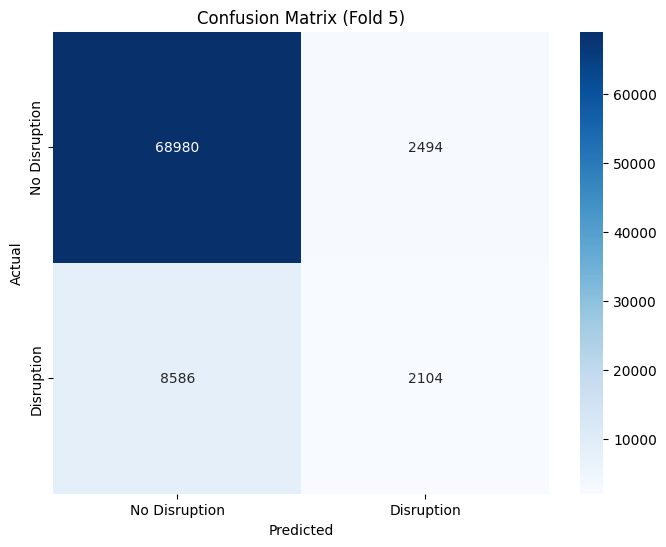


Fold 6/6
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step
2568/2568 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step
Test Loss: 0.3212
Test Accuracy: 0.8905
Test Precision: 0.8905
Test Recall: 0.8905
Test F1 Score: 0.2870
Test Balanced Accuracy: 0.5881
Test AUC: 0.7734

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94     73139
           1       0.50      0.20      0.29      9025

    accuracy                           0.89     82164
   macro avg       0.71      0.59      0.61     82164
weighted avg       0.86      0.89      0.87     82164



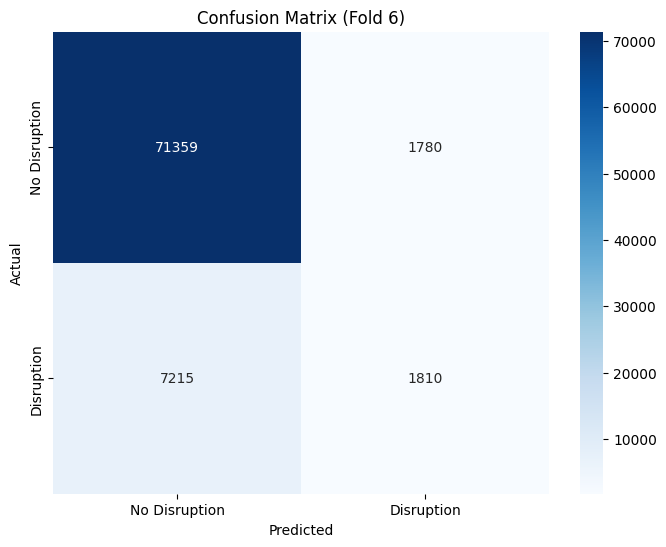


Cross-Validation Results (Mean ± Std):
Accuracy: 0.8363 ± 0.0318
Precision: 0.8363 ± 0.0318
Recall: 0.8363 ± 0.0318
F1: 0.3627 ± 0.0958
Auc: 0.7755 ± 0.0300
Balanced_acc: 0.6298 ± 0.0532


({'accuracy': [0.8308748602867126,
   0.8134584426879883,
   0.7981354594230652,
   0.8194708228111267,
   0.8651477694511414,
   0.8905238509178162],
  'precision': [0.8308748602867126,
   0.8134584426879883,
   0.7981354594230652,
   0.8194708228111267,
   0.8651477694511414,
   0.8905238509178162],
  'recall': [0.8308748602867126,
   0.8134584426879883,
   0.7981354594230652,
   0.8194708228111267,
   0.8651477694511414,
   0.8905238509178162],
  'f1': [0.5644433299899699,
   0.35990812278137396,
   0.3318562681276184,
   0.3580733111178431,
   0.27524856096284667,
   0.2869599682917162],
  'auc': [0.8390664896073399,
   0.7760085993231858,
   0.7481947335369163,
   0.7573890463764101,
   0.7587371262559893,
   0.7734415889844174],
  'balanced_acc': [0.7387679476835054,
   0.6469574842708505,
   0.6069451702775541,
   0.6172110656142151,
   0.5809628249492257,
   0.5881083978561824]},
 {'accuracy': 0.8362685342629751,
  'precision': 0.8362685342629751,
  'recall': 0.8362685342629751

In [31]:
wno_reshaped = X_wno.reshape((X_wno.shape[0], X_wno.shape[1], 1))

final_model_wno, cv_metrics, feature_importance = cross_validate_lstm(
    X=wno_reshaped, 
    y=y, 
    features=wthr_features + oper_features, 
    resample=False, 
    n_splits=6, 
    epochs=50, 
    batch_size=32
)
lstm_predict(wno_reshaped, y, final_model_wno, n_splits=6)